# Анализ структуры и активности клиентов (жертвователей) благотворительного фонда "Синдром Любви"

## Введение

**Краткое описание проекта**

В рамках данного проекта проводится анализ структуры и активности клиентов (жертвователей) благотворительного фонда, на основании предоставленных выгрузок данных.


**Цель проекта**

Основной целью проекта является выявление ключевых тенденций среди клиентов (жертвователей) благотворительного фонда, выделение основных сегментов и формирование рекомендаций для улучшения маркетинговых стратегий фонда.


**Описание данных**

Для проведения анализа были использованы выгрузки из системы управления бизнесом.

В выгрузках присутствует большое количество столбцов с данными (около 200 столбцов в каждой) среди которых был выделен следующий перечень ключевых столбцов, используемый в рамках проекта:
- `id` - идентификатор записи в базе данных;
- `user_id (контакт:_id)` - идентификатор клиента (жертвователя);
- `company_id (компания:_id)` - идентификатор компании-жертвователя;
- `user_gender (контакт:_пол)` - пол клиента (жертвователя);
- `country (контакт:_страна_)` - страна клиента (жертвователя);
- `region (контакт:_регион_)` - регион клиента (жертвователя);
- `city (контакт:_город_)` - город клиента (жертвователя);
- `payment_date (дата_начала_(минимальное))` - минимальное значение даты, зафиксированное в базе данных;
- `payment_id (id_в_платежном_шлюзе)` - идентификатор платежа;
- `received_sum (полученная сумма)` - сумма платежа, полученная от клиента (жертвователя), в рублях;
- `comment (комментарий)` - комментарий к платежу;
- `transaction_type (тип_сделки)` - информация о типе пожертвования;
- `event_code (код_(список))` - код мероприятия (акции), в рамках которого направлено пожертвование;
- `event_name (action_(строка))` - наименование мероприятия / ссылка на мероприятие, в рамках которого направлено пожертвование.

**План работы**

Для достижения поставленной цели предполагается осуществить следующий ряд действий:

***1. Осуществить загрузку и провести первоначальный анализ исходных данных, в т.ч.:***
- импортировать необходимые библиотеки и методы и загрузить данные;
- ознакомиться с исходными данными посредством вывода основной информации об их структуре, типах и т.д.;
- выявить наличие проблем в исходных данных для последующей корректировки, в т.ч. дубликатов, пропусков, неверно присвоенных типов данных и т.д.;

***2. Провести предобработку данных, в т.ч.:***
- осуществить поиск, проверку и удаление дубликатов и пропущенных значений;
- осуществить поиск, проверку и заполнение пропущенных значений, при необходимости;
- осуществить проверку и скорректировать типы данных в столбцах, при необходимости.

***3. Провести исследовательский анализ данных, в т.ч.:***
- провести анализ выбросов, при их наличии;
- провести анализ динамики основных показателей по годам;
- провести анализ притока новых клиентов (жертвователей) по месяцам.
- сформировать социально-демографический и географический портрет клиентов (жертвователей).

***5. Провести анализ состояния текущей базы клиентов (жертвователей) за последний актуальный период (RFM-анализ)***

***6. Сформировать выводы и рекомендации по улучшению маркетинговых стратегий фонда, в т.ч.:***
- сформировать выводы по проведенному исследованию;
- рекомендации по улучшению маркетинговых стратегий фонда.

## Загрузка и первоначальный анализ исходных данных

### Импорт библиотек и методов, загрузка данных

В первую очередь импортируем необходимые для работы библиотеки и методы, а также устанавливим формат отображения данных.

Импортируем библиотеки.

In [1]:
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt
import os
import warnings
from matplotlib.dates import DayLocator, MonthLocator, DateFormatter
from datetime import datetime

Импортируем метод `display`, используемый для вывода нескольких таблиц или иных данных в одной ячейке. Расширим зону отображения вывода данных для просмотра всех столбцов, добавим возможность полного отображения строк в столбцах, установим формат отображения чисел с запятой до двух знаков, а также скроем предупреждения, появляющиеся при построении графиков.

In [2]:
from IPython.display import display, HTML
display(HTML('<style>.container { width:90% !important; }</style>'))
pd.set_option('display.max_columns', None)
pd.set_option('display.max_colwidth', None)
pd.set_option('display.float_format', '{:.2f}'.format)
warnings.filterwarnings('ignore')

В связи с тем, что было предоставлено большое количество выгрузок с данными (с 2015 по 2024 гг. с разбивкой по полугодиям), в каждой из которых присутствует более 200 столбцов, в первую очередь рассмотрим наиболее актуальные данные за первое полугодие 2024 г. и определим перечень столбцов, которые будут использованы для проведения исследования. Это позволит провести первичный анализ данных и впоследствии объединить выгрузки без лишних столбцов, что ускорит загрузку и работу с объединенным файлом.

Для начала проверим доступность файлов по указанным путям при помощи библиотеки `os`.

In [3]:
# Создаем два варианта пути к файлу
path_2024_first_half_one = 'https://docs.google.com/spreadsheets/d/1NYGOAbsLeOyobsnp3RNUFSGzlvROBSpt/edit?usp=drive_link&ouid=111381528642105931542&rtpof=true&sd=true'
path_2024_first_half_two = './BFSindromLubviMasterskaya/2024/01.01.24-30.06.24.xls'

# Проверяем доступность файла по указанным путям
if os.path.exists(path_2024_first_half_one):
    data_2024_first_half_one = pd.read_html(path_2024_first_half_one)
    print('Первый путь к файлу доступен')

elif os.path.exists(path_2024_first_half_two):
    data_2024_first_half_two = pd.read_html(path_2024_first_half_two)
    print('Второй путь к файлу доступен')

else:
    print('Возникла ошибка. Необходима проверка кода')

Второй путь к файлу доступен


Файл доступен по второму пути. Его и возьмем в работу.

Теперь загрузим данные за первое полугодие 2024 г. Для этого воспользуемся методом `read_html()` для открытия файла и просмотра первых 5 строк.

In [4]:
# Сохраняем данные за первую половину 2024 года в переменную
data_2024_first_half = pd.read_html(path_2024_first_half_two, skiprows=0, header=0)[0]

# Выводим первые 5 строк датасета на экран
data_2024_first_half.head()

,ID,Название (Количество уникальных),Стадия сделки (Количество уникальных),Ответственный (Количество уникальных),Дата начала (Минимальное),Комментарий,Направление сделки,Стадия сделки,В стадии: В работе,В стадии: Удачно,В стадии: Не удачно,Сделка закрыта,Тип сделки,Сумма в валюте сделки,Валюта сделки,Ожидаемая сумма,Полученная сумма,Утраченная сумма,Тип события,Дата события,Описание события,Ответственный: ID,Ответственный,Ответственный: Имя,Дата создания,Создал: ID,Создал,Создал: Имя,Дата изменения,Создана CRM-формой,Повторная сделка,UTM Source,UTM Medium,UTM Campaign,UTM Content,UTM Term,Лид: ID,Лид: Название,Лид: Дополнительно о стадии,Лид: Сумма,Лид: Комментарий,Лид: Имя,Лид: Дата рождения,Лид: Должность,Лид: Источник,Лид: Дата создания,Ответственный: ID.1,Ответственный.1,Ответственный: Имя.1,Контакт: ID,Контакт: Источник,Контакт: Дата создания,Ответственный: ID.2,Ответственный.2,Ответственный: Имя.2,Создал: ID.1,Создал.1,Контакт: Город_,Контакт: Страна_,Контакт: Индекс_,Контакт: Регион_,Контакт: Информация о родстве,Контакт: Сфера специалитета,Контакт: Род деятельности,Контакт: У Вас есть дети,Контакт: В какой сфере Вы работаете,Контакт: Опыт работы в качестве волонтера на мероприятиях (количество мероприятий или названия),Контакт: Увлечения,Контакт: Какой вид помощи вы могли бы оказать?,Контакт: Какой вид помощи вы могли бы оказать (Другое)?,Контакт: Готовность стать интегративным волонтером,Контакт: Готовность стать волонтером-сопровождающим,Контакт: Я не против добавления в чат волонтеров,Контакт: ID Saleforce,Контакт: Не писать,Контакт: Не звонить,Контакт: Дата создания в базе,Контакт: Причина отписки от рассылок,Контакт: Дата отписки от рассылок,Контакт: Не контактировать,Контакт: Источник контакта,Контакт: Аналитика: Сумма пожертвований за предыдущий ФИНАНСОВЫЙ год (1 июля-30 июня),Контакт: Аналитика:Сумма пожертвований за текущий ФИНАНСОВЫЙ год (1 июля-30 июня),Контакт: Аналитика:Количество пожертвований за прошлый ФИНАНСОВЫЙ год (1 июля-30 июня),Контакт: Аналитика:Количество пожертвований за этот ФИНАНСОВЫЙ год (1 июля-30 июня),Контакт: Целевая группа,Контакт: Язык,Контакт: ВИП,Контакт: Волонтер,Контакт: Некорректный email,Контакт: Экспресс новости,Контакт: Рассылка СВБ,Контакт: Ответственный сотрудник,Контакт: Id на сайте сборщике,Контакт: Звезды,Контакт: СМИ,Контакт: Атлет во благо,Контакт: Сбербанк онлайн,Контакт: ЧД нет контактов,Контакт: Дети СВБ,Контакт: Корпоративные участники,Контакт: Подрядчик,Контакт: Контакт частные доноры,Контакт: Корпоративный партнер,Контакт: Рег. Списания банк,Контакт: Родители/Специалисты/Пользователи Wiki,Контакт: Ребенок умер,Контакт: Фандрайзер,Контакт: Главный родитель,Контакт: Сторонник АВБ,Контакт: Пардот жесткая отписка,Контакт: ID подписки,Контакт: Новый донор тип,Контакт: СВБ корпоратив,Контакт: ЭН,Контакт: ЭН-корпоратив,Контакт: ЭН-семьи,Контакт: ЭН-новые семьи,Контакт: СВБ-АВБ,Контакт: СВБ-велосотня,Контакт: СВБ-пожертвования,Контакт: СВБ-забеги,Контакт: СВБ-лыжи,Контакт: Участник мероприятия,Контакт: Сегмент,Контакт: Термос новости,Контакт: СЛ-новости,Контакт: Дата выставления ВИД,Контакт: Родитель ДСА,Контакт: Специалист ДСА,Контакт: Регистрация в программах ДСА,Контакт: Иной ДСА,Контакт: Взрослый с СД,Контакт: Статус дозвона,Контакт: Регулярные списания остановлены,Контакт: Причина отказа ребилла,Контакт: Причина отказа ребилла.1,Контакт: Образование,Контакт: ВИД,Контакт: Покупатель в интернет магазине,Контакт: Пол,Контакт: Аналитика платежей Дата последнего Рекурента,Контакт: Аналитика платежей Общая Сумма,Контакт: Аналитика платежей Общее Количество,Контакт: Аналитика платежей Сумма последнего,Контакт: Аналитика платежей Дата последнего,Контакт: Аналитика платежей Дата последней попытки,Контакт: Аналитика платежей Дата первого,Контакт: Аналитика платежей Сумма максимального,Контакт: Сайт из шлюза,Контакт: Сегментация Рекуррент,Контакт: Сегментация Рекуррент Флажок,Контакт: Сайт источник,Контакт: Аналитика: Дата последнего рекуррентного пожертвования,Контакт: Аналитик

Файл успешно загружен, но в нем присутствует огромное количество столбцов, о чем было упомянуто ранее, при этом часть из них содержит пропуски. Необходимо просмотреть информацию о данных, чтобы определить, какие столбцы следует оставить для дальнейшей работы.

Ознакомимся с предоставленными исходными данными. Перед этим зададим функцию `dataset_info()`, которая будет выводить основную информацию о датасете и приводить наименования столбцов к нужному нам формату.

In [5]:
# Задаем функцию для вывода основной информации о датасете
def dataset_info(dataset):
    """Получаем первичную информацию о датасете

    Передаем функции датасет.
    Для более удобной работы со столбцами, переводим их названия в нижний регистр
    и заменяем пробелы нижним подчеркиванием.
    Выводим первые 10 строк датасета.
    Смотрим информацию о датасете при помощи метода info.
    Смотрим числовое описание данных датасета при помощи метода describe.
    Проверяем наличие явных дубликатов строк в датасете и выводим их количество на экран.
    С помощью функции print создаем разделители между отображаемой информацией.

    """

    dataset.columns = [x.lower().replace(' ', '_') for x in dataset.columns]

    print('Первые 10 строк датасета')
    display(dataset.head(10))
    print('-'*100)

    print('Основная информация о датасете')
    display(dataset.info())
    print('-'*100)

    print('Числовое описание данных датасета')
    display(dataset.describe())
    print('-'*100)

    print('Количество явных (полных) дубликатов строк в датасете составляет: {0} строк'.format(dataset.duplicated().sum()))

Функция задана. Перейдем к анализу данных за первую половину 2024 г.

### Первичный анализ исходных данных. Определение проблем и описание действий по их устранению

Просмотрим информацию о датасете `data_2024_first_half` при помощи заданной выше функции.

In [6]:
dataset_info(data_2024_first_half)

Первые 10 строк датасета


,id,название_(количество_уникальных),стадия_сделки_(количество_уникальных),ответственный_(количество_уникальных),дата_начала_(минимальное),комментарий,направление_сделки,стадия_сделки,в_стадии:_в_работе,в_стадии:_удачно,в_стадии:_не_удачно,сделка_закрыта,тип_сделки,сумма_в_валюте_сделки,валюта_сделки,ожидаемая_сумма,полученная_сумма,утраченная_сумма,тип_события,дата_события,описание_события,ответственный:_id,ответственный,ответственный:_имя,дата_создания,создал:_id,создал,создал:_имя,дата_изменения,создана_crm-формой,повторная_сделка,utm_source,utm_medium,utm_campaign,utm_content,utm_term,лид:_id,лид:_название,лид:_дополнительно_о_стадии,лид:_сумма,лид:_комментарий,лид:_имя,лид:_дата_рождения,лид:_должность,лид:_источник,лид:_дата_создания,ответственный:_id.1,ответственный.1,ответственный:_имя.1,контакт:_id,контакт:_источник,контакт:_дата_создания,ответственный:_id.2,ответственный.2,ответственный:_имя.2,создал:_id.1,создал.1,контакт:_город_,контакт:_страна_,контакт:_индекс_,контакт:_регион_,контакт:_информация_о_родстве,контакт:_сфера_специалитета,контакт:_род_деятельности,контакт:_у_вас_есть_дети,контакт:_в_какой_сфере_вы_работаете,контакт:_опыт_работы_в_качестве_волонтера_на_мероприятиях_(количество_мероприятий_или_названия),контакт:_увлечения,контакт:_какой_вид_помощи_вы_могли_бы_оказать?,контакт:_какой_вид_помощи_вы_могли_бы_оказать_(другое)?,контакт:_готовность_стать_интегративным_волонтером,контакт:_готовность_стать_волонтером-сопровождающим,контакт:_я_не_против_добавления_в_чат_волонтеров,контакт:_id_saleforce,контакт:_не_писать,контакт:_не_звонить,контакт:_дата_создания_в_базе,контакт:_причина_отписки_от_рассылок,контакт:_дата_отписки_от_рассылок,контакт:_не_контактировать,контакт:_источник_контакта,контакт:_аналитика:_сумма_пожертвований_за_предыдущий_финансовый_год_(1_июля-30_июня),контакт:_аналитика:сумма_пожертвований_за_текущий_финансовый_год_(1_июля-30_июня),контакт:_аналитика:количество_пожертвований_за_прошлый_финансовый_год_(1_июля-30_июня),контакт:_аналитика:количество_пожертвований_за_этот_финансовый_год_(1_июля-30_июня),контакт:_целевая_группа,контакт:_язык,контакт:_вип,контакт:_волонтер,контакт:_некорректный_email,контакт:_экспресс_новости,контакт:_рассылка_свб,контакт:_ответственный_сотрудник,контакт:_id_на_сайте_сборщике,контакт:_звезды,контакт:_сми,контакт:_атлет_во_благо,контакт:_сбербанк_онлайн,контакт:_чд_нет_контактов,контакт:_дети_свб,контакт:_корпоративные_участники,контакт:_подрядчик,контакт:_контакт_частные_доноры,контакт:_корпоративный_партнер,контакт:_рег._списания_банк,контакт:_родители/специалисты/пользователи_wiki,контакт:_ребенок_умер,контакт:_фандрайзер,контакт:_главный_родитель,контакт:_сторонник_авб,контакт:_пардот_жесткая_отписка,контакт:_id_подписки,контакт:_новый_донор_тип,контакт:_свб_корпоратив,контакт:_эн,контакт:_эн-корпоратив,контакт:_эн-семьи,контакт:_эн-новые_семьи,контакт:_свб-авб,контакт:_свб-велосотня,контакт:_свб-пожертвования,контакт:_свб-забеги,контакт:_свб-лыжи,контакт:_участник_мероприятия,контакт:_сегмент,контакт:_термос_новости,контакт:_сл-новости,контакт:_дата_выставления_вид,контакт:_родитель_дса,контакт:_специалист_дса,контакт:_регистрация_в_программах_дса,контакт:_иной_дса,контакт:_взрослый_с_сд,контакт:_статус_дозвона,контакт:_регулярные_списания_остановлены,контакт:_причина_отказа_ребилла,контакт:_причина_отказа_ребилла.1,контакт:_образование,контакт:_вид,контакт:_покупатель_в_интернет_магазине,контакт:_пол,контакт:_аналитика_платежей_дата_последнего_рекурента,контакт:_аналитика_платежей_общая_сумма,контакт:_аналитика_платежей_общее_количество,контакт:_аналитика_платежей_сумма_последнего,контакт:_аналитика_платежей_дата_последнего,контакт:_аналитика_платежей_дата_последней_попытки,контакт:_аналитика_платежей_дата_первого,контакт:_аналитика_платежей_сумма_максимального,контакт:_сайт_из_шлюза,контакт:_сегментация_рекуррент,контакт:_сегментация_рекуррент_флажок,контакт:_сайт_источник,контакт:_аналитика:_дата_последнего_рекуррентного_пожертвования,контакт:_аналитик

----------------------------------------------------------------------------------------------------
Основная информация о датасете
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 8928 entries, 0 to 8927
Columns: 227 entries, id to служебное:_таргеты:_цикл_ожидания
dtypes: float64(60), int64(14), object(153)
memory usage: 15.5+ MB


None

----------------------------------------------------------------------------------------------------
Числовое описание данных датасета


,id,название_(количество_уникальных),стадия_сделки_(количество_уникальных),ответственный_(количество_уникальных),тип_события,дата_события,описание_события,ответственный:_id,создал:_id,создана_crm-формой,utm_source,utm_medium,utm_campaign,utm_content,utm_term,лид:_id,лид:_название,лид:_дополнительно_о_стадии,лид:_сумма,лид:_комментарий,лид:_имя,лид:_дата_рождения,лид:_должность,лид:_источник,лид:_дата_создания,ответственный:_id.1,ответственный.1,ответственный:_имя.1,контакт:_id,ответственный:_id.2,создал:_id.1,контакт:_индекс_,контакт:_информация_о_родстве,контакт:_аналитика:_сумма_пожертвований_за_предыдущий_финансовый_год_(1_июля-30_июня),контакт:_аналитика:сумма_пожертвований_за_текущий_финансовый_год_(1_июля-30_июня),контакт:_аналитика:количество_пожертвований_за_прошлый_финансовый_год_(1_июля-30_июня),контакт:_аналитика:количество_пожертвований_за_этот_финансовый_год_(1_июля-30_июня),контакт:_id_на_сайте_сборщике,контакт:_причина_отказа_ребилла.1,контакт:_аналитика_платежей_общая_сумма,контакт:_аналитика_платежей_общее_количество,контакт:_аналитика_платежей_сумма_последнего,контакт:_аналитика_платежей_сумма_максимального,контакт:_сайт_из_шлюза,контакт:_сайт_источник,контакт:_аналитика:_общая_сумма_пожертвований,контакт:_аналитика:_общее_количество_пожертвований,контакт:_аналитика:_сумма_максимального_пожертвования,контакт:_аналитика:_наименьшее_пожертвование,контакт:_аналитика:_дата_последнего_неуспешного_разового_пожертвования,контакт:_аналитика:_последнее_пожертвование,контакт:_аналитика:_первое_пожертвование,компания:_id,компания:_аналитика:_сумма_за_прошлый_финансовый_год,компания:_аналитика:_сумма_за_текущий_календарный_год,компания:_аналитика:_количество_пожертвований_за_период,компания:_аналитика:_количество_закрытых_пожертвований_за_текущий_финансовый_год,компания:_аналитика:_общая_сумма_пожертвований,товар:_id,товар:_наименование,товар:_цена,товар:_количество,товар:_сумма,привязка,направление_альтернативное,формат_участия,тип_плательщика,аналитика:_месяц,аналитика:_год,фактическая_сумма_пожертвования,site_name,тип_пожертвования,источник_пожертвования,служебное:_copy_id
count,8928.00,8928.00,8928.00,8928.00,0.00,0.00,0.00,8928.00,8928.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,8111.00,8111.00,8111.00,817.00,0.00,8928.00,8928.00,4087.00,4087.00,3345.00,0.00,8928.00,8928.00,8928.00,8928.00,0.00,0.00,8928.00,7144.00,8928.00,8928.00,0.00,8928.00,8928.00,177.00,8928.00,8928.00,52.00,52.00,8928.00,0.00,0.00,8928.00,0.00,8928.00,0.00,0.00,0.00,0.00,8322.00,8322.00,8928.00,0.00,0.00,0.00,7880.00
mean,356810.88,1.00,1.00,1.00,NaN,NaN,NaN,7.82,10.87,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,440950.50,10.46,10.34,190072.32,NaN,19654.33,7076.07,7.31,4.32,17372.93,NaN,4182.13,3.09,728.29,1051.20,NaN,NaN,338387.03,56.49,24721.06,1109.07,NaN,2335.49,2446.47,60817.71,3720.99,890.30,2.13,1.12,37387.32,NaN,NaN,0.00,NaN,0.00,NaN,NaN,NaN,NaN,4.08,2023.83,3742.72,NaN,NaN,NaN,375599.47
std,79698.58,0.00,0.00,0.00,NaN,NaN,NaN,7.50,11.96,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,47497.42,8.00,12.12,150871.73,NaN,109456.00,44813.99,7.90,3.51,8550.79,NaN,14691.77,5.58,3580.77,5311.28,NaN,NaN,2092580.88,156.01,158519.14,8425.45,NaN,23634.03,15977.01,2421.35,126069.39,26462.92,3.50,1.84,461802.00,NaN,NaN,0.00,NaN,0.00,NaN,NaN,NaN,NaN,1.96,0.78,41124.98,NaN,NaN,NaN,6283.28
min,7537.00,1.00,1.00,1.00,NaN,NaN,NaN,1.00,1.00,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,333891.00,1.00,1.00,101000.00,NaN,0.00,-1700.00,0.00,0.00,1048.00,NaN,0.00,0.00,0.00,0.00,NaN,NaN,0.00,0.00,0.00,0.00,NaN,0.00,0.00,56415.00,0.00,0.00,0.00,0.00,0.00,NaN,NaN,0.00,NaN,0.00,NaN,NaN,NaN,NaN,1.00,2017.00,0.00,NaN,NaN,NaN,327321.00
25%,369644.50,1.00,1.00,1.00,NaN,NaN,NaN,1.00,7.00,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,415429.00,1.00,7.00,115612.00,NaN,0.00,0.00,0.00,1.00,9221.00,Na

----------------------------------------------------------------------------------------------------
Количество явных (полных) дубликатов строк в датасете составляет: 960 строк


На основании представленных данных было решено выбрать следующий перечень столбцов, так как они содержат информацию, представляющую интерес для исследования:
- `id` - идентификатор записи в базе данных;
- `контакт:_id` - идентификатор клиента (жертвователя);
- `компания:_id` - идентификатор компании-жертвователя;
- `контакт:_пол` - пол клиента (жертвователя);
- `контакт:_страна_` - страна клиента (жертвователя);
- `контакт:_регион_` - регион клиента (жертвователя);
- `контакт:_город_` - город клиента (жертвователя);
- `дата_начала_(минимальное)` - минимальное значение даты, зафиксированное в базе данных;
- `id_в_платежном_шлюзе` - идентификатор платежа;
- `полученная сумма` - сумма платежа, полученная от клиента (жертвователя), в рублях;
- `комментарий` - комментарий к платежу;
- `тип_сделки` - информация о типе пожертвования;
- `код_(список)` - код мероприятия (акции), в рамках которого направлено пожертвование;
- `action_(строка)` - наименование мероприятия / ссылка на мероприятие, в рамках которого направлено пожертвование.


Таким образом мы определили перечень необходимых столбцов в данных и можем собрать данные в один файл с установленным перечнем столбцов. Для этого создадим список столбцов, сохраним данные в переменные и соединим их в один датасет, оставив вышеперечисленные столбцы.

В первую очередь создаем список столбцов, который затем передадим датасетам.

In [7]:
columns_list = ['ID', 'Контакт: ID', 'Компания: ID', 'Контакт: Пол', 'Контакт: Страна_', 'Контакт: Регион_', 'Контакт: Город_', 'Дата начала (Минимальное)',
                'ID в Платежном шлюзе', 'Полученная сумма', 'Комментарий', 'Тип сделки', 'Код (список)', 'Action (строка)']

Список столбцов создан.

Сохраняем предоставленные данные в переменные при помощи метода `read_html()` и выбираем необходимые столбцы с помощью созданного списка. В связи с тем, что в настоящее время ситуация в мире постоянно меняется, имеет смысл проанализировать период с 2022 по 2024 гг., так как поведение клиентов (жертвователей) зависит от окружающей обстановки и с высокой вероятностью существенно изменилось по сравнению с предыдущими периодами. Взял наиболее актуальные данные возможно более адекватно оценить текущую ситуацию и предложить подходящие рекомендации.

In [8]:
# Сохраняем данные за 2022 год
data_2022_first_half = pd.read_html('./BFSindromLubviMasterskaya/2022/01.01.2022-30.06.2022.xls', skiprows=0, header=0)[0][columns_list]
data_2022_second_half = pd.read_html('./BFSindromLubviMasterskaya/2022/01.07.2022-31.12.2022.xls', skiprows=0, header=0)[0][columns_list]

# Сохраняем данные за 2023 год
data_2023_first_half = pd.read_html('./BFSindromLubviMasterskaya/2023/01.01.2023-31.06.2023.xls', skiprows=0, header=0)[0][columns_list]
data_2023_second_half = pd.read_html('./BFSindromLubviMasterskaya/2023/01.07.2023-31.12.2023.xls', skiprows=0, header=0)[0][columns_list]

# Сохраняем данные за 2024 год
data_2024_first_half = pd.read_html('./BFSindromLubviMasterskaya/2024/01.01.24-30.06.24.xls', skiprows=0, header=0)[0][columns_list]
data_2024_second_half = pd.read_html('./BFSindromLubviMasterskaya/2024/01.07.2024-31.12.2024.xls', skiprows=0, header=0)[0][columns_list]

Данные сохранены.

Приведем названия столбцов каждого из датасетов к единому виду при помощи методов `lower()` и `replace()`, перед этим создав перечень всех датасетов.

In [9]:
# Создаем перечень всех датасетов
data_list = [data_2022_first_half, data_2022_second_half, data_2023_first_half, data_2023_second_half, data_2024_first_half, data_2024_second_half]

# Приводим названия столбцов в каждом датасете к единому виду при помощи цикла и методов lower и replace
for data in data_list:
    data.columns = [x.lower().replace(' ', '_') for x in data.columns]

# Проверяем на примере одного датасета успешность изменения названий столбцов
data_2022_second_half.columns

Index(['id', 'контакт:_id', 'компания:_id', 'контакт:_пол', 'контакт:_страна_',
       'контакт:_регион_', 'контакт:_город_', 'дата_начала_(минимальное)',
       'id_в_платежном_шлюзе', 'полученная_сумма', 'комментарий', 'тип_сделки',
       'код_(список)', 'action_(строка)'],
      dtype='object')

Названия столбцов приведены к одному виду.

Теперь соединим данные в один датасет для повышения удобства работы с ними при помощи метода `concat()`.

In [10]:
# Соединяем все данные в один датасет по строкам и сбрасываем индексы
data_2022_2024 = pd.concat(data_list, axis=0, ignore_index=True)

# Выводим на экран полученный датасет
data_2022_2024

,id,контакт:_id,компания:_id,контакт:_пол,контакт:_страна_,контакт:_регион_,контакт:_город_,дата_начала_(минимальное),id_в_платежном_шлюзе,полученная_сумма,комментарий,тип_сделки,код_(список),action_(строка)
0,311817,360191.00,NaN,NaN,Россия,Москва,Москва,01.01.2000,NaN,0,NaN,1,NaN,NaN
1,311823,365071.00,NaN,NaN,Россия,Ставропольский край,Будённовск,01.01.2000,NaN,0,NaN,1,NaN,NaN
2,311825,364539.00,NaN,NaN,Россия,Чувашская Республика,Чебоксары,01.01.2000,NaN,0,NaN,1,NaN,NaN
3,311827,418455.00,NaN,NaN,Россия,Республика Марий Эл,пгт Морки,01.01.2000,NaN,0,NaN,1,NaN,NaN
4,311835,418249.00,NaN,0,Россия,Москва,Москва,01.01.2000,NaN,0,NaN,1,NaN,NaN
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
58156,404199,432427.00,NaN,0,Россия,NaN,NaN,16.12.2024,cloud:2615395173,0,"Ежемесячное пожертвование в БФ ""Синдром любви""",Пожертвование рекуррент,f212,NaN
58157,404203,343517.00,NaN,0,Россия,Санкт-Петербург,Санкт-Петербург,16.12.2024,cloud:2615409449,300,"Ежемесячное пожертвование в БФ ""Синдром любви""",Пожертвование рекуррент,f212,NaN
58158,404215,419629.00,NaN,0,Россия,Москва,Зеленоград,16.12.2024,cloud:2615465313,300,"Ежемесячное пожертвование в БФ ""Синдром любви""",Пожертвование рекуррент,f212,NaN
58159,404217,359199.00,NaN,0,Россия,Москва,"поселение Щаповское, Троицкий АО",16.12.2024,cloud:2615477654,1 000,"Ежемесячное пожертвование в БФ ""Синдром любви""",Пожертвование рекуррент,f212,NaN


Общий датасет успешно сформирован.

Теперь просмотрим информацию о нем при помощи функции `dataset_info()`.

In [11]:
dataset_info(data_2022_2024)

Первые 10 строк датасета


,id,контакт:_id,компания:_id,контакт:_пол,контакт:_страна_,контакт:_регион_,контакт:_город_,дата_начала_(минимальное),id_в_платежном_шлюзе,полученная_сумма,комментарий,тип_сделки,код_(список),action_(строка)
0,311817,360191.00,NaN,NaN,Россия,Москва,Москва,01.01.2000,NaN,0,NaN,1,NaN,NaN
1,311823,365071.00,NaN,NaN,Россия,Ставропольский край,Будённовск,01.01.2000,NaN,0,NaN,1,NaN,NaN
2,311825,364539.00,NaN,NaN,Россия,Чувашская Республика,Чебоксары,01.01.2000,NaN,0,NaN,1,NaN,NaN
3,311827,418455.00,NaN,NaN,Россия,Республика Марий Эл,пгт Морки,01.01.2000,NaN,0,NaN,1,NaN,NaN
4,311835,418249.00,NaN,0,Россия,Москва,Москва,01.01.2000,NaN,0,NaN,1,NaN,NaN
5,311841,351393.00,NaN,NaN,Россия,Москва,Москва,01.01.2000,NaN,0,NaN,1,NaN,NaN
6,311855,436867.00,NaN,NaN,Россия,Брянская обл,NaN,01.01.2000,NaN,0,NaN,1,NaN,NaN
7,311859,353095.00,NaN,NaN,Россия,Хабаровский край,Хабаровск,01.01.2000,NaN,0,NaN,1,NaN,NaN
8,311863,355183.00,NaN,NaN,Россия,Московская область,Подольск,01.01.2000,NaN,0,NaN,1,NaN,NaN
9,311865,363813.00,NaN,NaN,Россия,Новосибирская область,Новосибирск,01.01.2000,NaN,0,NaN,1,NaN,NaN


----------------------------------------------------------------------------------------------------
Основная информация о датасете
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 58161 entries, 0 to 58160
Data columns (total 14 columns):
 #   Column                     Non-Null Count  Dtype  
---  ------                     --------------  -----  
 0   id                         58161 non-null  int64  
 1   контакт:_id                52321 non-null  float64
 2   компания:_id               617 non-null    float64
 3   контакт:_пол               41338 non-null  object 
 4   контакт:_страна_           33217 non-null  object 
 5   контакт:_регион_           19551 non-null  object 
 6   контакт:_город_            37225 non-null  object 
 7   дата_начала_(минимальное)  58161 non-null  object 
 8   id_в_платежном_шлюзе       47684 non-null  object 
 9   полученная_сумма           58161 non-null  object 
 10  комментарий                37505 non-null  object 
 11  тип_сделки                

None

----------------------------------------------------------------------------------------------------
Числовое описание данных датасета


,id,контакт:_id,компания:_id
count,58161.00,52321.00,617.00
mean,310665.44,419660.27,59339.99
std,99294.89,50068.48,2706.31
min,7537.00,333695.00,56283.00
25%,313587.00,361625.00,56843.00
50%,338929.00,420517.00,57151.00
75%,369913.00,467251.00,62221.00
max,408181.00,494831.00,62303.00


----------------------------------------------------------------------------------------------------
Количество явных (полных) дубликатов строк в датасете составляет: 10672 строк


Данные имеют адекватный вывод на экран. В соответствии с представленной информацией, полученной при помощи функции `dataset_info()`, можно сделать следующие выводы:
- в датасете `data_2022_2024` содержится более чем 58 тыс. записей о клиентах (жертвователях) и их платежах в адрес благотворительного фонда;
- **в большинстве столбцов присутствуют пропущенные значения** (кроме столбцов `id`, `дата_начала_(минимальное)` и `полученная_сумма`), что может быть обусловлено тем, что в некоторых случаях клиенты (жертвователи) не указывают какую-либо информацию о себе, а также тем, что при автоматическом внесении информации в базу данных некоторые столбцы не заполняются в случаях, если не было осуществлено какое-либо действие, в связи с чем необходимо провести проверку пропусков;
- за исключением столбцов `id`, `контакт:_id` и `компания:_id`, у которых тип данных указан как целочисленный (`int`) и вещественный (`float`) соответственно, **почти у всех столбцов типы данных указаны как строки (`object`), что в ряде случаев является ошибкой** и требует корректировки, так как во многих столбцах есть даты и числа;
- **в датасете присутствует более 10 тыс. явных (полных) дубликатов строк**, которые необходимо убрать для получения объективной оценки ситуации и формирования адекватных выводов по проводимому исследованию;
- столбцы `контакт:_страна_`, `контакт:_регион_` и `контакт:_город_` имеют лишнее нижнее подчеркивание в конце названия, которое следует удалить.

Перед предобработкой данных запишем информацию об изначальном количестве данных, предоставленных для изучения, при помощи метода `shape()`.

In [12]:
data_2022_2024_shape = data_2022_2024.shape
print('Размер исходного датасета:', data_2022_2024_shape)
print('Количество строк:', data_2022_2024_shape[0])
print('Количество столбцов:', data_2022_2024_shape[1])

Размер исходного датасета: (58161, 14)
Количество строк: 58161
Количество столбцов: 14


Осуществим предобработку данных в следующем разделе.

## Предобработка данных

### Переименование столбцов

Переименуем столбцы `контакт:_страна_`, `контакт:_регион_` и `контакт:_город_`, убрав лишнее нижнее подчеркивание в конце названия. Для этого воспользуемся методом `rename()` с параметром `inplace=True`.

In [13]:
# Переименуем столбцы на английский язык
data_2022_2024.rename(columns={
    'контакт:_id': 'user_id',
    'компания:_id': 'company_id',
    'контакт:_пол': 'user_gender',
    'контакт:_страна_': 'country',
    'контакт:_регион_': 'region',
    'контакт:_город_': 'city',
    'дата_начала_(минимальное)': 'payment_date',
    'id_в_платежном_шлюзе': 'payment_id',
    'полученная_сумма': 'received_sum',
    'комментарий': 'comment',
    'тип_сделки': 'transaction_type',
    'код_(список)': 'event_code',
    'action_(строка)': 'event_name'
}, inplace=True)

# Проверяем успешность замены
data_2022_2024.columns

Index(['id', 'user_id', 'company_id', 'user_gender', 'country', 'region',
       'city', 'payment_date', 'payment_id', 'received_sum', 'comment',
       'transaction_type', 'event_code', 'event_name'],
      dtype='object')

Столбцы успешно переименованы.

### Поиск и проверка дубликатов

#### Удаление явных (полных) дубликатов

В первую очередь проведем проверку дубликатов в датасете.

Просмотрим и проверим явные дубликаты, которые присутствуют в датасете, для принятия решения об их удалении. Для воспользуемся методами `duplicated()` и `sort_values()`, показав все записи с дубликатами и отсортировав их по идентификатору записи (`id`) и минимальной дате (`payment_date`).

In [14]:
data_2022_2024[data_2022_2024.duplicated('id', keep=False)].sort_values(by=['id', 'payment_date'])

,id,user_id,company_id,user_gender,country,region,city,payment_date,payment_id,received_sum,comment,transaction_type,event_code,event_name
20539,7537,NaN,NaN,NaN,NaN,NaN,NaN,01.08.2022,action:action,0,NaN,NaN,NaN,NaN
33039,7537,NaN,NaN,NaN,NaN,NaN,NaN,01.08.2022,action:action,0,NaN,NaN,NaN,NaN
43293,7537,NaN,NaN,NaN,NaN,NaN,NaN,01.08.2022,action:action,0,NaN,NaN,NaN,NaN
55008,7537,NaN,NaN,NaN,NaN,NaN,NaN,01.08.2022,action:action,0,NaN,NaN,NaN,NaN
6487,7613,NaN,NaN,NaN,NaN,NaN,NaN,01.03.2021,action:Мультигонка 2021 весна,0,NaN,NaN,NaN,NaN
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
50692,406597,485121.00,NaN,М,NaN,NaN,NaN,31.12.2024,cloud:2635510818,0,"Ежемесячное пожертвование в БФ ""Синдром любви""",Пожертвование рекуррент,f212,NaN
50019,407987,343033.00,NaN,NaN,Россия,Москва,Москва,23.12.2024,NaN,1 000 000,NaN,Пожертвование разовое,f114,NaN
50948,407987,343033.00,NaN,NaN,Россия,Москва,Москва,23.12.2024,NaN,1 000 000,NaN,Пожертвование разовое,f114,NaN
50018,408181,334379.00,56551.00,NaN,NaN,NaN,NaN,01.07.2024,NaN,150 000,NaN,Корпоративное пожертвование,f405,NaN


Согласно представленной информации, отображаемые записи действительно являются явными (полными) дубликатами, так как **идентификатор записи (`id`) и минимальная зафиксированная дата (`payment_date`) совпадают**. Таким образом, **выявленные явные (полные) дубликаты могут быть беспрепятственно удалены из датасета** при помощи метода `drop_duplicates()`.

In [15]:
# Удаляем явные (полные) дубликаты из датасета, оставляя первые записи с дубликатами и сохраняя очищенный датасет в новую переменную
data_2022_2024 = data_2022_2024.drop_duplicates(keep='first').reset_index(drop=True)

# Проверяем успешность удаления явных (полных) дубликатов
data_2022_2024[data_2022_2024.duplicated()]

# Выводим на экран количество строк в датасете после удаления явных(полных) дубликатов
print('Количество строк в датасете после удаления явных (полных) дубликатов: {0} строк'.format(len(data_2022_2024)))

Количество строк в датасете после удаления явных (полных) дубликатов: 47489 строк


Явные (полные) дубликаты успешно удалены из датасета.

#### Поиск и удаление неявных дубликатов

##### Поиск неявных дубликатов

Теперь проведем проверку неявных дубликатов. Для этого воспользуемся методом `nunique()`, который подсчитает количество уникальных значений по каждому из столбцов.

In [16]:
data_2022_2024.nunique()

id                  47489
user_id             16283
company_id            139
user_gender             3
country                58
region                298
city                 1538
payment_date         1660
payment_id          40938
received_sum          873
comment              1266
transaction_type        8
event_code             25
event_name            401
dtype: int64

Полученные значения позволяют сделать следующие выводы:
- в столбце `id` содержатся уникальные идентификаторы записей в базе данных, количество которых соответствует количеству строк в датасете - около 47,5 тыс., что не является ошибкой;
- в столбце `user_id` содержатся уникальные идентификаторы клиентов (жертвователей) в количестве более чем 16 тыс. уникальных значений, которые могут повторяться, так как за рассматриваемый период (2022 - 2024 гг.) от них могут приходить периодические пожертвования (ежемесячно, несколько раз в год и т.д.);
- в столбце `company_id` содержатся уникальные идентификаторы компаний-жертвователей в количестве 139 уникальных значений, что может быть обусловлено небольшим количеством компаний, которые иногда жертвуют средства благотворительному фонду;
- в столбце `user_gender` содержатся данные о поле клиента (жертвователя), если он указал данную информацию, при этом здесь содержится не 2, а 3 уникальных значения *(категориальный столбец)*, что говорит о том, что если пол не указывается он заполняется каким-то другим значением, что требует проверки, так как в датасете в данном столбце также присутствуют пропуски согласно первичному анализу;
- в столбце `country` содержатся данные о стране, в которой находится клиент (жертвователь), если он указал данную информацию, в количестве 58 уникальных значений, что требует проверки, так как неизвестно выбиралась ли страна через список заранее заданных значений или указывалась вручную;
- в столбце `region` содержатся данные о регионе, в котором находится клиент (жертвователь), если он указал данную информацию, в количестве 298 уникальных значений, что требует проверки, так как неизвестно выбирался ли регион через список заранее заданных значений или указывался вручную;
- в столбце `city` содержатся данные о городе, в котором находится клиент (жертвователь), если он указал данную информацию, в количестве 1 538 уникальных значений, что требует проверки, так как неизвестно выбирался ли город через список заранее заданных значений или указывался вручную;
- в столбце `payment_date` содержится информация о минимальной дате, зафиксированной по какому-либо из других столбцов, содержащих дату, в количестве 1 660 уникальных значений, что не является ошибкой, так как даты могут пересекаться между собой;
- в столбце `payment_id` содержится информация об уникальных идентификаторах платежей, количество которых составляет почти 41 тыс. уникальных значений, при этом их число не равно количеству строк в датасете, что обусловлено наличием пропущенных значений и требует проверки;
- в столбце `comment` содержатся комментарии к записям в базе данных, количество которых составляет 1 430 уникальных значений, которые могут совпадать, так как согласно первичному анализу в ряде случаев они содержат информацию о том, что платеж является разовым или ежемесячным пожертвованием, при этом в других случаях comment может отсутствовать, что может быть обусловлено отсутствием подписей к определенным событиям или тем, что автоматические комментарии к платежам стали формироваться не с самого начала ведения базы данных;
- в столбце `transaction_type` содержится информация о типе пожертвований в количестве 8 уникальных значений *(категориальный столбец)*, которые необходимо проверить на предмет наличия неявных дубликатов;
- в столбце `event_code` содержатся коды мероприятий (акций), в рамках которых направлены пожертвования, в количестве 25 уникальных значений, что требует проверки, так как некоторые коды могут дублировать друг друга при наличии комментарии к нему в данном столбец (согласно первичному анализу);
- в столбце `event_name` содержатся наименования мероприятий / ссылки на мероприятия, в рамках которых направлено пожертвование, в количестве 401 уникального значения, что не является ошибкой, так как наименование / ссылка на мероприятие могут совпадать.

Таким образом **следует проверить столбцы `user_gender`, `country`, `region`, `city`, `payment_id`, `transaction_type`,  и `event_code` на наличие неявных дубликатов**.

##### Проверка столбца `user_gender`

В первую очередь рассмотрим столбец `user_gender` на предмет наличия неявных дубликатов. Для этого воспользуемся методом `value_counts()`, а также подсчитаем количество пропусков в столбце при помощи методов `isna()` и `sum()`.

In [17]:
# Подсчитываем уникальные значения в столбце
print(data_2022_2024['user_gender'].value_counts())

# С помощью функции print создаем разделители между отображаемой информацией
print('-'*100)

# Подсчитываем количество пропусков в столбце
print('Количество пропусков в столбце:', data_2022_2024['user_gender'].isna().sum())

user_gender
0    23605
Ж     9896
М     4389
Name: count, dtype: int64
----------------------------------------------------------------------------------------------------
Количество пропусков в столбце: 9599


Согласно представленной информации, в столбце в большом количестве строк присутствует значение `0`, которое с высокой вероятностью соответствует не указанному полу клиента (жертвователя), что по своей сути является пропущенным значением. В связи с этим имеет смысл заменить значения на также пропуски, так как это позволит понять степень заполненности столбца и распределение значений, не повлияв при этом на результаты исследования. Осуществим замену при помощи методов `replace()` и `fillna()`.

In [18]:
# Заменяем нулевые значения на пропущенные значения
data_2022_2024['user_gender'] = data_2022_2024['user_gender'].replace('0', np.nan)

# Проверяем успешность замены значений
data_2022_2024['user_gender'].value_counts()

user_gender
Ж    9896
М    4389
Name: count, dtype: int64

Нулевые и пропущенные значения успешно заменены.

##### Проверка столбца `country`

Следующим рассмотрим столбец `country` на предмет наличия неявных дубликатов. Для этого воспользуемся методом `value_counts()`.

In [19]:
# Выводим на экран уникальные значения в столбце и их количество
display(data_2022_2024['country'].value_counts())

# Выводим на экран общее количество строк в столбце
print('Общее количество строк в столбце:', data_2022_2024['country'].count())

country
Россия                                                                  25597
RUS                                                                      2701
Украина                                                                   117
Казахстан                                                                 108
ARE                                                                        72
Турция                                                                     58
Беларусь                                                                   57
Росси                                                                      43
Киргизия                                                                   21
Германия                                                                   18
Узбекистан                                                                 13
DEU                                                                        12
Молдова                                                 

Общее количество строк в столбце: 28927


Согласно представленным значениям, в данном столбце клиенты (жертвователи) указывали страну вручную, из-за чего в записях присутствуют такие значения как `RUS`, `AZE`, `Республика Молдова,` и другие, что является ошибкой и требует корректировки. Найдем все подобные значения путем вывода полного списка уникальных значений в столбце при помощи методов `sort_values()`, `unique()` и `tolist()`.

In [20]:
data_2022_2024['country'].sort_values().unique().tolist()

['127486,РОССИЯ,МОСКВА Г,Г МОСКВА,УЛ 800-ЛЕТИЯ МОСКВЫ,Д 2 КОРП 1 КВ 11',
 'ARE',
 'BEL',
 'CZE',
 'DEU',
 'GBR',
 'GEO',
 'RUS',
 'USA',
 'Австрия',
 'Азербайджан',
 'Армения',
 'Беларусь',
 'Болгария',
 'Британия',
 'Великобритания',
 'Германия',
 'Греция',
 'Грузия',
 'Дания',
 'Израиль',
 'Индия',
 'Иордания',
 'Испания',
 'Казахстан',
 'Канада',
 'Кипр',
 'Киргизия',
 'Коста-Рика',
 'Кыргызстан',
 'Кыргыстан',
 'Латвия',
 'Молдавия',
 'Молдова',
 'Нидерланды',
 'Папуа – Новая Гвинея',
 'Польша',
 'РОССИЯ',
 'Республика Молдова,',
 'Росси',
 'Россия',
 'Росся',
 'США',
 'Таджикистан',
 'Тайланд',
 'Тимошкино',
 'Турция',
 'УКраина',
 'Узбекистан',
 'Украина',
 'Финляндия',
 'Франция',
 'Швейцария',
 'Эстония',
 'Эфиопия',
 'Япония',
 'не задан',
 'нет данных',
 nan]

Полученный список говорит о том, что в столбце присутствует множество различных названий и обозначений для одной и той же страны, в связи с чем, для приведения данных к одному виду, необходимо:
- проверить и заменить адрес на страну, указанную в нем (`127486,РОССИЯ,МОСКВА Г,Г МОСКВА,УЛ 800-ЛЕТИЯ МОСКВЫ,Д 2 КОРП 1 КВ 11`);
- заменить `Тимошкино` на `Россия`;
- заменить английские сокращения на полные русскоязычные названия стран;
- заменить `Британия` на `Великобритания`;
- заменить `Кыргыстан` на `Кыргызстан`;
- заменить `Молдова` и `Республика Молдова` на `Молдавия`;
- заменить `РОССИЯ`, `Росия`, `Росси` и `Росся` на `Россия`;
- заменить `УКраина` на `Украина`;
- заменить значения `не задан`, `нет данных` на пропущенные значения.

Проведем замену всех вышеописанных значений методом `replace()`.

In [21]:
# Приводим названия стран к одному виду
data_2022_2024['country'] = (
    data_2022_2024['country']
    .replace('127486,РОССИЯ,МОСКВА Г,Г МОСКВА,УЛ 800-ЛЕТИЯ МОСКВЫ,Д 2 КОРП 1 КВ 11', 'Россия')
    .replace('Тимошкино', 'Россия')
    .replace('ARE', 'ОАЭ')
    .replace('BEL', 'Бельгия')
    .replace('CZE', 'Чехия')
    .replace('DEU', 'Германия')
    .replace('GBR', 'Великобритания')
    .replace('GEO', 'Грузия')
    .replace('RUS', 'Россия')
    .replace('USA', 'США')
    .replace('Британия', 'Великобритания')
    .replace('Кыргыстан', 'Кыргызстан')
    .replace('Республика Молдова', 'Молдавия')
    .replace('Молдова', 'Молдавия')
    .replace('Росси', 'Россия')
    .replace('РОССИЯ', 'Россия')
    .replace('Росия', 'Россия')
    .replace('Росся', 'Россия')
    .replace('УКраина', 'Украина')
    .replace('не задан', np.nan)
    .replace('нет данных', np.nan)
)

# Проверяем успешность замены названий стран
data_2022_2024['country'].sort_values().unique().tolist()

['Австрия',
 'Азербайджан',
 'Армения',
 'Беларусь',
 'Бельгия',
 'Болгария',
 'Великобритания',
 'Германия',
 'Греция',
 'Грузия',
 'Дания',
 'Израиль',
 'Индия',
 'Иордания',
 'Испания',
 'Казахстан',
 'Канада',
 'Кипр',
 'Киргизия',
 'Коста-Рика',
 'Кыргызстан',
 'Латвия',
 'Молдавия',
 'Нидерланды',
 'ОАЭ',
 'Папуа – Новая Гвинея',
 'Польша',
 'Республика Молдова,',
 'Россия',
 'США',
 'Таджикистан',
 'Тайланд',
 'Турция',
 'Узбекистан',
 'Украина',
 'Финляндия',
 'Франция',
 'Чехия',
 'Швейцария',
 'Эстония',
 'Эфиопия',
 'Япония',
 nan]

Все ранее выявленные значения успешно заменены на исправленные русскоязычные названия стран.

##### Проверка столбца `region`

Далее рассмотрим столбец `region` на предмет наличия неявных дубликатов. Для этого воспользуемся методом `value_counts()`.

In [22]:
# Выводим на экран уникальные значения в столбце и их количество
display(data_2022_2024['region'].value_counts())

# Выводим на экран общее количество строк в столбце
print('Общее количество строк в столбце:', data_2022_2024['region'].count())

region
Москва                  7959
Московская область       823
г Москва                 805
Санкт-Петербург          563
Московская обл           397
                        ... 
West Yorks                 1
Wiltshire                  1
Республика Ингушетия       1
Ида-Вирумаа                1
Северная Голландия         1
Name: count, Length: 298, dtype: int64

Общее количество строк в столбце: 15866


Согласно представленным значениям, в данном столбце клиенты (жертвователи) указывали регион вручную, из-за чего в записях присутствуют такие значения как `г Москва`, `West Yorks` и варианты их написания, что является ошибкой и требует корректировки. Найдем все подобные значения путем вывода полного списка уникальных значений в столбце при помощи методов `sort_values()`, `unique()` и `tolist()`.

In [23]:
data_2022_2024['region'].sort_values().unique().tolist()

['Amman',
 'Baki',
 'Balti',
 'Bender Municipality',
 'Chisinau Municipality',
 'Chon Buri',
 'Dushanbe',
 'Gagauzia',
 'Htcg Башкортостан',
 'Jurmala',
 'Navoiy',
 'Rezekne',
 'Sliven',
 'Sofia-Capital',
 'Tel Aviv',
 'Toshkent Shahri',
 'Transnistria',
 'West Greece',
 'West Yorks',
 'Wiltshire',
 'Yerevan',
 'Абхазия',
 'Акмолинская обл',
 'Актюбинская обл',
 'Алматинская обл',
 'Алтайский край',
 'Амурская обл',
 'Амурская область',
 'Англия',
 'Архангельская обл',
 'Архангельская область',
 'Астраханская обл',
 'Астраханская обл.',
 'Астраханская область',
 'Атырауская обл',
 'Бавария',
 'Баткенская обл',
 'Белгородская',
 'Белгородская обл',
 'Белгородская обл.',
 'Белгородская область',
 'Брестская обл',
 'Брестская область',
 'Брянская обл',
 'Брянская область',
 'Вашингтон',
 'Винницкая обл',
 'Витебская обл',
 'Витебская область',
 'Владивосток',
 'Владимирская обл',
 'Владимирская область',
 'Волгоградская',
 'Волгоградская обл',
 'Волгоградская область',
 'Вологодская',
 'В

В первую очередь необходимо заменить значения `обл` и `обл.` на `область`, `Край` на `край`, `Респ ` на `Республика `, ` Республика` на ` республика` (отличие от предыдущего пункта в расположении пробелов), убрать `г `перед городами, убрать знак `/`, а таже заменить тире `—` на дефисы `-`, для того, чтобы легче найти оставшиеся неявные дубликаты названий регионов. Применим для этого метод `replace()`.

In [24]:
# Приводим названия регионов к одному виду
data_2022_2024['region'] = (
    data_2022_2024['region']
    .replace(' обл', ' область', regex=True)
    .replace(' область.', ' область', regex=True)
    .replace(' областьсть', ' область', regex=True)
    .replace(' областьсь', ' область', regex=True)
    .replace(' Край', ' край', regex=True)
    .replace(' Респ', ' республика', regex=True)
    .replace('Респ ', 'Республика ', regex=True)
    .replace('республикаублика', 'республика', regex=True)
    .replace('г ', '', regex=True)
    .replace('/', '', regex=True)
    .replace('—', '-', regex=True)
)

# Проверяем успешность замены сокращений областей
data_2022_2024['region'].sort_values().unique().tolist()

['Amman',
 'Baki',
 'Balti',
 'Bender Municipality',
 'Chisinau Municipality',
 'Chon Buri',
 'Dushanbe',
 'Gagauzia',
 'Htcg Башкортостан',
 'Jurmala',
 'Navoiy',
 'Rezekne',
 'Sliven',
 'Sofia-Capital',
 'Tel Aviv',
 'Toshkent Shahri',
 'Transnistria',
 'West Greece',
 'West Yorks',
 'Wiltshire',
 'Yerevan',
 'Абхазия',
 'Акмолинская область',
 'Актюбинская область',
 'Алматинская область',
 'Алматы',
 'Алтайский край',
 'Амурская область',
 'Англия',
 'Архангельская область',
 'Астраханская область',
 'Атырауская область',
 'Бавария',
 'Байконур',
 'Баткенская область',
 'Белгородская',
 'Белгородская область',
 'Бишкек',
 'Брестская область',
 'Брянская область',
 'Бухара',
 'Вашингтон',
 'Винницкая область',
 'Витебская область',
 'Владивосток',
 'Владимирская область',
 'Волгоградская',
 'Волгоградская область',
 'Вологодская',
 'Вологодская область',
 'Воронежская область',
 'Восточно-Казахстанская область',
 'Гоа',
 'Гомельская область',
 'Город Севастополь',
 'Гродненская обла

Вышеперечисленные значения успешно заменены.

Теперь перейдем к проверке оставшихся названий регионов. Полученный список говорит о том, что в столбце присутствует множество различных названий и обозначений для одного и того же региона, в том числе без подписи области, в связи с чем, для приведения данных к одному виду, необходимо:
- заменить английские названия на полные русскоязычные названия регионов;
- заменить ошибки в названиях регионов на правильные;
- привести названия к единообразию, оставив один вариант написания названия региона.

Проведем замену всех вышеописанных значений методом `replace()`.

In [25]:
# Приводим названия регионов к одному виду
data_2022_2024['region'] = (
    data_2022_2024['region']
    .replace('Amman', 'Амман')
    .replace('Baki', 'Баку')
    .replace('Balti', 'Бельцы')
    .replace('Bender Municipality', 'Бендеры')
    .replace('Chisinau Municipality', 'Кишинев')
    .replace('Chon Buri', 'Чонбури')
    .replace('Dushanbe', 'Душанбе')
    .replace('Gagauzia', 'Гагаузия')
    .replace('Htcg Башкортостан', 'Республика Башкортостан')
    .replace('Jurmala', 'Юрмала')
    .replace('Navoiy', 'Навоийская область')
    .replace('Rezekne', 'Резекне')
    .replace('Sliven', 'Сливен')
    .replace('Sofia-Capital', 'София')
    .replace('Tel Aviv', 'Тель-Авив')
    .replace('Toshkent Shahri', 'Ташкент')
    .replace('Transnistria', 'Приднестровье')
    .replace('West Greece', 'Западная Греция')
    .replace('West Yorks', 'Уэст-Йоркшир')
    .replace('Wiltshire', 'Уилтшир')
    .replace('Yerevan', 'Ереван')
    .replace('Белгородская', 'Белгородская область')
    .replace('Волгоградская', 'Волгоградская область')
    .replace('Вологодская', 'Вологодская область')
    .replace('Город Севастополь', 'Севастополь')
    .replace('Еврейская Аобл', 'Еврейская автономная область')
    .replace('Карачаево-Черкессия', 'Республика Карачаево-Черкессия')
    .replace('Карачаево-Черкесская республика', 'Республика Карачаево-Черкессия')
    .replace('Кемеровская область - Кузбасс', 'Кемеровская область')
    .replace('Краноярский край', 'Красноярский край')
    .replace('Ленинградская', 'Ленинградская область')
    .replace('Липецкая', 'Липецкая область')
    .replace('Могилевская область', 'Могилёвская область')
    .replace('Москва, Зеленоград', 'Москва')
    .replace('Московская область, ул. Чайковского, д. 1812, кв. 25', 'Московская область')
    .replace('Московская', 'Московская область')
    .replace('мурманская', 'Мурманская')
    .replace('Мурманская', 'Мурманская область')
    .replace('Ненецкий АО', 'Ненецкий автономный округ')
    .replace('Нижегородская', 'Нижегородская область')
    .replace('Республика Саха Якутия', 'Республика Саха')
    .replace('Республика Саха', 'Республика Саха (Якутия)')
    .replace('Республика Северная Осетия', 'Республика Северная Осетия - Алания')
    .replace('Ресупблика Дагестан', 'Республика Дагестан')
    .replace('Ростовская', 'Ростовская область')
    .replace('Рязанская', 'Рязанская область')
    .replace('СМОЛЕНСКАЯ ОБЛ', 'Смоленская область')
    .replace('Санкт-петербург', 'Санкт-Петербург')
    .replace('Сахалинская', 'Сахалинская область')
    .replace('Свердловская', 'Свердловская область')
    .replace('Томская', 'Томская область')
    .replace('Тульская', 'Тульская область')
    .replace('Тюменская', 'Тюменская область')
    .replace('Удмуртская республика', 'Республика Удмуртия')
    .replace('Ульяновская', 'Ульяновская область')
    .replace('Ханты-Мансийский Автономный окру- Югра', 'Ханты-Мансийский автономный округ - Югра')
    .replace('Ханты-Мансийский АО-Югра', 'Ханты-Мансийский автономный округ - Югра')
    .replace('Ханты-Мансийский АО', 'Ханты-Мансийский автономный округ - Югра')
    .replace('ХМАО-Югра', 'Ханты-Мансийский автономный округ - Югра')
    .replace('ХМАО', 'Ханты-Мансийский автономный округ - Югра')
    .replace('Республика Чувашия', 'Чувашская республика')
    .replace('Чувашская республика - Чувашия', 'Чувашская республика')
    .replace('ЯНАО', 'Ямало-Ненецкий автономный округ')
    .replace('Ямало-Ненецкий АО', 'Ямало-Ненецкий автономный округ')
    .replace('новосибирская область', 'Новосибирская область')
)

# Проверяем успешность замены названий регионов
data_2022_2024['region'].sort_values().unique().tolist()

['Абхазия',
 'Акмолинская область',
 'Актюбинская область',
 'Алматинская область',
 'Алматы',
 'Алтайский край',
 'Амман',
 'Амурская область',
 'Англия',
 'Архангельская область',
 'Астраханская область',
 'Атырауская область',
 'Бавария',
 'Байконур',
 'Баку',
 'Баткенская область',
 'Белгородская область',
 'Бельцы',
 'Бендеры',
 'Бишкек',
 'Брестская область',
 'Брянская область',
 'Бухара',
 'Вашингтон',
 'Винницкая область',
 'Витебская область',
 'Владивосток',
 'Владимирская область',
 'Волгоградская область',
 'Вологодская область',
 'Воронежская область',
 'Восточно-Казахстанская область',
 'Гагаузия',
 'Гоа',
 'Гомельская область',
 'Гродненская область',
 'Днепропетровская область',
 'Донецкая область',
 'Душанбе',
 'Еврейская автономная область',
 'Ереван',
 'Жамбылская область',
 'Житомирская область',
 'Забайкальский край',
 'Закарпатье',
 'Западная Греция',
 'Западно-Казахстанская область',
 'Запорожская область',
 'Ивано-Франковская область',
 'Ивановская область',
 '

Все ранее выявленные значения успешно заменены на исправленные русскоязычные названия регионов.

##### Проверка столбца `city`

Следующим рассмотрим столбец `city` на предмет наличия неявных дубликатов. Для этого воспользуемся методом `value_counts()`.

In [26]:
# Выводим на экран уникальные значения в столбце и их количество
display(data_2022_2024['city'].value_counts())

# Выводим на экран общее количество строк в столбце
print('Общее количество строк в столбце:', data_2022_2024['city'].count())

city
Москва             17123
Санкт-Петербург     1252
г Москва             732
Екатеринбург         581
Краснодар            486
                   ...  
Кингисепп              1
Fort Worth             1
село Черемшан          1
г Костополь            1
д.Федюково             1
Name: count, Length: 1538, dtype: int64

Общее количество строк в столбце: 31830


Согласно представленным значениям, в данном столбце клиенты (жертвователи) указывали город вручную, из-за чего в записях присутствуют такие значения как `г Москва`, `г Амстердам` и с высокой вероятностью другие варианты их написания, что является ошибкой и требует корректировки. Найдем подобные значения путем вывода списка уникальных значений в столбце при помощи методов `sort_values()`, `unique()` и `tolist()`.

In [27]:
data_2022_2024['city'].sort_values().unique().tolist()

['117624,РОССИЯ,МОСКВА Г,Г МОСКВА,УЛ ВЕНЁВСКАЯ,Д 15 КВ 172',
 '127576,РОССИЯ,МОСКВА Г,Г МОСКВА,УЛ ЧЕРЕПОВЕЦКАЯ,Д 6Б КВ 21',
 '129366,РОССИЯ,МОСКВА Г,Г МОСКВА,ПР-КТ МИРА,Д 180 КВ 77//',
 '141009,РОССИЯ,МОСКОВСКАЯ ОБЛ,Г МЫТИЩИ,Ш ЯРОСЛАВСКОЕ,Д 111 КОРП 2 КВ 28//',
 '143401,РОССИЯ,МОСКОВСКАЯ ОБЛ,Г КРАСНОГОРСК,УЛ АВАНГАРДНАЯ,Д 4 КВ 522',
 '1588824305837//613150,РОССИЯ,КИРОВСКАЯ ОБЛ,СЛОБОДСКОЙ Р-Н,Г СЛОБОДСКОЙ,УЛ ЖЕЛЕЗНОДОРОЖНАЯ,Д 3 КВ 42//',
 '190000,РОССИЯ,СПБ,ЛИГОВСКИЙ,44,411',
 '215506,РОССИЯ,СМОЛЕНСКАЯ ОБЛ,САФОНОВСКИЙ Р-Н,Г САФОНОВО,УЛ ПИОНЕРСКАЯ,Д 1',
 '236029,РОССИЯ,КАЛИНИНГРАДСКАЯ ОБЛ,Г КАЛИНИНГРАД,УЛ А.НЕВСКОГО,Д 257 КОРП 6',
 '241007,РОССИЯ,БРЯНСКАЯ ОБЛ,Г БРЯНСК,УЛ ВАЛИ САФРОНОВОЙ,Д 75 КВ 65',
 '241050,РОССИЯ,БРЯНСКАЯ ОБЛ,Г БРЯНСК,УЛ РОМАШИНА,Д 34 КОРП 1 КВ 229//',
 '248033,РОССИЯ,КАЛУЖСКАЯ ОБЛ,Г КАЛУГА,Б-Р СИРЕНЕВЫЙ,Д 12 КВ 17 ОФ 17',
 '352922,РОССИЯ,КРАСНОДАРСКИЙ КРАЙ,Г АРМАВИР,УЛ СОВЕТСКОЙ АРМИИ,Д 24 КВ 9//',
 '412345,РОССИЯ,САРАТОВСКАЯ ОБЛ,БАЛАШОВСКИЙ Р-Н,С ПАДЫ,УЛ САНАТОРИЙ,Д 

Полученный список говорит о том, что в столбце присутствует множество различных названий и обозначений для одного и того же города, в связи с чем, для приведения данных к одному виду, необходимо:
- заменить английские названия на полные русскоязычные названия городов;
- заменить ошибки в названиях городов на правильные;
- привести названия к единообразию, оставив один вариант написания названия города.

В первую очередь необходимо убрать адреса и заменить их на соответствующий город, убрать значения `г` перед названием городов, заменить в значениях `c/c` на русские буквы `с`, исправить названия городов `Мосвка`, `Санкт петербург` и `Санкт-петербург` на верные, а также заменить англоязычные названия городов на русские. Применим для этого метод `replace()`.

In [28]:
# Приводим названия городов к одному виду
data_2022_2024['city'] = (
    data_2022_2024['city']
    .replace('г ', '', regex=True)
    .replace('c/c', 'с/с', regex=True)
    .replace('111397,РОССИЯ,МОСКВА Г,Г МОСКВА,ПР-КТ ЗЕЛЁНЫЙ,Д 27А КВ 97//', 'Москва')
    .replace('117624,РОССИЯ,МОСКВА Г,Г МОСКВА,УЛ ВЕНЁВСКАЯ,Д 15 КВ 172', 'Москва')
    .replace('127576,РОССИЯ,МОСКВА Г,Г МОСКВА,УЛ ЧЕРЕПОВЕЦКАЯ,Д 6Б КВ 21', 'Москва')
    .replace('129366,РОССИЯ,МОСКВА Г,Г МОСКВА,ПР-КТ МИРА,Д 180 КВ 77//', 'Москва')
    .replace('141009,РОССИЯ,МОСКОВСКАЯ ОБЛ,Г МЫТИЩИ,Ш ЯРОСЛАВСКОЕ,Д 111 КОРП 2 КВ 28//', 'Мытищи')
    .replace('143401,РОССИЯ,МОСКОВСКАЯ ОБЛ,Г КРАСНОГОРСК,УЛ АВАНГАРДНАЯ,Д 4 КВ 522', 'Красногорск')
    .replace('1588824305837//613150,РОССИЯ,КИРОВСКАЯ ОБЛ,СЛОБОДСКОЙ Р-Н,Г СЛОБОДСКОЙ,УЛ ЖЕЛЕЗНОДОРОЖНАЯ,Д 3 КВ 42//', 'Слободской')
    .replace('190000,РОССИЯ,СПБ,ЛИГОВСКИЙ,44,411', 'Санкт-Петербург')
    .replace('215506,РОССИЯ,СМОЛЕНСКАЯ ОБЛ,САФОНОВСКИЙ Р-Н,Г САФОНОВО,УЛ ПИОНЕРСКАЯ,Д 1', 'Сафоново')
    .replace('236029,РОССИЯ,КАЛИНИНГРАДСКАЯ ОБЛ,Г КАЛИНИНГРАД,УЛ А.НЕВСКОГО,Д 257 КОРП 6', 'Калининград')
    .replace('241007,РОССИЯ,БРЯНСКАЯ ОБЛ,Г БРЯНСК,УЛ ВАЛИ САФРОНОВОЙ,Д 75 КВ 65', 'Брянск')
    .replace('241050,РОССИЯ,БРЯНСКАЯ ОБЛ,Г БРЯНСК,УЛ РОМАШИНА,Д 34 КОРП 1 КВ 229//', 'Брянск')
    .replace('248033,РОССИЯ,КАЛУЖСКАЯ ОБЛ,Г КАЛУГА,Б-Р СИРЕНЕВЫЙ,Д 12 КВ 17 ОФ 17', 'Калуга')
    .replace('352922,РОССИЯ,КРАСНОДАРСКИЙ КРАЙ,Г АРМАВИР,УЛ СОВЕТСКОЙ АРМИИ,Д 24 КВ 9//', 'Армавир')
    .replace('412345,РОССИЯ,САРАТОВСКАЯ ОБЛ,БАЛАШОВСКИЙ Р-Н,С ПАДЫ,УЛ САНАТОРИЙ,Д 34 КВ 62', 'с. Пады')
    .replace('423232,РОССИЯ,ТАТАРСТАН РЕСП,БУГУЛЬМИНСКИЙ Р-Н,Г БУГУЛЬМА,УЛ ПЕТРА НЕНАСТИНА,Д 64 КВ 20', 'Бугульма')
    .replace('603003,РОССИЯ,НИЖЕГОРОДСКАЯ ОБЛ,Г НИЖНИЙ НОВГОРОД,УЛ КОМИНТЕРНА,Д 158 КВ 4//', 'Нижний Новгород')
    .replace('603047,РОССИЯ,НИЖЕГОРОДСКАЯ ОБЛ,Г НИЖНИЙ НОВГОРОД,УЛ ИМ ГЕРОЯ ДАВЫДОВА,Д 16 КВ 10', 'Нижний Новгород')
    .replace('603132,РОССИЯ,НИЖЕГОРОДСКАЯ ОБЛ,Г НИЖНИЙ НОВГОРОД,УЛ АДМИРАЛА МАКАРОВА,Д 1 КВ 7', 'Нижний Новгород')
    .replace('603138,РОССИЯ,НИЖЕГОРОДСКАЯ ОБЛ,Г НИЖНИЙ НОВГОРОД,УЛ ПОЛИТБОЙЦОВ,Д 12 КВ 160', 'Нижний Новгород')
    .replace('603142,РОССИЯ,НИЖЕГОРОДСКАЯ ОБЛ,Г НИЖНИЙ НОВГОРОД,УЛ СПУТНИКА,Д 7 КВ 4', 'Нижний Новгород')
    .replace('614065,РОССИЯ,ПЕРМСКИЙ КРАЙ,Г ПЕРМЬ,УЛ ГЕОЛОГОВ,Д 19А КВ 40//', 'Пермь')
    .replace('630060,РОССИЯ,НОВОСИБИРСКАЯ ОБЛ,Г НОВОСИБИРСК,УЛ ЭКВАТОРНАЯ,Д 15 КВ 53//', 'Новосибирск')
    .replace('670045,РОССИЯ,БУРЯТИЯ РЕСП,Г УЛАН-УДЭ,УЛ ШЕВЧЕНКО,Д 135А', 'Улан-Удэ')
    .replace('Г МОСКВА,УЛ НИКОЛАЯ ХИМУШИНА,Д 13 КОРП 5 КВ 18', 'Москва')
    .replace('Респ.Башкорт.,г.Октяб.,ул.Горьк.9-11', 'Октябрьский')
    .replace('ГО Подольск, село Сынково', 'с. Сынково')
    .replace('Мосвка', 'Москва')
    .replace('Санкт-петербург', 'Санкт-Петербург')
    .replace('Санкт петербург', 'Санкт-Петербург')
    .replace('Alfeizerao', 'Алфейзеран')
    .replace('Amsterdam', 'Амстердам')
    .replace('Atlanta', 'Атланта')
    .replace('Budapest', 'Будапешт')
    .replace('Calarasi', 'Калараш')
    .replace('Cambridge', 'Кембридж')
    .replace('Charlesbourg', 'Шарльбур')
    .replace('Charleston', 'Чарлстон')
    .replace('Cheboygan', 'Чебойган')
    .replace('Chisinau', 'Кишинев')
    .replace('City of Westminster', 'Вестминстер')
    .replace('Costa Mesa', 'Коста-Меса')
    .replace('Edeia', 'Эдея')
    .replace('Fort Worth', 'Форт-Уэрт')
    .replace('Frankfurt am Main', 'Франкфурт-на-Майне')
    .replace('Genzano di Lucania', 'Дженцано-ди-Лукания')
    .replace('Herndon', 'Херндон')
    .replace('Hippeholme', 'Хипперхолм')
    .replace('Istra', 'Истра')
    .replace('Jablonne nad Orlici', 'Яблонне-над-Орлици')
    .replace('Jacksonville', 'Джексонвилл')
    .replace('Kwai Chung', 'Квай Чунг')
    .replace('Laguna Hills', 'Лагуна-Хиллз')
    .replace('Leawood', 'Ливуд')
    .replace('London', 'Лондон')
    .replace('Los Angeles', 'Лос-Анджелес')
    .replace('Marsden Park', 'Марсден Парк')
    .replace('Monmouth Junction', 'Монмут Джанкшен')
    .replace('Mosbach', 'Мосбах')
    .replace('Moscow', 'Москва')
    .replace('North Bergen', 'Северный Берген')
    .replace('North Miami Beach', 'Норт Маями Бич')
    .replace('Oslo', 'Осло')
    .replace('Palagiano', 'Паладжано')
    .replace('Palotina', 'Палотина')
    .replace('Portsmouth', 'Портсмут')
    .replace('Potsdam', 'Потсдам')
    .replace('Redwood City', 'Редвуд-Сити')
    .replace('Rosiori de Vede', 'Рошиорий-де-Веде')
    .replace('Santa Cruz', 'Санта-Круз')
    .replace('Sao Roque', 'Сан-Роки')
    .replace('Seacroft', 'Сикрофт')
    .replace('Stockholm', 'Стокгольм')
    .replace('Sundbyberg', 'Сундбюберг')
    .replace('Tallinn', 'Таллин')
    .replace('Tisbury, East Hatch', 'Тисбери')
    .replace('Toronto', 'Торонто')
    .replace('Videbaek', 'Видебек')
    .replace('Wayne', 'Уэйн')
    .replace('Willemstad', 'Виллемстад')
)

# Проверяем успешность замены сокращений, англоязычных и неправильных названий городов
data_2022_2024['city'].sort_values().unique().tolist()

['Al Jubayhah',
 'Balveren',
 'Kirkland',
 'Laagri',
 'Lyubomyrka',
 'Ёлкин хутор',
 'Абакан',
 'Абсекон',
 'Агрыз',
 'Аджман',
 'Ак-Довурак',
 'Аксай',
 'Актау',
 'Актобе',
 'Алагир',
 'Аламида',
 'Александрия',
 'Александров',
 'Александров-Гай',
 'Александровск-Сахалинский',
 'Алматы',
 'Алсмер',
 'Алупка',
 'Алушта',
 'Алфейзеран',
 'Альметьевск',
 'Амстердам',
 'Амурск',
 'Анапа',
 'Ангарск',
 'Анкара',
 'Анталия',
 'Апатиты',
 'Апшеронск',
 'Арзамас',
 'Армавир',
 'Арсеньев',
 'Артем',
 'Артём',
 'Архангельск',
 'Асбест',
 'Астана',
 'Астрахань',
 'Атланта',
 'Атырау',
 'Аугсбург',
 'Ахтубинск',
 'Ашберн',
 'Ашдод',
 'Байконур',
 'Баку',
 'Балабаново',
 'Балаково',
 'Балашиха',
 'Балтимор',
 'Бангкок',
 'Барабинск',
 'Барановичи',
 'Барнаул',
 'Барселона',
 'Батайск',
 'Баткен',
 'Бахчисарай',
 'Бейоглу',
 'Бектемир',
 'Белая Калитва',
 'Белгород',
 'Белград',
 'Белебей',
 'Белово',
 'Белогорск',
 'Белоозёрский',
 'Белореченск',
 'Белоярский',
 'Бельцы',
 'Бердск',
 'Березники',


Вышеперечисленные значения успешно заменены. Теперь перейдем к замене оставшихся названий городов аналогичным способом.

In [29]:
# Приводим названия городов к одному виду
data_2022_2024['city'] = (
    data_2022_2024['city']
    .replace('Al Jubayhah', 'Эль-Джубейха')
    .replace('Balveren', 'Балверен')
    .replace('Kirkland', 'Киркланд')
    .replace('Laagri', 'Лаагри')
    .replace('Lyubomyrka', 'Любомирка')
    .replace('Верхняя Пышма с.Балтым', 'с. Балтым')
    .replace('Верхняя пышма', 'Верхняя Пышма')
    .replace('Джалал-Абад, село Ынтымак', 'с. Ынтымак')
    .replace('Каменск-Шахтинский, х.Старая Станица', 'х. Старая Станица')
    .replace('Красногорск г', 'Красногорск')
    .replace('Краснодарский край, пос. Совхозный', 'п. Совхозный')
    .replace('С. Новопокровка', 'с. Новопокровка')
    .replace('Сыктывкар, пгт. Седкыркещ', 'пгт Седкыркещ')
    .replace('Троицк (Москва)', 'Троицк')
    .replace('МИЧУРИНСК', 'Мичуринск')
    .replace('МОСКВА', 'Москва')
    .replace('Улан-удэ', 'Улан-Удэ')
    .replace('Ульчновск', 'Ульяновск')
    .replace('Ухта/пгт Водный', 'пгт Водный')
    .replace('мкр Купелинка (д Сапроново)', 'д. Сапроново')
    .replace('москва', 'Москва')
    .replace('новосибирск', 'Новосибирск')
    .replace('н.новгород', 'Нижний Новгород')
    .replace('сп. Рязановское, дер. Девятское', 'д. Девятское')
    .replace('ст. Старотитаровская', 'ст-ца Старотитаровская')
    .replace('станица Орджоникидзевская', 'ст-ца Орджоникидзевская')
    .replace('тер ТИЗ Надежда и К (деревня Слобода)', 'д. Слобода)')
    .replace('хутор Калинин', 'х. Калинин')
    .replace('д.п. Кокошкино', 'п. Кокошкино')
    .replace('жд. ст. Чуприяновка', 'п. Чуприяновка')
    .replace('кумертау', 'Кумертау')
    .replace('массив Борисова Грива, тер. СНТ Госметр', 'пгт Рахьинское')
    .replace('Симферополь, с. Строгоновка', 'с. Строгоновка')
    .replace('г\. ', '', regex=True)
    .replace('г\.', '', regex=True)
    .replace('гп ', 'пгт', regex=True)
    .replace('рп ', 'пгт', regex=True)
    .replace('деревня', 'д.', regex=True)
    .replace('дер\.', 'д.', regex=True)
    .replace('дер ', 'д.', regex=True)
    .replace('д\. ', 'д.', regex=True)
    .replace('д\.', 'д. ', regex=True)
    .replace('поселение', 'п.', regex=True)
    .replace('поселок', 'п.', regex=True)
    .replace('пос\.', 'п.', regex=True)
    .replace('пос', 'п.', regex=True)
    .replace('п/ст', 'п.', regex=True)
    .replace('п\. ', 'п.', regex=True)
    .replace('п\.', 'п. ', regex=True)
    .replace('п.г.т.', 'пгт', regex=True)
    .replace('пгт\.', 'пгт', regex=True)
    .replace('село ', 'с. ', regex=True)
    .replace('с\. ', 'с.', regex=True)
    .replace('с\.', 'с. ', regex=True))

# Проверяем успешность замены сокращений и названий городов
data_2022_2024['city'].sort_values().unique().tolist()

['Ёлкин хутор',
 'Абакан',
 'Абсекон',
 'Агрыз',
 'Аджман',
 'Ак-Довурак',
 'Аксай',
 'Актау',
 'Акташ',
 'Актобе',
 'Алагир',
 'Аламида',
 'Александрия',
 'Александров',
 'Александров-Гай',
 'Александровск-Сахалинский',
 'Алматы',
 'Алсмер',
 'Алупка',
 'Алушта',
 'Алфейзеран',
 'Альметьевск',
 'Амстердам',
 'Амурск',
 'Анапа',
 'Ангарск',
 'Анжеро-Судженск',
 'Анкара',
 'Анталия',
 'Апатиты',
 'Апшеронск',
 'Арзамас',
 'Армавир',
 'Арсеньев',
 'Артем',
 'Артём',
 'Архангельск',
 'Асбест',
 'Астана',
 'Астрахань',
 'Атланта',
 'Атырау',
 'Аугсбург',
 'Ахтубинск',
 'Ашберн',
 'Ашдод',
 'Байконур',
 'Баку',
 'Балабаново',
 'Балаково',
 'Балашиха',
 'Балверен',
 'Балтимор',
 'Бангкок',
 'Барабинск',
 'Барановичи',
 'Барнаул',
 'Барселона',
 'Батайск',
 'Баткен',
 'Бахчисарай',
 'Бейоглу',
 'Бектемир',
 'Белая Калитва',
 'Белгород',
 'Белград',
 'Белебей',
 'Белово',
 'Белогорск',
 'Белоозёрский',
 'Белореченск',
 'Белоярский',
 'Бельцы',
 'Бердск',
 'Березники',
 'Березовский',
 'Берлин'

Большая часть ранее выявленных значений успешно заменена на исправленные русскоязычные названия городов.

##### Проверка столбца `payment_id`

Далее рассмотрим столбец `payment_id` на предмет наличия неявных дубликатов при помощи метода `value_counts()`.

In [30]:
# Выводим на экран дубликаты идентификаторов платежей
display(data_2022_2024[data_2022_2024.duplicated('payment_id', keep=False)].sort_values(by='payment_id'))

# Проверяем количество упоминаний уникальных значений в столбце
data_2022_2024['payment_id'].value_counts()

,id,user_id,company_id,user_gender,country,region,city,payment_date,payment_id,received_sum,comment,transaction_type,event_code,event_name
17358,7537,NaN,NaN,NaN,NaN,NaN,NaN,01.08.2022,action:action,0,NaN,NaN,NaN,NaN
5256,8557,NaN,NaN,NaN,NaN,NaN,NaN,17.06.2019,action:action,0,NaN,NaN,NaN,NaN
17675,287313,NaN,NaN,NaN,NaN,NaN,NaN,10.08.2022,action:Бегом за добром,0,NaN,NaN,NaN,NaN
17454,7843,NaN,NaN,NaN,NaN,NaN,NaN,01.08.2022,action:Бегом за добром,0,NaN,NaN,NaN,NaN
17398,7727,NaN,NaN,NaN,NaN,NaN,NaN,01.08.2022,action:Иванова Надежда,0,NaN,NaN,NaN,NaN
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
44870,401725,466833.00,NaN,NaN,NaN,NaN,NaN,22.11.2024,NaN,500,NaN,Пожертвование разовое,f214,NaN
44871,386063,468217.00,62207.00,NaN,NaN,NaN,NaN,01.07.2024,NaN,0,NaN,Корпоративное пожертвование,f104 забег/трейл,NaN
45020,386519,NaN,NaN,NaN,NaN,NaN,NaN,16.07.2024,NaN,0,NaN,Пожертвование разовое,f114,NaN
45073,386791,478235.00,NaN,М,NaN,NaN,NaN,17.07.2024,NaN,1,NaN,Пожертвование разовое,f114,NaN


payment_id
cloud:2081340876          4
cloud:2109305160          4
action:Бегом за добром    2
cloud:2101814839          2
action:Корсакова Ева      2
                         ..
cloud:1450898370          1
cloud:1450959082          1
cloud:1450963775          1
cloud:1450966414          1
cloud:2615507482          1
Name: count, Length: 40938, dtype: int64

Согласно представленной информации, в столбце есть ряд значений, которые повторяются в нескольких строках несмотря на то, что идентификатор должен быть уникальным, что может являться ошибкой. Проверим при помощи среза данных методом `query()` и выведем на экран строки с идентификатором платежа `cloud:2081340876`.

In [31]:
data_2022_2024.query('payment_id == "cloud:2081340876"')

,id,user_id,company_id,user_gender,country,region,city,payment_date,payment_id,received_sum,comment,transaction_type,event_code,event_name
37385,369559,350385.00,NaN,NaN,Россия,NaN,NaN,17.02.2024,cloud:2081340876,300,"Ежемесячное пожертвование в БФ ""Синдром любви""",Пожертвование рекуррент,f212,NaN
37393,372195,350385.00,NaN,NaN,Россия,NaN,NaN,17.03.2024,cloud:2081340876,300,"Ежемесячное пожертвование в БФ ""Синдром любви""",Пожертвование рекуррент,f212,NaN
37396,378713,350385.00,NaN,NaN,Россия,NaN,NaN,17.04.2024,cloud:2081340876,300,"Ежемесячное пожертвование в БФ ""Синдром любви""",Пожертвование рекуррент,f212,NaN
38073,368149,350385.00,NaN,NaN,Россия,NaN,NaN,02.02.2024,cloud:2081340876,100,"Ежемесячное пожертвование в БФ ""Синдром любви""",Пожертвование рекуррент,f212,NaN


Представленная информация говорит о том, что вероятно одинаковый идентификатор платежа может присваиваться одному клиенту (жертвователю), который делает ежемесячные или периодические единоразовые пожертвования или же это происходит вследствие того, что клиент (жертвователей) использует определенный способ отправки пожертвования, который имеет уникальный идентификатор.

Таким образом наличие дубликатов в столбце `payment_id` не является ошибкой и не требует корректировки.

##### Проверка столбца `transaction_type`

Теперь рассмотрим столбец `transaction_type` на предмет наличия неявных дубликатов при помощи метода `value_counts()`.

In [32]:
# Выводим на экран уникальные значения в столбце и их количество
display(data_2022_2024['transaction_type'].value_counts())

# Выводим на экран общее количество строк в столбце
print('Общее количество строк в столбце:', data_2022_2024['transaction_type'].count())

transaction_type
Пожертвование разовое               20071
Пожертвование рекуррент             17551
1                                    3335
Взнос                                3069
Продажа                               841
Пожертвование рекуррент (первое)      561
Корпоративное пожертвование           206
Инкайнд_товары                         21
Name: count, dtype: int64

Общее количество строк в столбце: 45655


В данном случае неявные дубликаты отсутствуют, однако в столбце присутствуют значения `1` и `Инкайнд_товары`. Согласно открытым источникам, под `Инкайнд_товары` подразумевается помощь бизнеса не деньгами, а товарами и услугами, что в данном случае является вполне вероятным. При этом непонятно, что подразумевается под значением `1`.

При помощи среза данных методом `query()` просмотрим строки в столбце `transaction_type` , в которых содержится значение `1`.

In [33]:
data_2022_2024.query('transaction_type == "1"')

,id,user_id,company_id,user_gender,country,region,city,payment_date,payment_id,received_sum,comment,transaction_type,event_code,event_name
0,311817,360191.00,NaN,NaN,Россия,Москва,Москва,01.01.2000,NaN,0,NaN,1,NaN,NaN
1,311823,365071.00,NaN,NaN,Россия,Ставропольский край,Будённовск,01.01.2000,NaN,0,NaN,1,NaN,NaN
2,311825,364539.00,NaN,NaN,Россия,Чувашская республика,Чебоксары,01.01.2000,NaN,0,NaN,1,NaN,NaN
3,311827,418455.00,NaN,NaN,Россия,Республика Марий Эл,пгт Морки,01.01.2000,NaN,0,NaN,1,NaN,NaN
4,311835,418249.00,NaN,NaN,Россия,Москва,Москва,01.01.2000,NaN,0,NaN,1,NaN,NaN
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
19223,312963,366101.00,NaN,NaN,Россия,Ивановская область,Иваново,01.01.2000,NaN,0,NaN,1,NaN,NaN
19224,312965,354569.00,NaN,NaN,Россия,Санкт-Петербург,Санкт-Петербург,01.01.2000,NaN,0,NaN,1,NaN,NaN
19225,312967,366591.00,NaN,NaN,Россия,Томская область,Томск,01.01.2000,NaN,0,NaN,1,NaN,NaN
19226,312969,366591.00,NaN,NaN,Россия,Томская область,Томск,01.01.2000,NaN,0,NaN,1,NaN,NaN


Согласно представленным строкам, значения в столбце `transaction_type`, равные `1`, соответствуют значению значению `0` в столбце `received_sum` и значению `01.01.2000` в столбце `payment_date`, что может говорить о том, что эти записи могут являться техническими, так как в них стоит "номинальная" дата, а полученная сумма равна 0.

Проверим это, сделав срез данных по столбцу `payment_date` по значению `01.01.2000`.

In [34]:
data_2022_2024.loc[data_2022_2024['payment_date'].isin(['01.01.2000'])]

,id,user_id,company_id,user_gender,country,region,city,payment_date,payment_id,received_sum,comment,transaction_type,event_code,event_name
0,311817,360191.00,NaN,NaN,Россия,Москва,Москва,01.01.2000,NaN,0,NaN,1,NaN,NaN
1,311823,365071.00,NaN,NaN,Россия,Ставропольский край,Будённовск,01.01.2000,NaN,0,NaN,1,NaN,NaN
2,311825,364539.00,NaN,NaN,Россия,Чувашская республика,Чебоксары,01.01.2000,NaN,0,NaN,1,NaN,NaN
3,311827,418455.00,NaN,NaN,Россия,Республика Марий Эл,пгт Морки,01.01.2000,NaN,0,NaN,1,NaN,NaN
4,311835,418249.00,NaN,NaN,Россия,Москва,Москва,01.01.2000,NaN,0,NaN,1,NaN,NaN
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
19223,312963,366101.00,NaN,NaN,Россия,Ивановская область,Иваново,01.01.2000,NaN,0,NaN,1,NaN,NaN
19224,312965,354569.00,NaN,NaN,Россия,Санкт-Петербург,Санкт-Петербург,01.01.2000,NaN,0,NaN,1,NaN,NaN
19225,312967,366591.00,NaN,NaN,Россия,Томская область,Томск,01.01.2000,NaN,0,NaN,1,NaN,NaN
19226,312969,366591.00,NaN,NaN,Россия,Томская область,Томск,01.01.2000,NaN,0,NaN,1,NaN,NaN


Представленный срез данных говорит о том, что количество строк в обоих случаях совпадает, при этом их порядок также аналогичен. В связи с этим следует убрать данные строки из датасета, чтобы они не оказывали влияние на дальнейшее исследование. Сделаем это при помощи среза данных методом `query()`, оставив в датасете все строки, не равные `1` в столбце `transaction_type`.

In [35]:
# Удаляем строки с типом сделки, равным "1"
data_2022_2024 = data_2022_2024.query('transaction_type != "1"')

# Проверяем успешность удаления данных строк при помощи среза
data_2022_2024.query('transaction_type == "1"')

,id,user_id,company_id,user_gender,country,region,city,payment_date,payment_id,received_sum,comment,transaction_type,event_code,event_name


Строки с типом сделки, равным `1`, успешно удалены из датасета.

##### Проверка столбца `event_code`

Наконец рассмотрим столбец `event_code` на предмет наличия неявных дубликатов при помощи метода `value_counts()`.

In [36]:
data_2022_2024['event_code'].value_counts()

event_code
f212                 16718
f207                  4035
f215                  3910
f214                  3856
f211                  2829
f204                  2690
f405                  2491
f405 соцмаркетинг     1632
f112                  1303
f517                   840
f114                   366
f209                   300
f208                   232
f216                   210
f201                   206
f210                   174
f217                    86
f111                    62
f105 программы          58
f104 забег/трейл        27
f109                    20
инкайнд                 19
f101 сайклинг            6
f103                     3
f106                     2
Name: count, dtype: int64

На основании представленных данных можно сделать вывод о том, что значения `f405` и `f405 соцмаркетинг` идентичны, так как согласно данным благотворительного фонда, код 405 обозначает "Социальный маркетинг, пожертвования сотрудников (кроме АВБ)". Также следует указать на то, что в столбце в небольшом количестве строк присутствует значение `инкайнд`, которое ранее фиксировалось в столбце `transaction_type` и подразумевает помощь бизнеса товарами или услугами вместо денежных средств.

В данном случае, значения `f405 соцмаркетинг` можно просто заменить на код `f405`, а также убрать у кодов `f104`, `f105` и `f101` лишние слова при помощи метода `replace()`. Значение `инкайнд` оставим без изменений.

In [37]:
# Удаляем слова из столбца кроме самих кодов
data_2022_2024['event_code'] = data_2022_2024['event_code'].replace({'f405 соцмаркетинг': 'f405', 'f104 забег/трейл': 'f104', 'f105 программы': 'f105', 'f101 сайклинг': 'f101'})

# Проверяем успешность удаления слов из столбца
data_2022_2024['event_code'].value_counts()

event_code
f212       16718
f405        4123
f207        4035
f215        3910
f214        3856
f211        2829
f204        2690
f112        1303
f517         840
f114         366
f209         300
f208         232
f216         210
f201         206
f210         174
f217          86
f111          62
f105          58
f104          27
f109          20
инкайнд       19
f101           6
f103           3
f106           2
Name: count, dtype: int64

Лишние слова успешно удалены из кодов в столбце.

Таким образом мы завершили проверку и удаление явных и неявных дубликатов в датасете и можем перейти к проверке пропущенных значений.

### Проверка пропущенных значений

Проверим количество пропущенных значений в столбцах при помощи методов `isna()` и `sum()`.

In [38]:
data_2022_2024.isna().sum()

id                      0
user_id              1786
company_id          43718
user_gender         29884
country             18318
region              31228
city                15336
payment_date            0
payment_id           3195
received_sum            0
comment              9974
transaction_type     1834
event_code           2079
event_name          25051
dtype: int64

В данном случае в большинстве столбцов есть пропущенные значения, однако это не является ошибкой, так как часть информации могла быть просто не внесена как пользователями, так и автоматической системой, в связи с чем данные могут отсутствовать. **Заполнение пропущенных значений в данном случае не имеет смысла, так как данные обезличены, а сопоставление информации из столбцов друг с другом является затруднительным.**

**При этом необходимо обратить внимание на пропуски в столбце `user_id`, так как отсутствующие значения не позволят определить клиента (жертвователя) и подсчитать необходимые метрики.**

Воспользуемся методом `isna()` и выведем на экран пустые строки в столбце `user_id`.

In [39]:
data_2022_2024[data_2022_2024['user_id'].isna()]

,id,user_id,company_id,user_gender,country,region,city,payment_date,payment_id,received_sum,comment,transaction_type,event_code,event_name
864,318291,NaN,56981.00,NaN,NaN,NaN,NaN,31.01.2022,NaN,19 500,NaN,Корпоративное пожертвование,f405,NaN
881,317951,NaN,56863.00,NaN,NaN,NaN,NaN,08.06.2022,NaN,44 312,% от продаж ежемесячно (предварительно 5-10 т.р.): за январь 2021г - 4954 р (от 25.02.21г); за февраль 2021г. - 6949 р (от 03.03.21г.); за март 2021г. - 11247 (от 07.04.21г.); за апрель 2021г. - 4744 (от 25.05.21г.); за май 2021 г. - 4711 (от 29.06.21г.); за июнь 2021г. - 2707 руб; за июль-ноябрь 2021г. - 9000 руб (30.11.2021);,Корпоративное пожертвование,f105,NaN
882,318017,NaN,56673.00,NaN,NaN,NaN,NaN,09.04.2022,NaN,0,Пакет корп партнера - 150 000р комплиментарно,Корпоративное пожертвование,f104,NaN
883,318019,NaN,56899.00,NaN,NaN,NaN,NaN,28.02.2022,NaN,0,101 - комплиментарное участие на 50тр,Корпоративное пожертвование,NaN,NaN
884,318025,NaN,56673.00,NaN,NaN,NaN,NaN,28.02.2022,NaN,0,101 - комплиментарное участие на 150тр,Корпоративное пожертвование,NaN,NaN
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
45078,394813,NaN,NaN,NaN,NaN,NaN,NaN,21.09.2024,cloud:2136437356,0,"Ежемесячное пожертвование в БФ ""Синдром любви""",Пожертвование рекуррент,f112,NaN
45079,394917,NaN,NaN,NaN,NaN,NaN,NaN,22.09.2024,cloud:2136606627,0,"Ежемесячное пожертвование в БФ ""Синдром любви""",Пожертвование рекуррент,f112,NaN
45080,395013,NaN,NaN,NaN,NaN,NaN,NaN,23.09.2024,cloud:2136791728,0,"Ежемесячное пожертвование в БФ ""Синдром любви""",Пожертвование рекуррент,f112,NaN
45081,398231,NaN,NaN,NaN,NaN,NaN,NaN,21.10.2024,cloud:2141990653,0,"Ежемесячное пожертвование в БФ ""Синдром любви""",Пожертвование рекуррент,f112,NaN


На основании полученного среза можно сделать вывод о том, что в ряде случаев отсутствующий идентификатор клиента (жертвователя) `user_id` означает то, что пожертвование делала компания (столбец `company_id`). При этом в датасете также есть строки, в которых нет ни тех, ни других данных, а полученная сумма равна 0.

**Так как без идентификатора клиента (жертвователя) и компании невозможно определить их активность, удалим из датасета строки с пропущенными значениями при условии отсутствия информации в обоих столбцах при помощи методов `drop()` и `isna()`.**

In [40]:
# Удаляем строки с отсутствующим идентификатором клиента и идентификатором компании
data_2022_2024 = data_2022_2024.drop(data_2022_2024[(data_2022_2024['user_id'].isna()) &
                                                    (data_2022_2024['company_id'].isna())].index)

# Проверяем успешность удаления данных строк при помощи среза
data_2022_2024[(data_2022_2024['user_id'].isna()) & (data_2022_2024['company_id'].isna())]

,id,user_id,company_id,user_gender,country,region,city,payment_date,payment_id,received_sum,comment,transaction_type,event_code,event_name


Таким образом мы завершили проверку и удаление пропущенных значений в датасете.

### Корректировка типов данных

Скорректируем типы данных для следующего перечня столбцов в соответствии с информацией, представленной в них, при помощи методов `astype()` и `pd.to_datetime()`:
- `user_id` - целочисленный тип (`int`);
- `company_id` - целочисленный тип (`int`);
- `received_sum` - вещественный тип (`float`);
- `payment_date` - дата (`datetime`).

In [41]:
# Изменяем тип данных в столбцах user_id и company_id
data_2022_2024['user_id'] = data_2022_2024['user_id'].astype('Int64')
data_2022_2024['company_id'] = data_2022_2024['company_id'].astype('Int64')

# Изменяем тип данных в столбце ожидаемая_сумма, убрав при этом неразрывные пробелы между числами
data_2022_2024['received_sum'] = data_2022_2024['received_sum'].str.replace('\xa0', '').astype('float')

# Изменяем типы данных в столбцах с датами
data_2022_2024['payment_date'] = pd.to_datetime(data_2022_2024['payment_date'], format='%d.%m.%Y')

# Проверяем успешность изменения типов данных в датасете
data_2022_2024.dtypes

id                           int64
user_id                      Int64
company_id                   Int64
user_gender                 object
country                     object
region                      object
city                        object
payment_date        datetime64[ns]
payment_id                  object
received_sum               float64
comment                     object
transaction_type            object
event_code                  object
event_name                  object
dtype: object

Типы данных успешно изменены.



### Выводы по проведенной предобработке данных

Подведем итоги проведенной предобработки данных:
- **в подразделе 3.1** мы переименовали столбцы `country_`, `region_` и `city_`, убрав лишнее нижнее подчеркивание в конце названия;
- **в подразделе 3.2** мы осуществили поиск и проверку явных (полных) и неявных дубликатов:
    - удалили явные (полные) дубликаты строк в датасете;
    - заменили значения `0` на `Нет данных` в столбце `user_gender`;
    - заменили неправильные значения и удалили неявные дубликаты в столбцах `country`, `region` и `city`;
    - удалили строки со значением `1` в столбце `transaction_type`;
    - заменили в столбце `event_code` значения `f405 соцмаркетинг` на код `f405`, а также убрали у кодов `f104`, `f105` и `f101` лишние слова.
- **в подразделе 3.3** мы осуществили проверку пропущенных значений в столбце `user_id` и удалили строки с пропусками при условии, что в столбце `company_id` также находятся пропуски;
- **в подразделе 3.4** мы изменили типы данных в следующих столбцах:
    - `user_id` и `company_id` - со строки (`object`) на целочисленный (`int`);
    - `received_sum` - со строки (`object`) на вещественный (`float`);
    - `payment_date` - со строки (`object`) на дату (`datetime`).

Таким образом мы завершили предобработку данных и можем перейти к исследовательскому анализу.

## Исследовательский анализ данных

### Анализ выбросов

Начнем исследовательский анализ данных с проверки наличия выбросов при помощи метода `describe()`, акцентировав внимание на столбце `received_sum`, так как это единственный столбец с числовыми значениями в датасете, которые не являются идентификаторами.

In [42]:
data_2022_2024.describe()

,id,user_id,company_id,payment_date,received_sum
count,42655.00,42368.00,436.00,42655,42655.00
mean,334005.50,425561.90,59818.04,2023-06-30 17:13:20.178173952,2644.80
min,136921.00,333695.00,56283.00,2022-01-01 00:00:00,-1700.00
25%,323876.00,401954.50,56903.50,2022-09-19 00:00:00,100.00
50%,349177.00,427381.00,62097.00,2023-07-09 00:00:00,500.00
75%,374696.00,468025.00,62277.00,2024-04-01 00:00:00,1000.00
max,408181.00,494831.00,62303.00,2024-12-31 00:00:00,2700000.00
std,60634.01,47786.74,2701.42,NaN,31564.30


Согласно представленным данным, в столбце `payment_date` нет аномальных значений (выбросов) - все значения находятся в пределах рассматриваемого периода с 1 января 2022 г. по 31 декабря 2024 г.  
При этом в столбце `received_sum`, среднее значение пожертвования составляет около 2,6 тыс. руб., а максимальное значение 2,7 млн руб., что скорее всего является пожертвованием от компании. При этом **минимальное значение является отрицательным -1,7 тыс. руб., что выглядит подозрительным и требует проверки**.

Выведем на экран значения меньше нуля при помощи среза данных методом `query()`.

In [43]:
data_2022_2024.query('received_sum < 0')

,id,user_id,company_id,user_gender,country,region,city,payment_date,payment_id,received_sum,comment,transaction_type,event_code,event_name
6857,171459,387323,<NA>,NaN,Россия,NaN,NaN,2022-03-17,cloud:1058457957,-1700.00,NaN,Взнос,f204,6-y-blagotvoritelnyy-zabeg-dobryy-gryaznyy-treyl


Полученный срез говорит о том, что строка со значением меньше 0 всего одна. Ее наличие в датасете может объясняться тем, что данные могли быть некорректно отнесены к данному столбцу как по причине человеческого фактора, так и неполадок при автоматическом формировании соответствующей записи.

**Так как строка со значением полученной суммы меньше 0 всего одна, удалим ее** при помощи метода `drop()`.

In [44]:
# Удаляем строку с отрицательным значением в столбце received_sum и записываем данные в новую переменную
data_2022_2024_filtered = data_2022_2024.drop(index=[6857]).reset_index(drop=True)

# Проверяем успешность удаление строки со значением полученной суммы меньше нуля при помощи среза
data_2022_2024_filtered.query('received_sum < 0')

,id,user_id,company_id,user_gender,country,region,city,payment_date,payment_id,received_sum,comment,transaction_type,event_code,event_name


Удаление строки со значением полученной суммы меньше нуля успешно.

Согласно числовому описанию значений, представленных в столбце `received_sum`, большинство платежей клиентов (жертвователей) составляет меньше 1 тыс. руб. (3-го квартиля). Проверим, как распределены значения платежей при помощи метода `value_counts()`.

In [45]:
data_2022_2024_filtered['received_sum'].value_counts(normalize=True)

received_sum
0.00       0.19
500.00     0.16
1000.00    0.14
300.00     0.08
100.00     0.05
           ... 
22150.00   0.00
20740.00   0.00
58000.00   0.00
562.00     0.00
5450.00    0.00
Name: proportion, Length: 871, dtype: float64

Существенная часть значений в столбце равны 0, что также выглядит подозрительно. Выведем на экран строки с такими значениями при помощи метода `query()`.

In [46]:
data_2022_2024_filtered.query('received_sum == 0')

,id,user_id,company_id,user_gender,country,region,city,payment_date,payment_id,received_sum,comment,transaction_type,event_code,event_name
2,318017,<NA>,56673,NaN,NaN,NaN,NaN,2022-04-09,NaN,0.00,Пакет корп партнера - 150 000р комплиментарно,Корпоративное пожертвование,f104,NaN
3,318019,<NA>,56899,NaN,NaN,NaN,NaN,2022-02-28,NaN,0.00,101 - комплиментарное участие на 50тр,Корпоративное пожертвование,NaN,NaN
4,318025,<NA>,56673,NaN,NaN,NaN,NaN,2022-02-28,NaN,0.00,101 - комплиментарное участие на 150тр,Корпоративное пожертвование,NaN,NaN
5,318027,<NA>,56997,NaN,NaN,NaN,NaN,2022-01-31,NaN,0.00,NaN,Корпоративное пожертвование,f105,NaN
6,318029,<NA>,57027,NaN,NaN,NaN,NaN,2022-05-31,NaN,0.00,Пробега не было и не будет в этом финансовом году,Корпоративное пожертвование,f104,NaN
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
42633,404087,419561,<NA>,NaN,Россия,Москва,Москва,2024-12-16,cloud:2614771366,0.00,"Ежемесячное пожертвование в БФ ""Синдром любви""",Пожертвование рекуррент,f212,NaN
42637,404133,433529,<NA>,NaN,Россия,NaN,Орел,2024-12-16,cloud:2615217396,0.00,"Ежемесячное пожертвование в БФ ""Синдром любви""",Пожертвование рекуррент,f212,NaN
42647,404187,350393,<NA>,NaN,Россия,NaN,NaN,2024-12-16,cloud:2615357466,0.00,"Ежемесячное пожертвование в БФ ""Синдром любви""",Пожертвование рекуррент,f212,NaN
42648,404189,350131,<NA>,NaN,Россия,Московская область,Красногорск,2024-12-16,cloud:2615360483,0.00,"Ежемесячное пожертвование в БФ ""Синдром любви""",Пожертвование рекуррент,f212,NaN


Полученный срез данных говорит о том, что в некоторых случаях вместо указания платежа в столбце `received_sum` информация о его размере представлена в столбце `comment`, в частности если это было корпоративное пожертвование, тогда как в остальных случаях информация о размере платежа полностью отсутствует. **Так как компании в большинстве случаев переводят большие суммы денежных средств в адрес благотворительного фонда, имеет смысл выделить их в отдельный датасет и, при необходимости, проанализировать позднее. При этом нулевые значения в столбце `received_sum` среди обычных клиентов (жертвователей) имеет смысл удалить, так как они не несут полезной информации для исследования.**

In [47]:
# Записываем данные по компаниям в отдельный датасет
data_2022_2024_companies = data_2022_2024_filtered[data_2022_2024_filtered['company_id'].notna()]

# Проверяем успешность записи
data_2022_2024_companies

,id,user_id,company_id,user_gender,country,region,city,payment_date,payment_id,received_sum,comment,transaction_type,event_code,event_name
0,318291,<NA>,56981,NaN,NaN,NaN,NaN,2022-01-31,NaN,19500.00,NaN,Корпоративное пожертвование,f405,NaN
1,317951,<NA>,56863,NaN,NaN,NaN,NaN,2022-06-08,NaN,44312.00,% от продаж ежемесячно (предварительно 5-10 т.р.): за январь 2021г - 4954 р (от 25.02.21г); за февраль 2021г. - 6949 р (от 03.03.21г.); за март 2021г. - 11247 (от 07.04.21г.); за апрель 2021г. - 4744 (от 25.05.21г.); за май 2021 г. - 4711 (от 29.06.21г.); за июнь 2021г. - 2707 руб; за июль-ноябрь 2021г. - 9000 руб (30.11.2021);,Корпоративное пожертвование,f105,NaN
2,318017,<NA>,56673,NaN,NaN,NaN,NaN,2022-04-09,NaN,0.00,Пакет корп партнера - 150 000р комплиментарно,Корпоративное пожертвование,f104,NaN
3,318019,<NA>,56899,NaN,NaN,NaN,NaN,2022-02-28,NaN,0.00,101 - комплиментарное участие на 50тр,Корпоративное пожертвование,NaN,NaN
4,318025,<NA>,56673,NaN,NaN,NaN,NaN,2022-02-28,NaN,0.00,101 - комплиментарное участие на 150тр,Корпоративное пожертвование,NaN,NaN
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
36093,397929,<NA>,62299,NaN,NaN,NaN,NaN,2024-09-27,NaN,200545.00,NaN,Пожертвование разовое,f210,NaN
39696,402351,<NA>,62301,NaN,NaN,NaN,NaN,2024-11-29,NaN,10.00,NaN,Пожертвование разовое,f210,NaN
39697,403145,<NA>,62301,NaN,NaN,NaN,NaN,2024-12-02,NaN,10.00,NaN,Пожертвование разовое,f210,NaN
39698,403147,<NA>,62301,NaN,NaN,NaN,NaN,2024-12-03,NaN,31.00,NaN,Пожертвование разовое,f210,NaN


Данные о компаниях успешно записаны в отдельный датасет. Теперь удалим данные о них, а также строки с нулевыми значениями в столбце `received_sum` из оригинального датасета.

In [48]:
# Убираем из оригинального датасета строки с данными о компаниях и нулевыми значениями в столбце received_sum
data_2022_2024_filtered = data_2022_2024_filtered.query('received_sum > 0 & `company_id`.isna()')

# Выводим на экран полученный датасет
data_2022_2024_filtered

,id,user_id,company_id,user_gender,country,region,city,payment_date,payment_id,received_sum,comment,transaction_type,event_code,event_name
84,217979,441331,<NA>,NaN,Россия,Москва,Москва,2022-04-18,NaN,100000.00,NaN,Пожертвование рекуррент,f112,NaN
87,259069,419845,<NA>,NaN,Россия,Москва,Москва,2022-02-16,cloud:1024410182,1000.00,NaN,Пожертвование рекуррент,f212,NaN
88,259071,419845,<NA>,NaN,Россия,Москва,Москва,2022-03-16,cloud:1057491374,1000.00,NaN,Пожертвование рекуррент,f212,NaN
89,259073,419845,<NA>,NaN,Россия,Москва,Москва,2022-04-16,cloud:1094828060,1000.00,NaN,Пожертвование рекуррент,f212,NaN
90,259075,419845,<NA>,NaN,Россия,Москва,Москва,2022-06-16,cloud:1197068905,1000.00,NaN,Пожертвование рекуррент,f212,NaN
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
42646,404183,425369,<NA>,NaN,Россия,NaN,Екатеринбург,2024-12-16,cloud:2615355750,500.00,"Разовое пожертвование в БФ ""Синдром любви""",Пожертвование разовое,f211,EN_12.12.2024
42650,404203,343517,<NA>,NaN,Россия,Санкт-Петербург,Санкт-Петербург,2024-12-16,cloud:2615409449,300.00,"Ежемесячное пожертвование в БФ ""Синдром любви""",Пожертвование рекуррент,f212,NaN
42651,404215,419629,<NA>,NaN,Россия,Москва,Зеленоград,2024-12-16,cloud:2615465313,300.00,"Ежемесячное пожертвование в БФ ""Синдром любви""",Пожертвование рекуррент,f212,NaN
42652,404217,359199,<NA>,NaN,Россия,Москва,"п. Щаповское, Троицкий АО",2024-12-16,cloud:2615477654,1000.00,"Ежемесячное пожертвование в БФ ""Синдром любви""",Пожертвование рекуррент,f212,NaN


Строки с данными о компаниях и нулевыми значениями в столбце `received_sum` удалены из оригинального датасета.

Построим диаграмму размаха при помощи метода `boxplot()` и повторно выведем на экран числовое описание данных в столбце при помощи метода `describe()`.

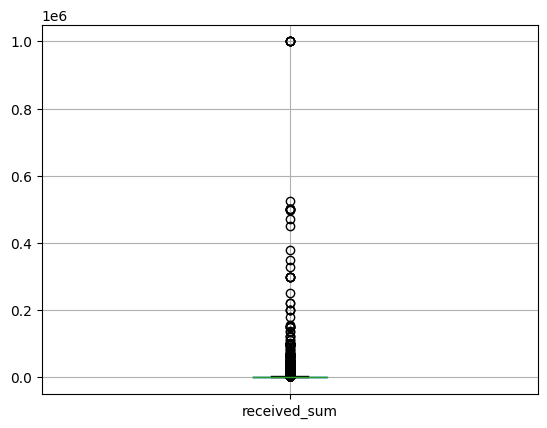

count     34320.00
mean       2165.79
std       17478.40
min           0.01
25%         300.00
50%         550.00
75%        1400.00
max     1000000.00
Name: received_sum, dtype: float64

In [49]:
# Строим диаграмму размаха по столбцу received_sum
data_2022_2024_filtered.boxplot(column='received_sum');
plt.show();

# Выводим на экран числовое описание данных
data_2022_2024_filtered['received_sum'].describe()

**Представленные данные говорят о том, что в столбце присутствуют платежи меньше 1 рубля и равные 1 млн рублей. При этом среднее значение больше медианы в 4 раза и больше 3-го квартиля в 1,5 раза, что говорит о том, что ранее упомянутые выбросы существенно влияют на среднее значение из-за своей величины.** Однако при дальнейшем анализе их можно будет убрать, чтобы снизить влияние на среднее значение.

Проверим, сколько записей составляют значения меньше 5 руб. для того, чтобы решить, какие данные оставить для дальнейшего исследования. Значение в 5 руб. принято на основании предположения о том, что столь небольших пожертвований немного, а также по причине того, что при перечислении пожертвований банковская комиссия снижает и без того небольшую сумму получаемых средств, в связи с чем они имеют минимальную пользу и ценность для благотворительного фонда.

In [50]:
data_2022_2024_filtered.query('received_sum < 5')['received_sum'].value_counts()

received_sum
1.00    28
2.00     4
4.00     3
0.01     3
3.00     2
Name: count, dtype: int64

**Распределение данных в столбце говорит о том, что значений меньше 5 руб. не очень много - всего 40 строк. Так как указанных значений немного и они не оказывают существенного влияния на данные, удалим такие записи из датасета.**

In [51]:
# Убираем из датасета строки со значениями меньше 5 руб. в столбце received_sum
data_2022_2024_filtered = data_2022_2024_filtered.query('received_sum >= 5')

# Проверяем успешность удаления указааных значений из датасета
data_2022_2024_filtered.query('received_sum < 5')

,id,user_id,company_id,user_gender,country,region,city,payment_date,payment_id,received_sum,comment,transaction_type,event_code,event_name


Указанные данные успешно удалены.

Проверим, насколько сильно изменилось количество данных после предобработки и изменения или удаления аномальных значений. Для этого сравним размер изначального датасета, записанного в переменную `data_2022_2024_shape` и датасета с отфильтрованными данными, размер которого мы запишем в переменную `data_2022_2024_filtered_shape`.

In [52]:
# Выводим информацию об исходном количестве данных
print('Размер исходного датасета:', data_2022_2024_shape)
print('Количество строк:', data_2022_2024_shape[0])
print('Количество столбцов:', data_2022_2024_shape[1])

print()

# Записываем информацию об отфильтрованном количестве данных при помощи метода shape()
data_2022_2024_filtered_shape = data_2022_2024_filtered.shape
print('Размер отфильтрованного датасета:', data_2022_2024_filtered_shape)
print('Количество строк:', data_2022_2024_filtered_shape[0])
print('Количество столбцов:', data_2022_2024_filtered_shape[1])

Размер исходного датасета: (58161, 14)
Количество строк: 58161
Количество столбцов: 14

Размер отфильтрованного датасета: (34280, 14)
Количество строк: 34280
Количество столбцов: 14


В соответствии с представленным выводом данных можно отметить, что количество строк в отфильтрованном датасете уменьшилось - с 58,1 тыс. до 34,3 тыс., так как мы удалили часть пустых строк, а также отрицательные, нулевые и значения меньше 5 руб. в столбце `received_sum`, а также убрали пожертвования компаний в отдельным датасет. При этом количество столбцов осталось неизменным. Сравним количество строк отфильтрованного и исходного датасетов.

In [53]:
print(round(data_2022_2024_filtered_shape[0]/data_2022_2024_shape[0]*100, 2), '%')

58.94 %


**В соответствии с проведенным расчетом, после предобработки и изменения или удаления аномальных значений в отфильтрованном датасете осталось 58,94% строк исходных данных, что является не очень хорошим, но допустимым результатом при ограниченном наборе данных.**

Перейдем к анализу метрик.

### Анализ метрик

Для начала рассчитаем общую и среднюю сумму пожертвований, полученных благотворительным фондом за 2022-2024 гг. при помощи методов `sum()` и `mean()`.

In [54]:
print('Общая сумма пожертвований, полученных благотворительным фондом за 2022-2024 гг., составила:', round(data_2022_2024_filtered['received_sum'].sum(), 2), 'руб.')
print('Средняя сумма пожертвований, полученных благотворительным фондом за 2022-2024 гг., составила:', round(data_2022_2024_filtered['received_sum'].mean(), 2), 'руб.')
print('Медиана пожертвований, полученных благотворительным фондом за 2022-2024 гг., составила:', round(data_2022_2024_filtered['received_sum'].median(), 2), 'руб.')

Общая сумма пожертвований, полученных благотворительным фондом за 2022-2024 гг., составила: 74330017.4 руб.
Средняя сумма пожертвований, полученных благотворительным фондом за 2022-2024 гг., составила: 2168.32 руб.
Медиана пожертвований, полученных благотворительным фондом за 2022-2024 гг., составила: 550.0 руб.


Общая сумма пожертвований за рассматриваемый период составила более 74,3 млн руб., среднее значение составило 2,2 тыс. руб., что является немного завышенным значением из-за наличия в датасете крупных пожертвований в размере до 1 млн руб. тогда как медиана составляет 550 руб.

Рассмотрим данные метрики по годам. Для этого построим сводную таблицу методом `pivot_table()`.

In [55]:
# Группируем пожертвования при помощи сводной таблицы
total_donations_2022_2024 = data_2022_2024_filtered.pivot_table(
    columns=data_2022_2024_filtered['payment_date'].dt.year,
    values='received_sum',
    aggfunc={'received_sum':['mean', 'median', 'sum']}
)

# Переименовываем строки
total_donations_2022_2024.index=('Среднее значение', 'Медиана', 'Общая сумма')

# Выводим полученную сводную таблицу на экран
total_donations_2022_2024

payment_date,2022,2023,2024
Среднее значение,2245.31,2069.87,2181.28
Медиана,550.00,590.00,500.00
Общая сумма,27725035.56,22942421.84,23662560.00


Полученная сводная таблица говорит о том, что:
- среднее значение пожертвования было наиболее высоким в 2022 г., что может быть обусловлено большим количеством крупных платежей;
- для медианы, в свою очередь, наибольшее значение было зафиксировано в 2023 г., что может быть связано со снижением количества крупных платежей в указанный период вследствие каких-либо изменений
- наконец наибольшее значение общей суммы пожертвования зафиксировано также в 2022 г., что, как уже было упомянуто выше, может быть связано с большим количеством крупных платежей.

**Зафиксированные колебания размеров пожертвований за рассматриваемый период могут быть связаны с проведением акций благотворительным фондом в определенные периоды времени, а также с политической и экономической обстановкой в стране, из-за чего клиенты (жертвователи) могли предпочесть использовать свои денежные средства на другие нужды.**

#### Динамика средней суммы пожертвования за рассматриваемый период

Проанализируем динамику средней суммы пожертвований клиентов (жертвователей). Для этого построим линейную диаграмму в разрезе рассматриваемых периодов (2022, 2023, 2024 гг.) по месяцам при помощи метода `plot()`, убрав из датасета пожертвования больше 200 тыс. руб.

**Выбор пожертвований в размере менее 200 тыс. руб. обусловлен тем, что согласно построенной диаграмме размаха в пункте 4.1, значительная часть крупных пожертвований находится в диапазоне от 100 до 200 тыс. руб., в связи с чем их удаление может снизить точность результатов исследования, тогда как пожертвования более 200 тыс. руб. являются единичными случаями, которые могут существенно исказить формируемые графики и усложнить поиск периодов набольшей активности клиентов (жертвователей) вследствие их сильного влияния на среднее значение суммы пожертвования.** Таким образом, для дальнейшего анализа предпочтительным является оставить пожертвования менее 200 тыс. руб.

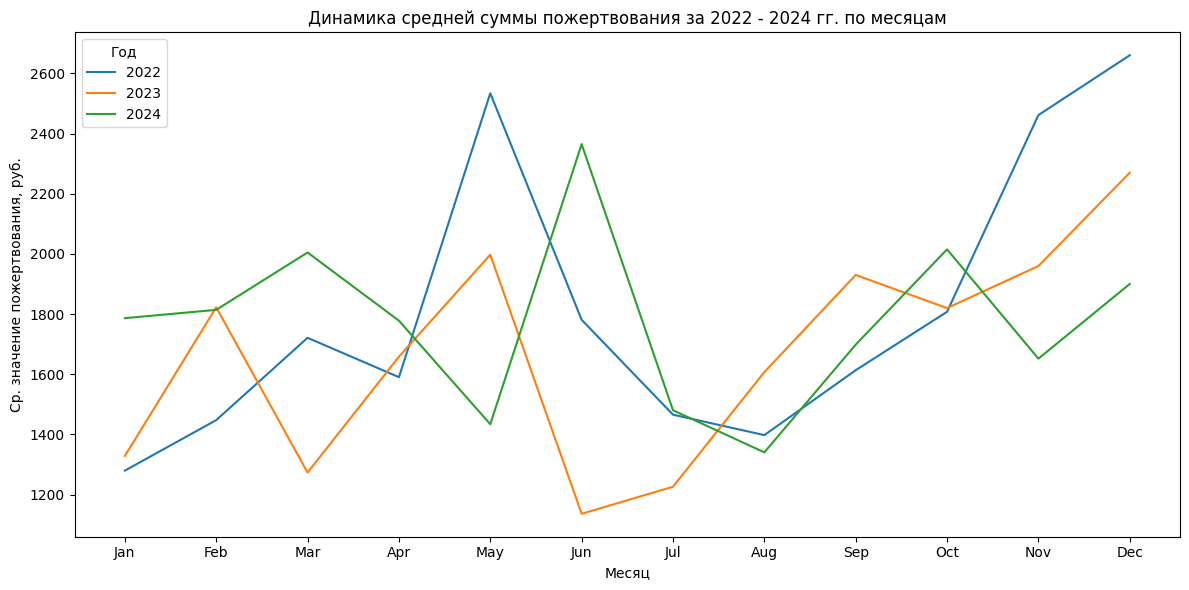

In [56]:
ax = (
    data_2022_2024_filtered
    .query('received_sum < 200000')
    .pivot_table(index=data_2022_2024_filtered['payment_date'].dt.month,
                 columns=data_2022_2024_filtered['payment_date'].dt.year,
                 values='received_sum',
                 aggfunc='mean')
    .plot(figsize=(12, 6), grid=False)
)
plt.xticks(ticks=np.arange(1, 13, step=1), labels=['Jan', 'Feb', 'Mar', 'Apr', 'May', 'Jun', 'Jul', 'Aug', 'Sep', 'Oct', 'Nov', 'Dec'])
plt.title('Динамика средней суммы пожертвования за 2022 - 2024 гг. по месяцам')
plt.ylabel('Ср. значение пожертвования, руб.')
plt.xlabel('Месяц')
plt.legend(title='Год')
plt.tight_layout()
plt.show();

Представленная линейная диаграмма говорит о том, что рост среднего значения пожертвования зафиксирован в:
- мае и ноябре - декабре 2022 г.;
- феврале, мае, сентябре - декабре 2023 г.;
- марте, июне и октябре 2024 г.

Так как данные в данном случае представлены по месяцам, затруднительно точно определить периоды, в которых был зафиксирован рост среднего значения пожертвования. Повторно построим линейный график, но уже в разрезе дат, для уточнения указанных периодов.

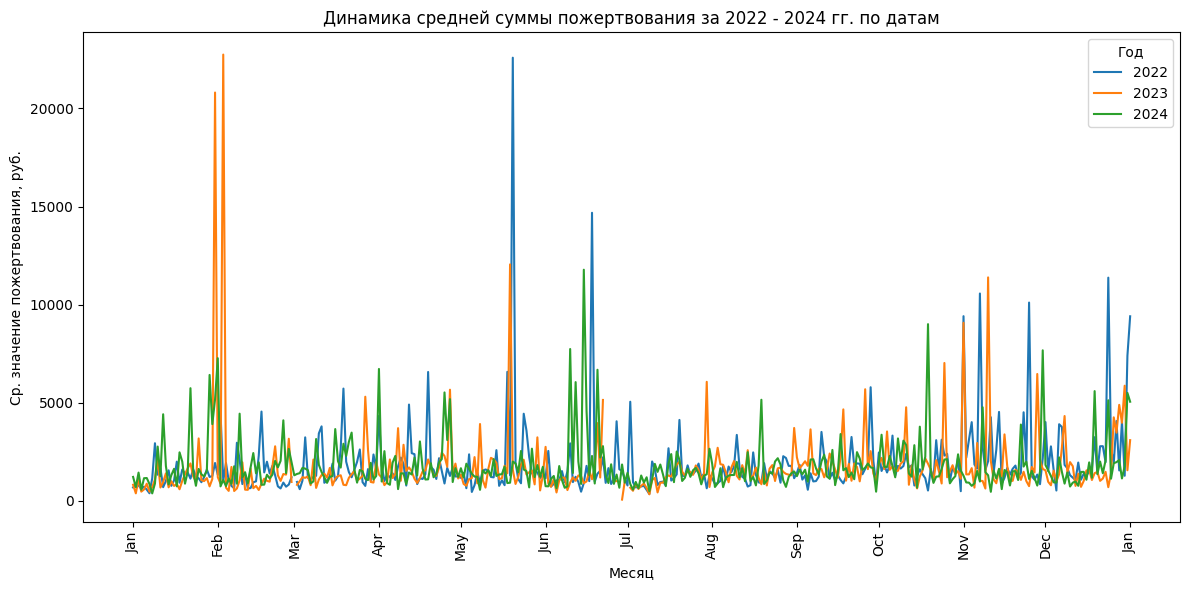

In [57]:
ax = (
    data_2022_2024_filtered
    .query('received_sum < 200000')
    .pivot_table(index=data_2022_2024_filtered['payment_date'].dt.strftime('%m-%d'),
                 columns=data_2022_2024_filtered['payment_date'].dt.year,
                 values='received_sum',
                 aggfunc='mean')
    .plot(figsize=(12, 6), grid=False)
)
ax.xaxis.set_major_locator(MonthLocator())
ax.xaxis.set_major_formatter(DateFormatter("%b"))
plt.xticks(rotation='vertical')
plt.title('Динамика средней суммы пожертвования за 2022 - 2024 гг. по датам')
plt.ylabel('Ср. значение пожертвования, руб.')
plt.xlabel('Месяц')
plt.legend(title='Год')
plt.tight_layout()
plt.show();

Представленная линейная диаграмма говорит о том, что:
- **наибольшая средняя сумма пожертвования зафиксирована в середине мая 2022 г. - более 20 тыс. руб., середине июня 2022 г. - около 15 тыс. руб., в конце января - начале февраля 2023 г. - более 20 тыс. руб. и в середине июня 2024 г. - более 12 тыс. руб., что может быть обусловлено проведением акций благотворительного фонда в указанные периоды и требует проверки**;
- также зафиксировано увеличение средней суммы пожертвований каждый ноябрь - декабрь;
- чаще всего наибольшая средняя сумма пожертвования фиксируется где-то в середине месяца;
- средняя сумма пожертвования преимущественно находится в диапазоне от 100 до 2500 руб. за весь рассматриваемый период, за исключением конца июня 2023 г., где она снижалась практически до 0.

Рассмотрим динамику средней суммы пожертвований в разрезе периодов, указанных выше.

##### Динамика средней суммы пожертвования в 2022 г.

В первую очередь рассмотрим 2022 г., а именно период с мая по декабрь.

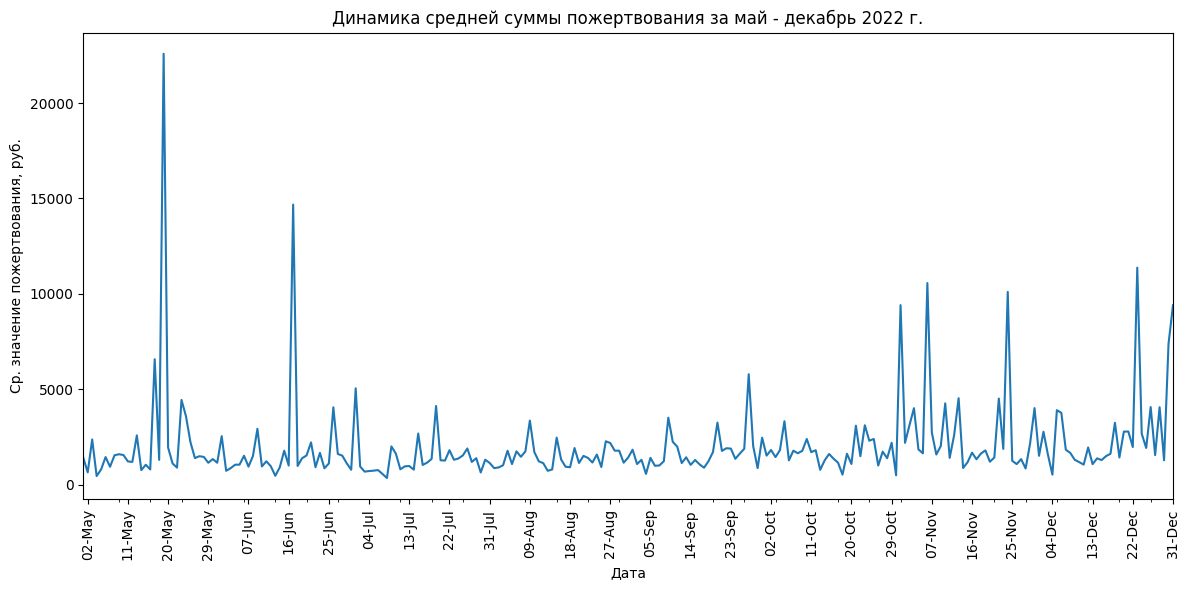

In [58]:
ax = (
    data_2022_2024_filtered[data_2022_2024_filtered['payment_date'].between('2022-05-01', '2022-12-31')]
    .query('received_sum < 200000')
    .groupby(data_2022_2024_filtered['payment_date'])['received_sum'].mean()
    .plot(figsize=(12, 6), grid=False)
)
ax.xaxis.set_major_locator(DayLocator(interval=9))
ax.xaxis.set_major_formatter(DateFormatter('%d-%b'))
ax.tick_params(axis='x', labelrotation= 90)
plt.title('Динамика средней суммы пожертвования за май - декабрь 2022 г.')
plt.ylabel('Ср. значение пожертвования, руб.')
plt.xlabel('Дата')
plt.tight_layout()
plt.show();

Сформированная линейная диаграмма говорит о том, что наибольшие пожертвования зафиксированы в районе 17 - 20 мая, 16 - 20 июня, а также в период с 30 октября по 31 декабря 2022 г. При помощи среза данных методом `query()` и сортировки значений методом `sort_values()` по убыванию просмотрим данные за указанные периоды.

Сначала рассмотрим данные за 17 - 20 мая 2022 г.

In [59]:
(
    data_2022_2024_filtered[data_2022_2024_filtered['payment_date'].between('2022-05-17', '2022-05-20')]
    .query('received_sum < 200000')
    .sort_values(by='received_sum', ascending=False)
    .head(20)
)

,id,user_id,company_id,user_gender,country,region,city,payment_date,payment_id,received_sum,comment,transaction_type,event_code,event_name
2640,255069,406897,<NA>,NaN,Россия,Москва,Москва,2022-05-19,NaN,180000.00,лот Водолазкина,Пожертвование разовое,f208,NaN
3010,244005,438703,<NA>,NaN,Россия,NaN,NaN,2022-05-19,NaN,154500.00,Вход и пожертвования на концерте Амарии 19.05.22,Пожертвование разовое,f208,NaN
3145,272505,437517,<NA>,NaN,Россия,NaN,Москва,2022-05-19,NaN,150000.00,лот Вино,Пожертвование разовое,f208,NaN
3237,217981,441331,<NA>,NaN,Россия,Москва,Москва,2022-05-17,NaN,100000.00,NaN,Пожертвование рекуррент,f112,NaN
3235,201009,401259,<NA>,Ж,Россия,Москва,Москва,2022-05-19,NaN,80000.00,лот Пушкинский экскурсия,Пожертвование разовое,f208,NaN
193,263889,410687,<NA>,М,Россия,Москва,Москва,2022-05-17,cloud:1146774361,60000.00,NaN,Пожертвование разовое,f209,NaN
3236,201011,401259,<NA>,Ж,Россия,Москва,Москва,2022-05-19,NaN,55000.00,лот Артбук Андрюша,Пожертвование разовое,f208,NaN
2479,169987,426545,<NA>,NaN,Россия,NaN,NaN,2022-05-19,NaN,50000.00,тихий лот Фоторабота А. Белоусовой из школы Родченко,Пожертвование разовое,f208,NaN
3028,244975,400265,<NA>,NaN,Россия,NaN,NaN,2022-05-19,NaN,50000.00,NaN,Пожертвование разовое,f208,NaN
3146,272507,437519,<NA>,NaN,Россия,NaN,Москва,2022-05-19,NaN,50000.00,пожертвование +подарили 2 кружки,Пожертвование разовое,f208,NaN


Полученный срез данных говорит о том, что **19 мая 2022 г. проходил концерт, в рамках которого благотворительный фонд получил несколько пожертвований в размере 50 тыс. руб. и более**. Это также подтверждается кодом мероприятия - `f208`, который означает `мероприятия ВИД, концерт`. Также за данный период были получены следующие крупные рекуррентные пожертвования - одно в размере 100 тыс. руб. с кодом `f112 (ВИД Регулярные списания`), а другое в размере 10 тыс. руб. с кодом `f212 (Частные доноры Регулярные пожертвования`).

Рассмотрим данные за 16 - 20 июня 2022 г.

In [60]:
(
    data_2022_2024_filtered[data_2022_2024_filtered['payment_date'].between('2022-06-16', '2022-06-20')]
    .query('received_sum < 200000')
    .sort_values(by='received_sum', ascending=False)
    .head(20)
)

,id,user_id,company_id,user_gender,country,region,city,payment_date,payment_id,received_sum,comment,transaction_type,event_code,event_name
2396,324419,441331,<NA>,NaN,Россия,Москва,Москва,2022-06-17,NaN,100000.00,NaN,Пожертвование рекуррент,f112,NaN
2400,324691,441331,<NA>,NaN,Россия,Москва,Москва,2022-06-17,NaN,100000.00,NaN,Пожертвование рекуррент,f112,NaN
3241,217997,441331,<NA>,NaN,Россия,Москва,Москва,2022-06-17,NaN,100000.00,NaN,Пожертвование рекуррент,f112,NaN
3187,273505,437561,<NA>,NaN,Россия,Ленинградская область,Санкт-Петербург,2022-06-20,NaN,15000.00,NaN,Пожертвование разовое,f209,NaN
6158,212571,399913,<NA>,NaN,Россия,Воронежская область,Воронеж,2022-06-20,cloud:1204088635,15000.00,NaN,Пожертвование разовое,f215,th
2125,209421,419287,<NA>,NaN,Россия,Санкт-Петербург,Санкт-Петербург,2022-06-20,cloud:1204188092,10000.00,NaN,Пожертвование рекуррент,f212,NaN
2159,247005,413093,<NA>,NaN,Россия,Московская область,Москва,2022-06-16,cloud:1197156222,10000.00,NaN,Пожертвование рекуррент,f212,NaN
2179,270585,420065,<NA>,NaN,Россия,NaN,NaN,2022-06-19,cloud:1202073529,10000.00,NaN,Пожертвование рекуррент,f212,NaN
3254,279909,413443,<NA>,NaN,Россия,Москва,Москва,2022-06-20,NaN,10000.00,NaN,Пожертвование разовое,f215,th
2119,208493,404059,<NA>,Ж,Россия,Москва,Москва,2022-06-16,cloud:1197516210,6000.00,NaN,Пожертвование разовое,f214,NaN


**За период 16 - 20 июня 2022 г. наибольший объем пожертвований зафиксирован от клиента (жертвователя) с идентификатором `441331` - 3 платежа по 100 тыс. руб. Данный идентификатор также присутствует в срезе за 17 - 20 мая 2022 г. с аналогичным размером пожертвования, что говорит о регулярности платежей со стороны данного клиента (жертвователя) - код мероприятия такой же, что и ранее - `f112` (`ВИД Регулярные списания`).**

Также за указанный период были получены пожертвования в размере 15 тыс. руб. по кодам `f209 (ВИД пожертвования`), `f215 (пожертвования через СМС и спец ссылки`) и `f212 (Частные доноры Регулярные пожертвования`). Некоторые пожертвования были переведены в рамках акции `EN_6let`.

Рассмотрим данные с 30 октября по 31 декабря 2022 г.

In [61]:
(
    data_2022_2024_filtered[data_2022_2024_filtered['payment_date'].between('2022-10-30', '2022-12-31')]
    .query('received_sum < 200000')
    .sort_values(by='received_sum', ascending=False)
    .head(20)
)

,id,user_id,company_id,user_gender,country,region,city,payment_date,payment_id,received_sum,comment,transaction_type,event_code,event_name
14564,327163,437333,<NA>,NaN,Россия,Москва,Москва,2022-11-06,cloud:1416350720,154000.00,"Разовое пожертвование в БФ ""Синдром любви""",Пожертвование разовое,f215,Не просто слова
14512,332285,466803,<NA>,NaN,NaN,NaN,Ереван,2022-12-30,cloud:1481508786,100000.00,"Разовое пожертвование в БФ ""Синдром любви""",Пожертвование разовое,f209,MA_PRT
14635,328529,343919,<NA>,NaN,Россия,NaN,NaN,2022-11-24,cloud:1438106244,100000.00,"Разовое пожертвование в БФ ""Синдром любви""",Пожертвование разовое,f405,NaN
13775,328927,465813,<NA>,М,NaN,NaN,Москва,2022-11-30,cloud:1445276784,100000.00,"Разовое пожертвование в БФ ""Синдром любви""",Пожертвование разовое,f209,NaN
9575,326629,434357,<NA>,NaN,Россия,NaN,NaN,2022-10-31,cloud:1408918114,100000.00,"Разовое пожертвование ""День рождения""",Пожертвование разовое,f215,th
14523,332313,466473,<NA>,Ж,NaN,NaN,Москва,2022-12-31,cloud:1482270636,100000.00,"Разовое пожертвование в БФ ""Синдром любви""",Пожертвование разовое,f209,MA_PRT
13974,329659,465625,<NA>,Ж,NaN,NaN,Ярославль,2022-12-05,cloud:1450890338,100000.00,"Разовое пожертвование в БФ ""Синдром любви""",Пожертвование разовое,f209,MA_1.12
14640,329379,343919,<NA>,NaN,Россия,NaN,NaN,2022-12-02,cloud:1447706539,100000.00,"Разовое пожертвование в БФ ""Синдром любви""",Пожертвование разовое,f405,NaN
14662,332061,400273,<NA>,NaN,Россия,Москва,Москва,2022-12-28,cloud:1478720412,100000.00,"Разовое пожертвование в БФ ""Синдром любви""",Пожертвование разовое,f111,EN_27.12.22
14664,332187,349833,<NA>,NaN,Россия,NaN,NaN,2022-12-30,cloud:1480778733,100000.00,"Пожертвование в рамках акции ""Наполним сани чудесами!"", 100000",Пожертвование разовое,f215,elki2023


Полученный срез данных говорит о том, что **ряд крупных пожертвований был сделан в рамках акции `MA_PRT` 20 декабря 2022 г., в рамках которой благотворительный фонд получил несколько пожертвований в размере 70 тыс. руб. и более** Это также подтверждается кодом мероприятия - `f209`, который означает `ВИД пожертвования`. Также **24 ноября и 2 декабря были получены два крупных разовых пожертвования в размере 100 тыс. руб. от клиента (жертвователя) с идентификатором `343919`** по коду мероприятия `f405 (Социальный маркетинг, пожертвования сотрудников (кроме АВБ))`.

Также **23 и 26 декабря зафиксировано три пожертвования в рамках акции `MA_rostelecom_23.12.2022`**, код мероприятия `f114 (ВИД массовые акции)`, которые составляют 50 и 65 тыс. руб., а **30 декабря было получено пожертвования в рамках акции `elki2023`**, код мероприятия `f405 (Социальный маркетинг, пожертвования сотрудников (кроме АВБ))`, наиболее крупные пожертвования в рамках которой принесли благотворительному фонду 68,4 и 100 тыс. руб. соответственно.

##### Динамика средней суммы пожертвования в 2023 г.

Рассмотрим среднюю сумму пожертвования за 2023 г.

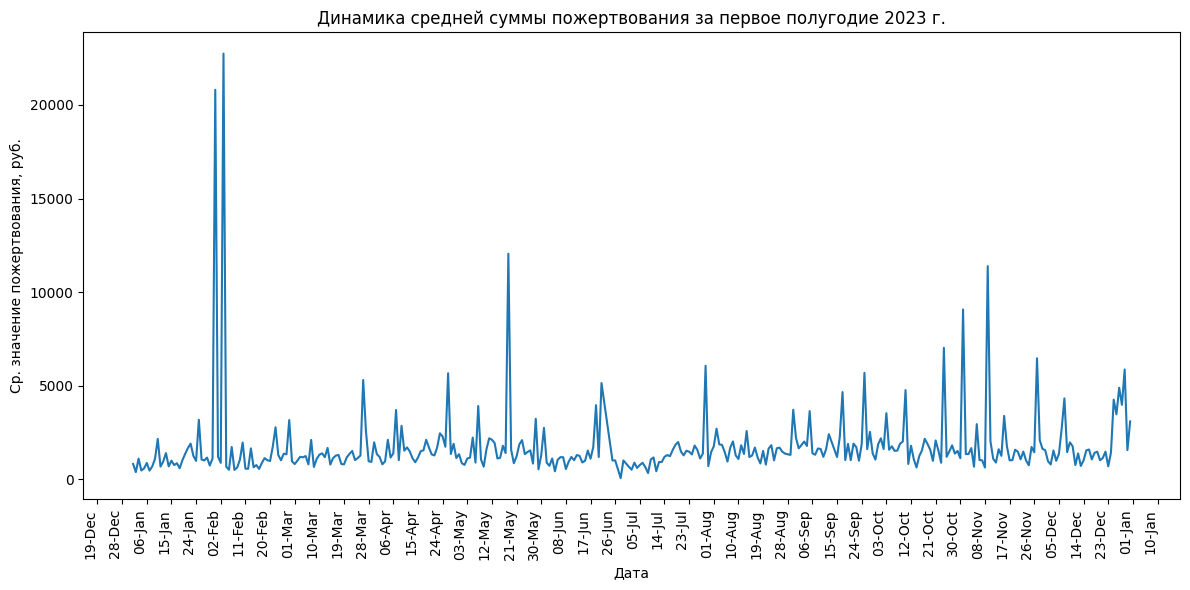

In [62]:
ax = (
    data_2022_2024_filtered[data_2022_2024_filtered['payment_date'].between('2023-01-01', '2023-12-31')]
    .query('received_sum < 200000')
    .groupby(data_2022_2024_filtered['payment_date'])['received_sum'].mean()
    .plot(figsize=(12, 6), grid=False)
)
ax.xaxis.set_major_locator(DayLocator(interval=9))
ax.xaxis.set_major_formatter(DateFormatter('%d-%b'))
ax.tick_params(axis='x', labelrotation= 90)
plt.title('Динамика средней суммы пожертвования за первое полугодие 2023 г.')
plt.ylabel('Ср. значение пожертвования, руб.')
plt.xlabel('Дата')
plt.tight_layout()
plt.show();

В данном случае на графике сильно выделяется период с 30 января по 5 февраля, 16 - 20 мая, 20 - 26 июня, 25 июля - 1 августа и 21 октября - 31 декабря 2023 г. При помощи среза данных методом `query()` и сортировки значений методом `sort_values()` по убыванию просмотрим данные за указанные периоды.

Сначала рассмотрим данные за 30 января - 5 февраля 2023 г.

In [63]:
(
    data_2022_2024_filtered[data_2022_2024_filtered['payment_date'].between('2023-01-30', '2023-02-05')]
    .query('received_sum < 200000')
    .sort_values(by='received_sum', ascending=False)
    .head(20)
)

,id,user_id,company_id,user_gender,country,region,city,payment_date,payment_id,received_sum,comment,transaction_type,event_code,event_name
17666,340791,406897,<NA>,NaN,Россия,Москва,Москва,2023-02-03,NaN,100000.00,лот от курорта Завидово на Устрицах 2023,Пожертвование разовое,f208,NaN
18352,334213,419617,<NA>,NaN,Россия,Москва,Москва,2023-01-31,cloud:1520594632,100000.00,"Разовое пожертвование в БФ ""Синдром любви""",Пожертвование разовое,f209,NaN
17726,340801,469547,<NA>,NaN,NaN,NaN,NaN,2023-02-03,NaN,100000.00,NaN,Пожертвование разовое,f208,NaN
17724,340795,469543,<NA>,NaN,NaN,NaN,NaN,2023-02-03,NaN,90000.00,Лот фигурка Лего на Устрицах 2023,Пожертвование разовое,f208,NaN
17725,340799,469545,<NA>,NaN,NaN,NaN,NaN,2023-02-03,NaN,25000.00,Лот футболка Тотти на Устрицах 2023,Пожертвование разовое,f208,NaN
18428,334605,364839,<NA>,NaN,Россия,Краснодарский край,Краснодар,2023-01-30,cloud:1518387281,10343.99,Заказ №102126 от 30.01.2023,Продажа,f517,action
18401,334431,342333,<NA>,NaN,Россия,Москва,Москва,2023-02-03,cloud:1524332256,10000.00,"Разовое пожертвование в БФ ""Синдром любви""",Пожертвование разовое,f208,MA_03.02.23
18354,334221,417145,<NA>,NaN,Россия,Москва,Москва,2023-02-01,cloud:1521275937,7000.00,"Разовое пожертвование в БФ ""Синдром любви""",Пожертвование разовое,f214,NaN
18397,334397,435445,<NA>,NaN,Россия,NaN,Москва,2023-02-03,cloud:1524064933,5000.00,"Разовое пожертвование в БФ ""Синдром любви""",Пожертвование разовое,f208,NaN
18377,334315,343657,<NA>,NaN,Россия,NaN,NaN,2023-02-02,cloud:1522764207,3000.00,Поддержать соревнование,Взнос,f201,Cycling-марафон-2022-11-


Полученный срез данных говорит о том, что **2 марта 2023 г. проходило мероприятие `Устрицы 2023`, в рамках которого благотворительный фонд получил несколько пожертвований в размере от 25 до 100 тыс. руб.** Это также подтверждается кодом мероприятия - `f208`, который означает `мероприятия ВИД, концерт`. Также **2 февраля 2023 г. прохоидло мероприятие `Cycling-марафон-2022-11-`, в рамках которого благотворительный фонд получил несколько взносов в размере 2-3 тыс. руб. по коду `f201 (СВБ инд. учстники велосотня)`**.

Также **1 января 2023 г. было получено большое разовое пожертвование от клиента (жертвователя) с идентификатором `419617` в размере 100 тыс. руб. по коду мероприятия `f209 (ВИД пожертвования)`**.

Рассмотрим данные за 16 - 20 мая 2023 г.

In [64]:
(
    data_2022_2024_filtered[data_2022_2024_filtered['payment_date'].between('2023-05-16', '2023-05-20')]
    .query('received_sum < 200000')
    .sort_values(by='received_sum', ascending=False)
    .head(20)
)

,id,user_id,company_id,user_gender,country,region,city,payment_date,payment_id,received_sum,comment,transaction_type,event_code,event_name
14781,375061,486803,<NA>,Ж,NaN,NaN,Дюссельдорф,2023-05-18,cloud:1676341418,135000.00,"Разовое пожертвование в БФ ""Синдром любви""",Пожертвование разовое,f114,MA_08.04_theatre
17680,348259,416075,<NA>,NaN,Россия,Москва,Москва,2023-05-18,NaN,95000.00,лот Алкогольный дуэт (бурбон+виски от Фортвайн) на концерте Налича 18.05.2023,Пожертвование разовое,f208,NaN
17679,348257,416075,<NA>,NaN,Россия,Москва,Москва,2023-05-18,NaN,70000.00,лот Футбольный мяч с автографами звезд на концерте Налича 18.05.2023,Пожертвование разовое,f208,NaN
17840,348263,334671,<NA>,NaN,Россия,Москва,Москва,2023-05-18,NaN,70000.00,лот Тарелка Пачоли на концерте Налича 18.05.2023,Пожертвование разовое,f208,NaN
17803,348261,471261,<NA>,М,NaN,NaN,NaN,2023-05-18,NaN,65000.00,лот Картина Васи Ложкина на концерте Налича 18.05.2023,Пожертвование разовое,f208,NaN
17804,348267,471263,<NA>,Ж,NaN,NaN,NaN,2023-05-18,NaN,50000.00,Лот Каталог Пушкинского музея на концерте Налича 18.05.2023,Пожертвование разовое,f208,NaN
17295,345517,463087,<NA>,Ж,NaN,NaN,Москва,2023-05-19,cloud:1677271693,20000.00,"Разовое пожертвование ""Благотворительный концерт в пользу людей с синдромом Дауна""",Пожертвование разовое,f208,blagotvoritelnyy-kontsert-2023
17240,345173,470649,<NA>,М,NaN,NaN,Москва,2023-05-16,cloud:1672730806,15000.00,"Разовое пожертвование ""Благотворительный концерт в пользу людей с синдромом Дауна""",Пожертвование разовое,f208,blagotvoritelnyy-kontsert-2023
20592,345439,349501,<NA>,NaN,Россия,NaN,NaN,2023-05-18,cloud:1675451907,15000.00,"Разовое пожертвование в БФ ""Синдром любви""",Пожертвование разовое,f208,NaN
17227,345117,465625,<NA>,Ж,NaN,NaN,Ярославль,2023-05-16,cloud:1671839895,10000.00,"Ежемесячное пожертвование в БФ ""Синдром любви""",Пожертвование рекуррент,f112,NaN


Полученный срез данных говорит о том, что **18 мая 2023 г. проходил `концерт Налича` и `Благотворительный концерт в пользу людей с синдромом Дауна` (код в столбце `event_name` - `blagotvoritelnyy-kontsert-2023`), в рамках которого благотворительный фонд получил несколько пожертвований в размере 50 тыс. руб. и более (вплоть до 95 тыс. руб.).** Это также подтверждается кодом мероприятия - `f208`, который означает `мероприятия ВИД, концерт`. При этом **в рамках данного мероприятия были получены два разовых пожертвования от одного клиента (жертвователя) с идентификатором `416075` в размере 95 и 75 тыс. руб. соответственно**.

**Также в этот же день было получено разовое пожертвование от клиента с идентификатором `486803` в размере 135 тыс. руб.** - код мероприятия в данном случае имеет значение `f114 (ВИД массовые акции)`, а в столбце `event_name` содержится значение `MA_08.04_theatre`. Согласно информации, предоставленной заказчиком, данный код означает `Личные коммуникации с ВИДами, все те пожертвования, когда менеджер отправляет ссылку ВИДу напрямую, используем, когда точно знаем, что человек ВИД`, что может говорить о том, что такое пожертвовании заранее обсуждается с сотрудниками благотворительного фонда.

Рассмотрим данные с 20 - 26 июня 2023 г.

In [65]:
(
    data_2022_2024_filtered[data_2022_2024_filtered['payment_date'].between('2023-06-20', '2023-06-26')]
    .query('received_sum < 200000')
    .sort_values(by='received_sum', ascending=False)
    .head(20)
)

,id,user_id,company_id,user_gender,country,region,city,payment_date,payment_id,received_sum,comment,transaction_type,event_code,event_name
17814,348413,471277,<NA>,Ж,NaN,NaN,NaN,2023-06-20,NaN,15000.00,NaN,Пожертвование разовое,f209,NaN
14675,346985,471109,<NA>,Ж,NaN,NaN,Санкт-Петербург,2023-06-21,cloud:1741217271,5411.02,Заказ №108037 от 21.06.2023,Продажа,f517,action
14673,346981,355467,<NA>,NaN,Россия,Санкт-Петербург,Санкт-Петербург,2023-06-21,cloud:1740940080,5000.00,Заказ №108026 от 21.06.2023,Продажа,f517,action
14674,346983,471107,<NA>,Ж,NaN,NaN,Москва,2023-06-21,cloud:1741160427,5000.00,Заказ №108034 от 21.06.2023,Продажа,f517,action
14746,347447,471159,<NA>,NaN,NaN,NaN,Москва,2023-06-20,cloud:1739051050,2000.00,Пожертвование проекту Помощь самым маленьким,Пожертвование разовое,NaN,NaN
14747,347453,468743,<NA>,Ж,NaN,NaN,Москва,2023-06-20,cloud:1739097211,2000.00,"Разовое пожертвование ""Фонду ""Синдром любви"" 7 лет!""",Пожертвование разовое,f215,th
14750,347463,471163,<NA>,Ж,NaN,NaN,Москва,2023-06-20,cloud:1739132904,1500.00,"Разовое пожертвование ""Фонду ""Синдром любви"" 7 лет!""",Пожертвование разовое,f215,th
14755,347477,471167,<NA>,М,NaN,NaN,Москва,2023-06-20,cloud:1739211272,1000.00,"Разовое пожертвование ""Фонду ""Синдром любви"" 7 лет!""",Пожертвование разовое,f215,th
17818,348465,469599,<NA>,NaN,NaN,NaN,Брянск,2023-06-26,NaN,1000.00,NaN,Пожертвование разовое,f214,NaN
17815,348437,467271,<NA>,NaN,NaN,NaN,Москва,2023-06-25,NaN,1000.00,NaN,Пожертвование рекуррент,f212,NaN


**В данном случае максимальное значение пожертвования, полученного 20 июня, составило 15 тыс. руб., при этом оно является разовым и имеет код мероприятия `f209 (ВИД пожертвования)`.** Также 21 июня было получено три пожертвования на сумму около 5 тыс. руб., которые являются продажами товаров фонда (код `f517 (Магазин)`). В рассматриваемом периоде мероприятия не проводились.

Рассмотрим данные с 25 июля по 1 августа 2023 г.

In [66]:
(
    data_2022_2024_filtered[data_2022_2024_filtered['payment_date'].between('2023-07-25', '2023-08-01')]
    .query('received_sum < 200000')
    .sort_values(by='received_sum', ascending=False)
    .head(20)
)

,id,user_id,company_id,user_gender,country,region,city,payment_date,payment_id,received_sum,comment,transaction_type,event_code,event_name
25874,350933,410687,<NA>,М,Россия,Москва,Москва,2023-07-29,cloud:1859632258,64300.00,"Разовое пожертвование в БФ ""Синдром любви""",Пожертвование разовое,f209,NaN
22384,350917,394435,<NA>,NaN,Россия,Москва,Москва,2023-07-29,cloud:1858856263,30000.00,"Разовое пожертвование в БФ ""Синдром любви""",Пожертвование разовое,f209,NaN
22343,350733,342193,<NA>,NaN,Россия,Москва,Москва,2023-07-25,cloud:1851040900,10000.00,"Ежемесячное пожертвование в БФ ""Синдром любви""",Пожертвование рекуррент,f112,NaN
25899,351025,348781,<NA>,NaN,Россия,NaN,NaN,2023-08-01,cloud:1863924604,10000.00,Поддержать соревнование,Пожертвование разовое,f207,Ультра Mari
22341,350727,471831,<NA>,Ж,NaN,NaN,Краснодар,2023-07-25,cloud:1850905212,5518.02,Заказ №109322 от 25.07.2023,Продажа,f517,action
22345,350759,471837,<NA>,Ж,NaN,NaN,Петропавловск-Камчатский,2023-07-26,cloud:1852655893,5300.00,Заказ №109343 от 26.07.2023,Продажа,f517,action
21555,350907,424621,<NA>,NaN,Россия,NaN,Москва,2023-07-29,cloud:1858748650,5000.00,"Разовое пожертвование в БФ ""Синдром любви""",Пожертвование разовое,f214,NaN
25838,350773,419353,<NA>,NaN,Россия,Москва,Москва,2023-07-26,cloud:1853578893,5000.00,"Ежемесячное пожертвование в БФ ""Синдром любви""",Пожертвование рекуррент,f112,NaN
22401,350989,470151,<NA>,Ж,NaN,NaN,Москва,2023-07-31,cloud:1862304773,5000.00,"Разовое пожертвование в БФ ""Синдром любви""",Пожертвование разовое,f211,EN_needs7.23
22372,350867,412913,<NA>,NaN,Россия,Москва,Москва,2023-07-28,cloud:1857236570,5000.00,"Ежемесячное пожертвование в БФ ""Синдром любви""",Пожертвование рекуррент,f112,NaN


Полученный срез данных говорит о том, что **29 июля 2023 г. было получено крупное разовое пожертвование в размере 64,3 тыс. руб. от клиента (жертвователя) с идентификатором `410687` по коду мероприятия `f209 (ВИД пожертвования)`**. При этом в рассматриваемом периоде мероприятия не проводились.

Рассмотрим данные с 21 октября - 31 декабря 2023 г.

In [67]:
(
    data_2022_2024_filtered[data_2022_2024_filtered['payment_date'].between('2023-10-21', '2023-12-31')]
    .query('received_sum < 200000')
    .sort_values(by='received_sum', ascending=False)
    .head(20)
)

,id,user_id,company_id,user_gender,country,region,city,payment_date,payment_id,received_sum,comment,transaction_type,event_code,event_name
27609,360517,410687,<NA>,М,Россия,Москва,Москва,2023-11-09,cloud:2022123731,102500.00,"Разовое пожертвование в БФ ""Синдром любви""",Пожертвование разовое,f209,NaN
24713,359787,478015,<NA>,NaN,NaN,NaN,Москва,2023-10-24,cloud:2003180718,100000.00,"Разовое пожертвование в БФ ""Синдром любви""",Пожертвование разовое,f209,MA_auction_FCDM
21581,365795,464767,<NA>,М,NaN,NaN,Москва,2023-12-29,cloud:2065489817,100000.00,"Разовое пожертвование в БФ ""Синдром любви""",Пожертвование разовое,f114,MA_PRT
21579,365611,400273,<NA>,NaN,Россия,Москва,Москва,2023-12-28,cloud:2064851653,100000.00,"Разовое пожертвование в БФ ""Синдром любви""",Пожертвование разовое,f209,NaN
21574,365473,349833,<NA>,NaN,Россия,NaN,NaN,2023-12-27,cloud:2064153521,100000.00,"Разовое пожертвование в рамках акции «Новогодний подарок!», 100000",Пожертвование разовое,f215,elki2024
24981,361137,478219,<NA>,М,NaN,NaN,Москва,2023-11-15,cloud:2029486039,90000.00,"Разовое пожертвование в БФ ""Синдром любви""",Пожертвование разовое,f215,Сцена - это маленькая жизнь
25321,367209,342465,<NA>,NaN,NaN,NaN,NaN,2023-12-07,NaN,75000.00,NaN,Пожертвование разовое,f109,NaN
21688,365731,410687,<NA>,М,Россия,Москва,Москва,2023-12-29,cloud:2065219240,64050.00,"Разовое пожертвование в БФ ""Синдром любви""",Пожертвование разовое,f209,NaN
21576,365527,412895,<NA>,NaN,Россия,Москва,Москва,2023-12-27,cloud:2064389202,50000.00,"Разовое пожертвование в БФ ""Синдром любви""",Пожертвование разовое,f114,MA_VSL
24754,360031,466811,<NA>,Ж,NaN,NaN,Москва,2023-10-31,cloud:2011953602,50000.00,"Разовое пожертвование ""День рождения""",Пожертвование разовое,f215,th


Полученный срез данных говорит о том, что **значительная часть крупных пожертвований была получена 26-28 декабря 2023 г. в рамках акции `elki2024` (коды `f215 (Пожертвования через СМС и спец ссылки)` и `f405(Социальный маркетинг, пожертвования сотрудников (кроме АВБ))`) и личных контактов сотрудников благотворительного фонда с ВИДами (код `f114 (ВИД массовые акции)`)**, которые составили от 21 до 100 тыс. руб.

##### Динамика средней суммы пожертвования в 2024 г.

Рассмотрим данные за первое полугодие 2024 г.

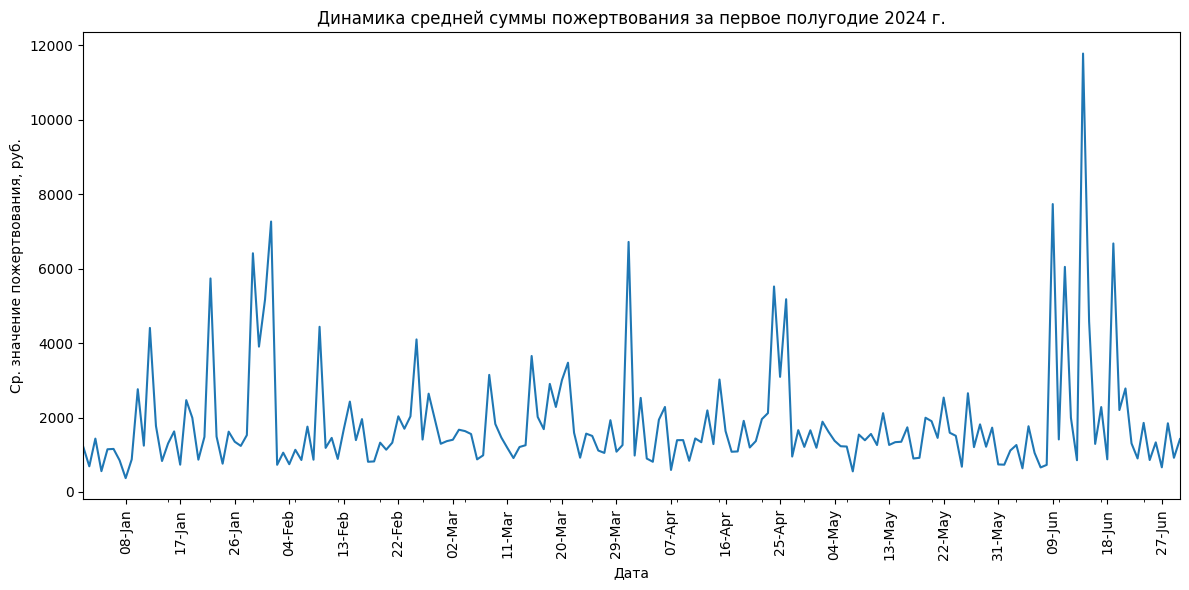

In [68]:
ax = (
    data_2022_2024_filtered[data_2022_2024_filtered['payment_date'].between('2024-01-01', '2024-06-30')]
    .query('received_sum < 200000')
    .groupby(data_2022_2024_filtered['payment_date'])['received_sum'].mean()
    .plot(figsize=(12, 6), grid=False)
)
ax.xaxis.set_major_locator(DayLocator(interval=9))
ax.xaxis.set_major_formatter(DateFormatter('%d-%b'))
ax.tick_params(axis='x', labelrotation= 90)
plt.title('Динамика средней суммы пожертвования за первое полугодие 2024 г.')
plt.ylabel('Ср. значение пожертвования, руб.')
plt.xlabel('Дата')
plt.tight_layout()
plt.show();

Представленный график свидетельствует о наличии выделяющихся периодов - с 26 января по 3 февраля, 29 марта по 2 апреля, 20 - 28 апреля и 1 - 23 июня 2024 г. При помощи среза данных методом `query()` и сортировки значений методом `sort_values()` по убыванию просмотрим данные за указанные периоды.

Сначала рассмотрим данные за 26 января - 3 февраля 2024 г.

In [69]:
(
    data_2022_2024_filtered[data_2022_2024_filtered['payment_date'].between('2024-01-26', '2024-02-03')]
    .query('received_sum < 200000')
    .sort_values(by='received_sum', ascending=False)
    .head(20)
)

,id,user_id,company_id,user_gender,country,region,city,payment_date,payment_id,received_sum,comment,transaction_type,event_code,event_name
34814,367981,342193,<NA>,NaN,Россия,Москва,Москва,2024-01-30,cloud:2079812980,50000.00,"Разовое пожертвование в БФ ""Синдром любви""",Пожертвование разовое,f114,MA_oysters24
30227,367941,481733,<NA>,М,NaN,NaN,Москва,2024-01-29,cloud:2079352571,50000.00,"Разовое пожертвование в БФ ""Синдром любви""",Пожертвование разовое,f114,MA_oysters24
34851,368119,481771,<NA>,М,NaN,NaN,Москва,2024-02-01,cloud:2081023442,40000.00,"Разовое пожертвование в рамках акции «Новогодний подарок!», 40000",Пожертвование разовое,f215,elki2024
34844,368099,481763,<NA>,М,NaN,NaN,Москва,2024-02-01,cloud:2080922931,30000.00,"Разовое пожертвование в БФ ""Синдром любви""",Пожертвование разовое,f114,MA_oysters24
34831,368043,361559,<NA>,NaN,Россия,Республика Татарстан,Казань,2024-01-31,cloud:2080332387,29000.00,Заказ №122315 от 31.01.2024,Продажа,f517,action
34810,367957,481737,<NA>,Ж,NaN,NaN,Москва,2024-01-29,cloud:2079480666,24000.00,Заказ №122160 от 24.01.2024,Продажа,f517,action
34849,368111,481767,<NA>,Ж,NaN,NaN,Москва,2024-02-01,cloud:2080955176,20000.00,"Разовое пожертвование в БФ ""Синдром любви""",Пожертвование разовое,f114,MA_oysters24
34837,368069,418237,<NA>,NaN,Россия,Москва,Москва,2024-02-01,cloud:2080715136,20000.00,"Разовое пожертвование в БФ ""Синдром любви""",Пожертвование разовое,f114,MA_oysters24
34843,368097,466811,<NA>,Ж,NaN,NaN,Москва,2024-02-01,cloud:2080913287,15000.00,"Разовое пожертвование в БФ ""Синдром любви""",Пожертвование разовое,f114,MA_oysters24
34852,368121,481773,<NA>,М,NaN,NaN,Саратов,2024-02-01,cloud:2081059559,10000.00,"Разовое пожертвование в БФ ""Синдром любви""",Пожертвование разовое,f114,MA_oysters24


Полученный срез данных говорит о том, что **в период с 27 января по 1 февраля 2024 г. проходила акция `Устрицы 2024` (код в столбце `event_name` - `MA_oysters24`, код мероприятия `f114 (ВИД массовые акции)`), в рамках которого благотворительный фонд получил большое количество пожертвований в размере от 10 до 50 тыс. руб.**

Также за данный период были получены пожертвования в рамках акции `Новогодний подарок!` (код в столбце `event_name` - `elki2024`, код мероприятия `f215 (Пожертвования через СМС и спец ссылки)`) в размере 40 тыс. руб. и за продажу товаров (код `f517 (Магазин)`) в размере 24 и 29 тыс. руб.

Рассмотрим данные за 29 марта по 2 апреля 2024 г.

In [70]:
(
    data_2022_2024_filtered[data_2022_2024_filtered['payment_date'].between('2024-03-29', '2024-04-02')]
    .query('received_sum < 200000')
    .sort_values(by='received_sum', ascending=False)
    .head(20)
)

,id,user_id,company_id,user_gender,country,region,city,payment_date,payment_id,received_sum,comment,transaction_type,event_code,event_name
30283,374557,412895,<NA>,NaN,Россия,Москва,Москва,2024-03-31,cloud:2104896927,50000.00,"Разовое пожертвование в БФ ""Синдром любви""",Пожертвование разовое,f114,MA_march
30081,374733,342193,<NA>,NaN,Россия,Москва,Москва,2024-04-02,cloud:2105370888,50000.00,"Разовое пожертвование ""Благотворительный вечер в поддержку людей с синдромом Дауна""",Пожертвование разовое,f208,blagotvoritelnyy-kontsert-grishkovec
30281,374237,424621,<NA>,NaN,Россия,NaN,Москва,2024-03-29,cloud:2104222714,10000.00,"Разовое пожертвование в БФ ""Синдром любви""",Пожертвование разовое,f209,NaN
34248,374461,433805,<NA>,NaN,Россия,NaN,NaN,2024-03-29,cloud:2104408560,10000.00,"Разовое пожертвование в БФ ""Синдром любви""",Пожертвование разовое,f209,NaN
30282,374505,486739,<NA>,М,NaN,NaN,Ступино,2024-03-30,cloud:2104554403,10000.00,"Ежемесячное пожертвование в БФ ""Синдром любви""",Пожертвование рекуррент (первое),f112,EN_rebill
32401,375111,484997,<NA>,Ж,NaN,NaN,NaN,2024-04-01,NaN,6000.00,NaN,Пожертвование разовое,f214,NaN
34290,374663,429171,<NA>,NaN,Россия,NaN,NaN,2024-04-01,cloud:2105083877,5000.00,"Разовое пожертвование в рамках акции «Особенное варенье!», 5000",Пожертвование разовое,f215,jam2024
29985,374243,354899,<NA>,NaN,Россия,Амурская область,Свободный,2024-03-29,cloud:2104279584,5000.00,Заказ №127619 от 29.03.2024,Продажа,f517,action
30058,374635,400645,<NA>,NaN,Россия,Пермский край,Пермь,2024-04-01,cloud:2105059403,5000.00,"Разовое пожертвование в рамках акции «Особенное варенье!», 5000",Пожертвование разовое,f215,jam2024
34267,374561,347151,<NA>,NaN,Россия,NaN,NaN,2024-03-31,cloud:2104939130,5000.00,"Разовое пожертвование в БФ ""Синдром любви""",Пожертвование разовое,f214,NaN


Полученный срез данных говорит о том, что **2 апреля 2024 г. проходил `Благотворительный вечер в поддержку людей с синдромом Дауна` с участием Евгения Гришковца (код в столбце `event_name` - `blagotvoritelnyy-kontsert-grishkovec`, код мероприятия `f208 (мероприятия ВИД, концерт)`), в рамках которого благотворительный фонд получил разовое пожертвование в размере 50 тыс. руб.**

Также за указанный период были также получены разовые пожертвования в рамках акции `Особенное варенье!` (код в столбце `event_name` - `jam2024`, коды мероприятия `f215 (Пожертвования через СМС и спец ссылки)` и `f405 (Социальный маркетинг, пожертвования сотрудников (кроме АВБ))`) в размере от 2,2 до 5 тыс. руб.

Далее рассмотрим данные за 20 - 28 апреля 2024 г.

In [71]:
(
    data_2022_2024_filtered[data_2022_2024_filtered['payment_date'].between('2024-04-20', '2024-04-28')]
    .query('received_sum < 200000')
    .sort_values(by='received_sum', ascending=False)
    .head(20)
)

,id,user_id,company_id,user_gender,country,region,city,payment_date,payment_id,received_sum,comment,transaction_type,event_code,event_name
29388,376779,343919,<NA>,NaN,Россия,NaN,NaN,2024-04-26,cloud:2110302443,100000.00,"Разовое пожертвование в БФ ""Синдром любви""",Пожертвование разовое,f208,VID_danceVB
29494,376685,410687,<NA>,М,Россия,Москва,Москва,2024-04-24,cloud:2109939036,97850.00,"Разовое пожертвование в БФ ""Синдром любви""",Пожертвование разовое,f209,NaN
34410,376717,474493,<NA>,NaN,Россия,Москва,Москва,2024-04-25,cloud:2110061867,15000.00,Заказ №128372 от 25.04.2024,Продажа,f517,action
29497,376699,430081,<NA>,NaN,Россия,NaN,Москва,2024-04-24,cloud:2109986432,15000.00,"Разовое пожертвование ""Благотворительный вечер в поддержку людей с синдромом Дауна""",Пожертвование разовое,f208,blagotvoritelnyy-kontsert-grishkovec
31706,376505,462221,<NA>,М,NaN,NaN,Москва,2024-04-22,cloud:2109565484,15000.00,"Разовое пожертвование ""Благотворительный вечер в поддержку людей с синдромом Дауна""",Пожертвование разовое,f208,blagotvoritelnyy-kontsert-grishkovec
29448,376407,420017,<NA>,NaN,Россия,Москва,Москва,2024-04-21,cloud:2109380398,13000.00,"Ежемесячное пожертвование в БФ ""Синдром любви""",Пожертвование рекуррент,f112,NaN
31724,376607,485865,<NA>,Ж,NaN,NaN,Москва,2024-04-23,cloud:2109760698,10000.00,"Разовое пожертвование ""Благотворительный вечер в поддержку людей с синдромом Дауна""",Пожертвование разовое,f208,blagotvoritelnyy-kontsert-grishkovec
29480,376585,427193,<NA>,NaN,Россия,NaN,Москва,2024-04-23,cloud:2109734980,10000.00,"Разовое пожертвование ""Благотворительный вечер в поддержку людей с синдромом Дауна""",Пожертвование разовое,f208,blagotvoritelnyy-kontsert-grishkovec
31721,376589,485081,<NA>,Ж,NaN,NaN,Москва,2024-04-23,cloud:2109749032,10000.00,"Разовое пожертвование ""Благотворительный вечер в поддержку людей с синдромом Дауна""",Пожертвование разовое,f208,blagotvoritelnyy-kontsert-grishkovec
31656,376215,476423,<NA>,Ж,NaN,NaN,Москва,2024-04-20,cloud:2109107566,10000.00,"Разовое пожертвование ""Благотворительный вечер в поддержку людей с синдромом Дауна""",Пожертвование разовое,f208,blagotvoritelnyy-kontsert-grishkovec


Полученный срез данных говорит о том, что **20 - 24 апреля 2024 г. также проходил `Благотворительный вечер в поддержку людей с синдромом Дауна` с участием Евгения Гришковца (код в столбце `event_name` - `blagotvoritelnyy-kontsert-grishkovec`, код мероприятия `f208 (мероприятия ВИД, концерт)`), в рамках которого благотворительный фонд получил несколько разовых пожертвований в размере от 10 до 15 тыс. руб.**

Также за указанный период были также получены разовые пожертвования в рамках акции `EN_davai_posle_maiskih_27.04` (код в столбце `event_name`, код мероприятия `f211 (Частные доноры Рассылки)` в размере 5 и 8 тыс. руб.

Наконец рассмотрим данные за 1 - 23 июня 2024 г.

In [72]:
(
    data_2022_2024_filtered[data_2022_2024_filtered['payment_date'].between('2024-06-01', '2024-06-23')]
    .query('received_sum < 200000')
    .sort_values(by='received_sum', ascending=False)
    .head(20)
)

,id,user_id,company_id,user_gender,country,region,city,payment_date,payment_id,received_sum,comment,transaction_type,event_code,event_name
28991,383749,489181,<NA>,М,NaN,NaN,Москва,2024-06-14,cloud:2119351721,150000.00,"Разовое пожертвование ""Юбилей Бориса Синегубко """,Пожертвование разовое,f215,th
31209,383783,404425,<NA>,NaN,Россия,Москва,Москва,2024-06-14,cloud:2119379035,100000.00,"Разовое пожертвование ""Юбилей Бориса Синегубко """,Пожертвование разовое,f215,th
29021,383753,489187,<NA>,М,NaN,NaN,Москва,2024-06-14,cloud:2119353487,100000.00,"Разовое пожертвование ""Юбилей Бориса Синегубко """,Пожертвование разовое,f215,th
28891,383249,464767,<NA>,М,NaN,NaN,Москва,2024-06-09,cloud:2118486820,100000.00,"Разовое пожертвование в БФ ""Синдром любви""",Пожертвование разовое,f209,NaN
29024,383779,489195,<NA>,М,NaN,NaN,Москва,2024-06-14,cloud:2119378930,100000.00,"Разовое пожертвование ""Юбилей Бориса Синегубко """,Пожертвование разовое,f215,th
29025,383787,489197,<NA>,М,NaN,NaN,Москва,2024-06-14,cloud:2119379342,100000.00,"Разовое пожертвование ""Юбилей Бориса Синегубко """,Пожертвование разовое,f215,th
31207,383771,402873,<NA>,NaN,Россия,Москва,Москва,2024-06-14,cloud:2119363220,100000.00,"Разовое пожертвование ""Юбилей Бориса Синегубко """,Пожертвование разовое,f215,th
29034,383861,489215,<NA>,М,NaN,NaN,Москва,2024-06-15,cloud:2119487014,100000.00,"Разовое пожертвование ""Юбилей Бориса Синегубко """,Пожертвование разовое,f215,th
29389,383327,343919,<NA>,NaN,Россия,NaN,NaN,2024-06-11,cloud:2118818711,84000.00,"Разовое пожертвование в БФ ""Синдром любви""",Пожертвование разовое,f209,NaN
32850,386861,438703,<NA>,NaN,Россия,NaN,NaN,2024-06-19,NaN,67510.00,NaN,Пожертвование разовое,f208,NaN


Полученный срез данных говорит о том, что **1 - 23 июня 2024 г. проходило мероприятие `Юбилей Бориса Синегубко` (код в столбце `event_name` - `th`, код мероприятия `f215 (Пожертвования через СМС и спец ссылки)`), в рамках которого благотворительный фонд получил несколько разовых пожертвований в размере от 20 до 150 тыс. руб.**

Далее построим диаграмму данные за период октябрь - декабрь 2024 г.

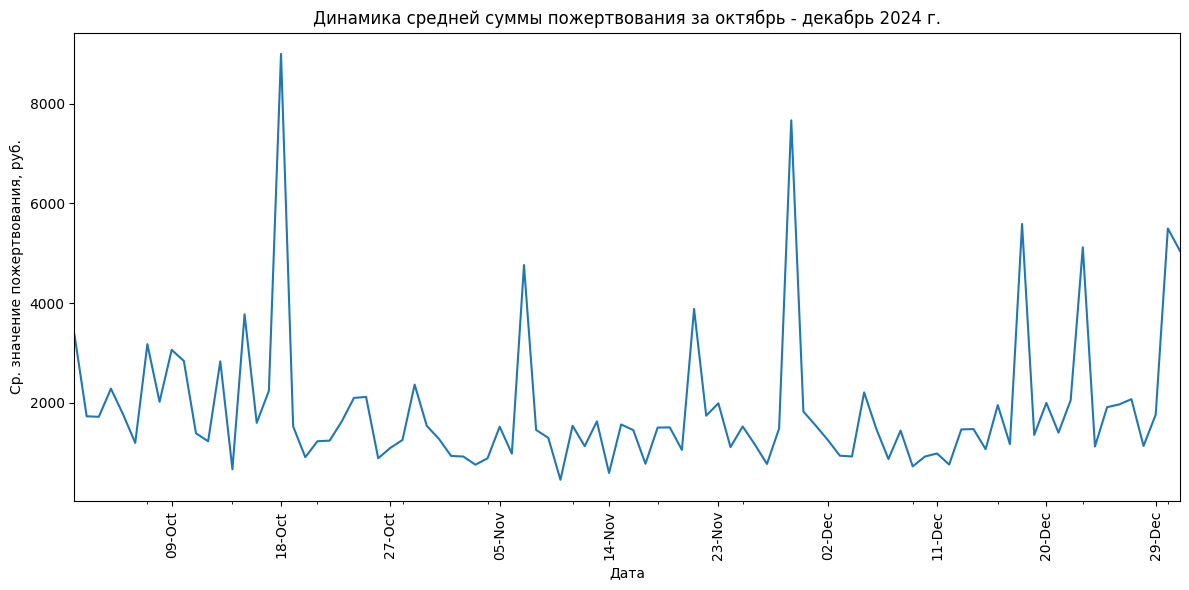

In [73]:
ax = (
    data_2022_2024_filtered[data_2022_2024_filtered['payment_date'].between('2024-10-01', '2024-12-31')]
    .query('received_sum < 200000')
    .groupby(data_2022_2024_filtered['payment_date'])['received_sum'].mean()
    .plot(figsize=(12, 6), grid=False)
)
ax.xaxis.set_major_locator(DayLocator(interval=9))
ax.xaxis.set_major_formatter(DateFormatter('%d-%b'))
ax.tick_params(axis='x', labelrotation= 90)
plt.title('Динамика средней суммы пожертвования за октябрь - декабрь 2024 г.')
plt.ylabel('Ср. значение пожертвования, руб.')
plt.xlabel('Дата')
plt.tight_layout()
plt.show();

Подробнее остановится на периодах с 14 по 20 октября и с 28 ноября по 31 декабря 2024 г.

Сначала рассмотрим данные с 14 по 20 октября 2024 г.

In [74]:
(
    data_2022_2024_filtered[data_2022_2024_filtered['payment_date'].between('2024-10-14', '2024-10-20')]
    .query('received_sum < 200000')
    .sort_values(by='received_sum', ascending=False)
    .head(20)
)

,id,user_id,company_id,user_gender,country,region,city,payment_date,payment_id,received_sum,comment,transaction_type,event_code,event_name
36215,397925,343553,<NA>,NaN,Россия,Москва,Москва,2024-10-18,cloud:2141439126,150000.00,"Разовое пожертвование ""Добрый юбилей """,Пожертвование разовое,f215,th
41771,397361,344275,<NA>,NaN,Россия,NaN,NaN,2024-10-15,cloud:2140970069,30000.00,"Разовое пожертвование в БФ ""Синдром любви""",Пожертвование разовое,f209,NaN
38167,397663,341845,<NA>,NaN,Россия,Москва,Москва,2024-10-17,cloud:2141279906,25000.00,"Разовое пожертвование ""Добрый юбилей """,Пожертвование разовое,f215,th
35789,397787,491345,<NA>,NaN,NaN,NaN,Москва,2024-10-18,cloud:2141350700,25000.00,"Разовое пожертвование ""Добрый юбилей """,Пожертвование разовое,f215,th
35745,397343,492153,<NA>,Ж,NaN,NaN,Москва,2024-10-15,cloud:2140937671,20000.00,"Разовое пожертвование ""Благотворительный вечер в поддержку людей с синдромом Дауна""",Пожертвование разовое,f208,blagotvoritelnyy-kontsert-merabova
38160,397613,466811,<NA>,Ж,NaN,NaN,Москва,2024-10-17,cloud:2141252686,20000.00,"Разовое пожертвование ""Добрый юбилей """,Пожертвование разовое,f215,th
41847,397889,349189,<NA>,NaN,Россия,NaN,NaN,2024-10-18,cloud:2141398132,20000.00,"Разовое пожертвование ""Добрый юбилей """,Пожертвование разовое,f215,th
35772,397625,492209,<NA>,Ж,NaN,NaN,Москва,2024-10-17,cloud:2141261378,10000.00,"Разовое пожертвование ""Добрый юбилей """,Пожертвование разовое,f215,th
38144,397449,465625,<NA>,Ж,NaN,NaN,Ярославль,2024-10-16,cloud:2141072379,10000.00,"Ежемесячное пожертвование в БФ ""Синдром любви""",Пожертвование рекуррент,f112,NaN
41770,397355,401427,<NA>,NaN,Россия,Москва,Москва,2024-10-15,cloud:2140957451,10000.00,"Разовое пожертвование ""Благотворительный вечер в поддержку людей с синдромом Дауна""",Пожертвование разовое,f208,blagotvoritelnyy-kontsert-merabova


Полученный срез данных говорит о том, что **15 октября 2024 г. проходил `Благотворительный вечер в поддержку людей с синдромом Дауна` с участием Мариам Мерабовы (код в столбце `event_name` - `blagotvoritelnyy-kontsert-merabova`, код мероприятия `f208 (мероприятия ВИД, концерт)`), в рамках которого благотворительный фонд получил несколько разовых пожертвований в размере от 10 до 20 тыс. руб.**

Также за указанный период **было получено несколько разовых пожертвование в размере от 10 до 150 тыс. руб. в рамках акции `Добрый юбилей` (код в столбце `event_name` - `th`, код мероприятия `f215 (Пожертвования через СМС и спец ссылки)`)**.

Далее рассмотрим данные с 28 ноября по 31 декабря 2024 г.

In [75]:
(
    data_2022_2024_filtered[data_2022_2024_filtered['payment_date'].between('2024-11-28', '2024-12-31')]
    .query('received_sum < 200000')
    .sort_values(by='received_sum', ascending=False)
    .head(20)
)

,id,user_id,company_id,user_gender,country,region,city,payment_date,payment_id,received_sum,comment,transaction_type,event_code,event_name
36177,404687,349833,<NA>,NaN,Россия,NaN,NaN,2024-12-18,cloud:2618190984,100000.00,"Разовое пожертвование в рамках акции «Новогодний подарок!», 100000",Пожертвование разовое,f215,elki2025
40105,402319,492505,<NA>,Ж,NaN,NaN,NaN,2024-11-29,NaN,100000.00,NaN,Пожертвование разовое,f209,NaN
36168,406431,464767,<NA>,М,NaN,NaN,Москва,2024-12-30,cloud:2633583344,100000.00,"Разовое пожертвование в БФ ""Синдром любви""",Пожертвование разовое,f111,EN_18.12.2024
36377,405331,494369,<NA>,Ж,NaN,NaN,Москва,2024-12-23,cloud:2624619557,82000.00,"[p]Разовое пожертвование в БФ ""Синдром любви"" [/p]",Пожертвование разовое,f215,NaN
36174,405067,492357,<NA>,NaN,NaN,NaN,Москва,2024-12-20,cloud:2620973023,50000.00,"Разовое пожертвование в БФ ""Синдром любви""",Пожертвование разовое,f209,NaN
36163,406595,412895,<NA>,NaN,Россия,Москва,Москва,2024-12-31,cloud:2635490709,50000.00,"Разовое пожертвование в БФ ""Синдром любви""",Пожертвование разовое,f114,MA_PVL
38521,404089,481329,<NA>,М,NaN,NaN,Москва,2024-12-16,cloud:2614875366,30000.00,"Разовое пожертвование в БФ ""Синдром любви""",Пожертвование разовое,f111,EN_12.12.2024
40245,406143,494553,<NA>,NaN,NaN,NaN,NaN,2024-12-27,cloud:2630179459,29000.00,Заказ №141766 от 27.12.2024,Продажа,f517,action
40244,404945,494195,<NA>,NaN,NaN,NaN,NaN,2024-12-20,cloud:2620655108,29000.00,Заказ №141081 от 20.12.2024,Продажа,f517,action
35975,405753,494493,<NA>,М,NaN,NaN,Франкфурт-на-Майне,2024-12-26,cloud:2628170483,25000.00,"Разовое пожертвование в БФ ""Синдром любви""",Пожертвование разовое,f209,NaN


Полученный срез данных говорит о том, что **в период с 28 ноября по 31 декабря было получено множество крупных пожертвований в рамках нескольких акций - `TM_dinamo_14.12.2024` и `TM_gymnasium_fair` (код мероприятия `f216 (Телемаркетинг)`) в размере от 10,6 до 23 тыс. руб., а также `Новогодний подарок!` (код в столбце `event_name` - `elki2025`, код мероприятия `f215 (Пожертвования через СМС и спец ссылки)`) в размере 14 и 100 тыс. руб.**

##### Выводы по анализу динамики средней суммы пожертвования за рассматриваемый период

На основании проанализированной динамики средней суммы пожертвования за рассматриваемый период можно сделать следующие выводы:
- наибольшие суммы пожертвований благотворительный фонд получает в рамках благотворительных концертов и вечеров, предновогодних акций `Новогодний подарок!` (`elki`), а также личных контактов сотрудников фонда с ВИДами (код мероприятия `f114 (ВИД массовые акции)`);
- большой объем пожертвований был получен в рамках акции `Юбилей Бориса Синегубко` - от 20 до 150 тыс. руб., а также `Устрицы 2023` и `Устрицы 2024` - наибольший платеж в данном случае составил более 100 тыс. руб.;
- наибольшие суммы пожертвований, имеют коды `f208 (мероприятия ВИД, концерт)`, `f209 (ВИД пожертвования)` и `f215 (Пожертвования через СМС и спец ссылки)`, помимо кода `f114`, который был упомянут выше, что говорит о том, что организация концертов и иных массовых мероприятий позволяет привлечь как минимум крупные разовые пожертвования;
- большинство крупных пожертвований являются разовыми, при этом их величина может в десятки раз превышать среднее значение - 100 тыс. руб. против 2-5 тыс., в связи с чем представленные диаграммы динамики средней суммы пожертвования имеют большое количество выделяющихся пиков.

#### Динамика количества пожертвований за рассматриваемый период

Проанализируем динамику количества пожертвований клиентов (жертвователей). Для этого построим линейную диаграмму в разрезе рассматриваемых периодов (2022, 2023, 2024 гг.) по месяцам при помощи метода `plot()`, убрав из датасета пожертвования больше 200 тыс. руб.

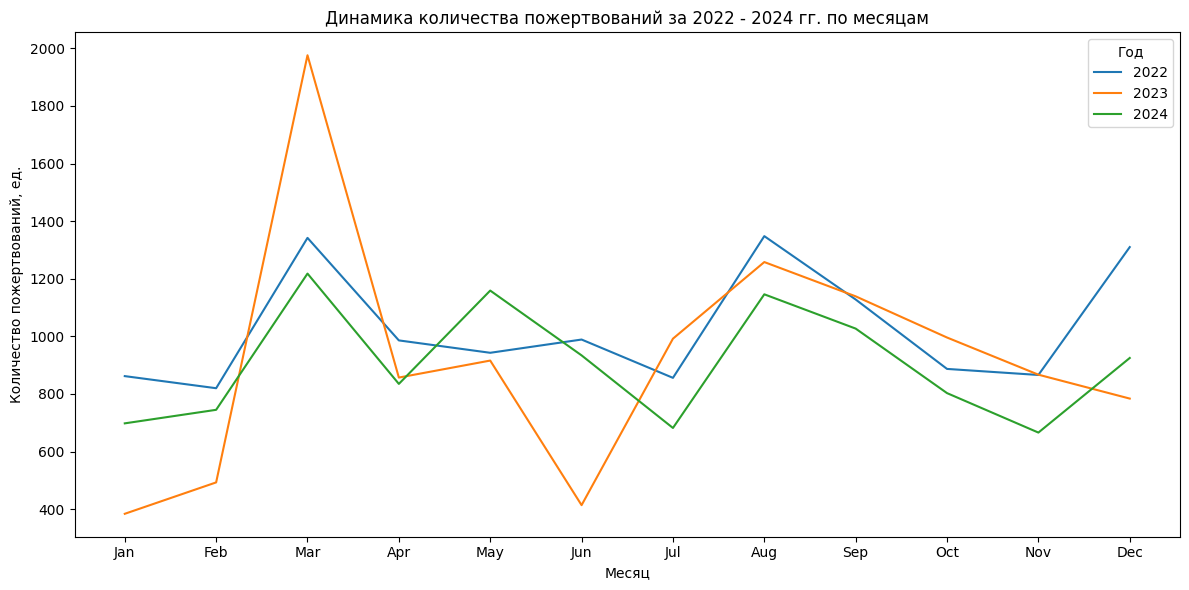

In [76]:
ax = (
    data_2022_2024_filtered
    .query('received_sum < 200000')
    .pivot_table(index=data_2022_2024_filtered['payment_date'].dt.month,
                 columns=data_2022_2024_filtered['payment_date'].dt.year,
                 values='received_sum',
                 aggfunc='count')
    .plot(figsize=(12, 6), grid=False)
)
plt.xticks(ticks=np.arange(1, 13, step=1), labels=['Jan', 'Feb', 'Mar', 'Apr', 'May', 'Jun', 'Jul', 'Aug', 'Sep', 'Oct', 'Nov', 'Dec'])
plt.title('Динамика количества пожертвований за 2022 - 2024 гг. по месяцам')
plt.ylabel('Количество пожертвований, ед.')
plt.xlabel('Месяц')
plt.legend(title='Год')
plt.tight_layout()
plt.show();

Представленная линейная диаграмма говорит о том, что рост количества пожертвований зафиксирован в:
- в марте, августе и декабре 2022 и 2024 гг.;
- в феврале - апреле и августе 2023 г.;
- в мае 2024 г.

Так как данные в данном случае представлены по месяцам, затруднительно точно определить периоды, в которых был зафиксирован рост количества пожертвований. Повторно построим линейный график, но уже в разрезе дат, для уточнения указанных периодов.

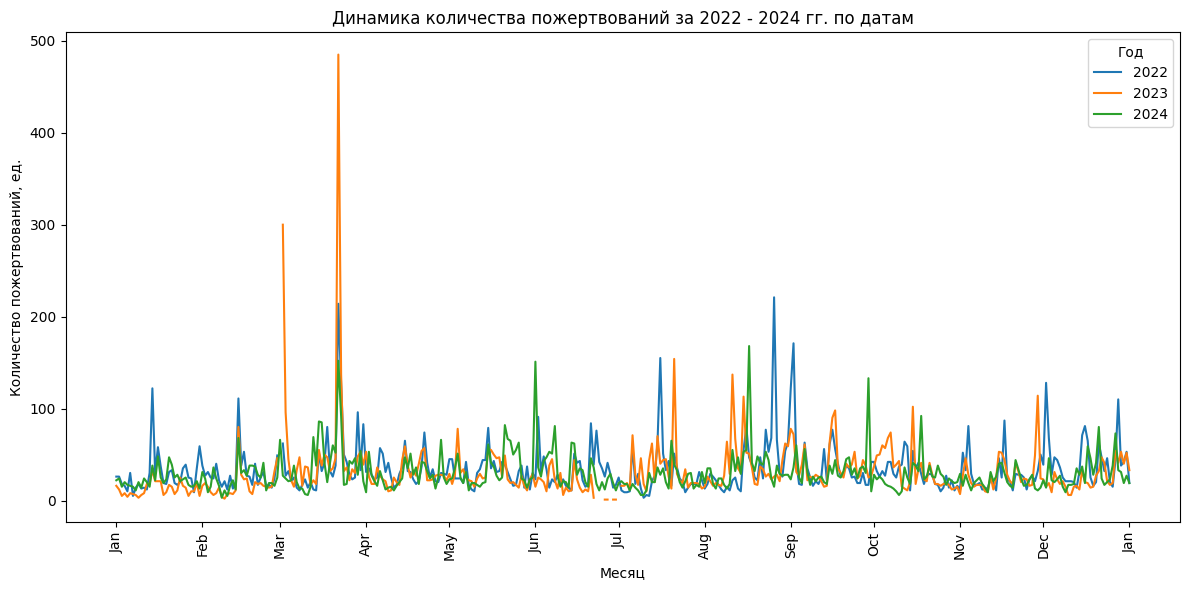

In [77]:
ax = (
    data_2022_2024_filtered
    .query('received_sum < 200000')
    .pivot_table(index=data_2022_2024_filtered['payment_date'].dt.strftime('%m-%d'),
                 columns=data_2022_2024_filtered['payment_date'].dt.year,
                 values='received_sum',
                 aggfunc='count')
    .plot(figsize=(12, 6), grid=False)
)
ax.xaxis.set_major_locator(MonthLocator())
ax.xaxis.set_major_formatter(DateFormatter("%b"))
plt.xticks(rotation='vertical')
plt.title('Динамика количества пожертвований за 2022 - 2024 гг. по датам')
plt.ylabel('Количество пожертвований, ед.')
plt.xlabel('Месяц')
plt.legend(title='Год')
plt.tight_layout()
plt.show();

Представленная линейная диаграмма говорит о том, что наибольшее количество пожертвований зафиксировано в:
- середине марта и в июле - сентябре 2022 г.;
- конце февраля - конце марта и в июле - августе 2023 г.;
- середине марта, в начале июня - конце сентября 2024 г.

Рассмотрим динамику количества пожертвований в разрезе периодов, указанных выше.

##### Динамика количества пожертвований в 2022 г.

В первую очередь рассмотрим 2022 г., а именно период с марта по сентябрь.

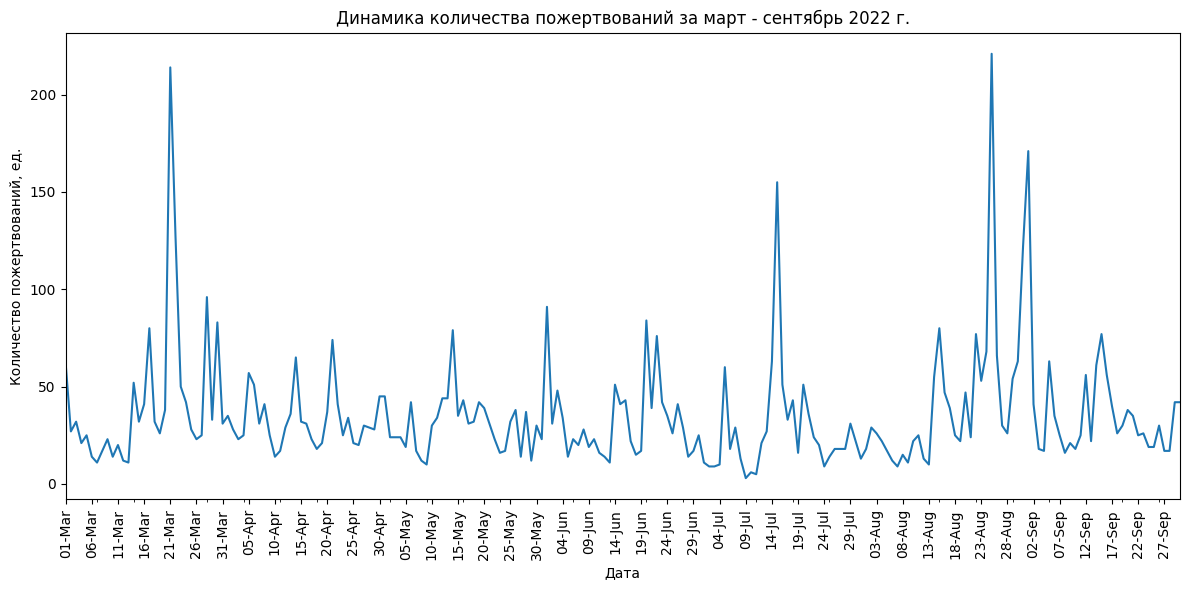

In [78]:
ax = (
    data_2022_2024_filtered[data_2022_2024_filtered['payment_date'].between('2022-03-01', '2022-09-30')]
    .query('received_sum < 200000')
    .groupby(data_2022_2024_filtered['payment_date'])['received_sum'].count()
    .plot(figsize=(12, 6), grid=False)
)
ax.xaxis.set_major_locator(DayLocator(interval=5))
ax.xaxis.set_major_formatter(DateFormatter('%d-%b'))
ax.tick_params(axis='x', labelrotation= 90)
plt.title('Динамика количества пожертвований за март - сентябрь 2022 г.')
plt.ylabel('Количество пожертвований, ед.')
plt.xlabel('Дата')
plt.tight_layout()
plt.show();

Сформированная линейная диаграмма говорит о том, что наибольшее количество пожертвований зафиксировано в период 16 - 25 марта, 11 - 18 июля и 20 августа - 3 сентября 2022 г. При помощи среза данных методом `query()` и группировки данных методом `pivot_table()` с применением агрегирующей функции `size` и сортировки значений методом `sort_values()` поочередно просмотрим данные за указанные периоды.

В первую очередь проверим, в какие даты пришло большинство пожертвований за 16 - 25 марта 2022 г.

In [79]:
(
    data_2022_2024_filtered[data_2022_2024_filtered['payment_date'].between('2022-03-16', '2022-03-25')]
    .query('received_sum < 200000')
    ['payment_date'].value_counts()
)

payment_date
2022-03-21    214
2022-03-22    127
2022-03-17     80
2022-03-23     50
2022-03-24     42
2022-03-16     41
2022-03-20     38
2022-03-18     32
2022-03-25     28
2022-03-19     26
Name: count, dtype: int64

Согласно подсчитанным уникальным значениям, большинство пожертвований за рассматриваемый период было получено 21 и 22 марта 2022 г. Сделаем срез данных по указанным датам и проверим, какие мероприятия проводились в данные дни, с указанием кода мероприятия и типа пожертвования, подсчитав количество уникальных значений по столбцам `event_name`, `event_code` и `transaction_type`.

In [80]:
(
    data_2022_2024_filtered[data_2022_2024_filtered['payment_date'].between('2022-03-21', '2022-03-22')]
    .query('received_sum < 200000')
    .pivot_table(index=['event_name', 'event_code', 'transaction_type'], aggfunc='size')
    .sort_values(ascending=False)
)

event_name                                        event_code  transaction_type                
orange2022                                        f405        Пожертвование разовое               124
Гошля Анастасия                                   f207        Пожертвование разовое                52
EN_210322                                         f211        Пожертвование разовое                25
6-y-blagotvoritelnyy-zabeg-dobryy-gryaznyy-treyl  f204        Взнос                                14
MA_LK                                             f215        Пожертвование разовое                14
orange2022                                        f215        Пожертвование разовое                13
MA_LK                                             f405        Пожертвование разовое                12
MA_Andryusha                                      f215        Пожертвование разовое                 6
EN_continue                                       f211        Пожертвование разовое      

Полученные данные говорят о том, что **за 21 - 22 марта 2022 г. большое количество пожертвований было получено в рамках акций `orange2022`, `Гошля Анастасия`, `EN_210322` и `6-y-blagotvoritelnyy-zabeg-dobryy-gryaznyy-treyl` (коды мероприятий `f405 (Социальный маркетинг, пожертвования сотрудников (кроме АВБ))`, `f207 (АВБ)`, `f211 (Частные доноры Рассылки)`, `f215 (пожертвования через СМС и спец ссылки)`,  и `f204 (СВБ инд. учстники пробег и  рейл)`), на основании чего можно сделать вывод о том, что клиентов (жертвователей) привлекают рассылки (акции, начинающиеся с `EN`), спортивные мероприятия и корпоративные акции внутри компаний.** При этом почти все пожертвования разовые.

Кроме того, **часть пожертвований 21 - 22 марта 2022 г. была получена в рамках рассылки клиентам (жертвователям) - код мероприятия `f211 (Частные доноры Рассылки)`, что говорит о том, что с высокой вероятностью в эти дни клиентам (жертвователям) приходили соответствующие сообщения на электронную почту или по иным каналам связи, в связи с чем количество пожертвований было больше по сравнению с другими днями месяца**.

Теперь рассмотрим в какие даты пришло большинство пожертвований за 11 - 18 июля 2022 г.

In [81]:
(
    data_2022_2024_filtered[data_2022_2024_filtered['payment_date'].between('2022-07-11', '2022-07-18')]
    .query('received_sum < 200000')
    ['payment_date'].value_counts()
)

payment_date
2022-07-15    155
2022-07-14     63
2022-07-16     51
2022-07-18     43
2022-07-17     33
2022-07-13     27
2022-07-12     21
2022-07-11      5
Name: count, dtype: int64

Согласно подсчитанным уникальным значениям, большинство пожертвований за рассматриваемый период было получено с 14 по 18 марта 2022 г. Сделаем срез данных по указанным датам и проверим, какие мероприятия проводились в данные дни, с указанием кода мероприятия и типа пожертвования.

In [82]:
(
    data_2022_2024_filtered[data_2022_2024_filtered['payment_date'].between('2022-07-14', '2022-07-18')]
    .query('received_sum < 200000')
    .pivot_table(index=['event_name', 'event_code', 'transaction_type'], aggfunc='size')
    .sort_values(ascending=False)
)

event_name       event_code  transaction_type                
EN_needs22       f211        Пожертвование разовое               129
Бегом за добром  f207        Пожертвование разовое                32
th               f215        Пожертвование разовое                10
Оханская Юлия    f207        Пожертвование разовое                 9
orange2022       f215        Пожертвование разовое                 8
Додонов Артём    f207        Пожертвование разовое                 8
EN_needs22       f111        Пожертвование разовое                 4
Дудко Елена      f207        Пожертвование разовое                 4
EN_needs22       f211        Пожертвование рекуррент (первое)      3
Иванова Надежда  f207        Пожертвование разовое                 2
EN_01.07.22      f211        Пожертвование разовое                 1
EN_spasibo       f211        Пожертвование разовое                 1
dtype: int64

Полученные данные говорят о том, что **за 14 - 18 июля 2022 г. большое количество пожертвований было получено в рамках акции `EN_needs22` (коды мероприятия `f211 (Частные доноры Рассылки)` и `f111 (ВИД Рассылки)`) и `Бегом за добром` (код мероприятия `f207 (АВБ)`), которая относится к рассылкам и спортивным мероприятиям**. При этом почти все пожертвования разовые. 

Наконец рассмотрим в какие даты пришло большинство пожертвований за 20 августа - 3 сентября 2022 г.

In [83]:
(
    data_2022_2024_filtered[data_2022_2024_filtered['payment_date'].between('2022-08-20', '2022-09-03')]
    .query('received_sum < 200000')
    ['payment_date'].value_counts()
)

payment_date
2022-08-25    221
2022-09-01    171
2022-08-31    122
2022-08-22     77
2022-08-24     68
2022-08-26     66
2022-08-30     63
2022-08-29     54
2022-08-23     53
2022-08-20     47
2022-09-02     41
2022-08-27     30
2022-08-28     26
2022-08-21     24
2022-09-03     18
Name: count, dtype: int64

Согласно подсчитанным уникальным значениям, большинство пожертвований за рассматриваемый период было получено с 25 августа по 1 сентября 2022 г. Сделаем срез данных по указанным датам и проверим, какие мероприятия проводились в данные дни, с указанием кода мероприятия и типа пожертвования.

In [84]:
(
    data_2022_2024_filtered[data_2022_2024_filtered['payment_date'].between('2022-08-25', '2022-09-01')]
    .query('received_sum < 200000')
    .pivot_table(index=['event_name', 'event_code', 'transaction_type'], aggfunc='size')
    .sort_values(ascending=False)
)

event_name                                                          event_code  transaction_type                
maple2022                                                           f405        Пожертвование разовое               454
osenniy-blagotvoritelnyy-zabeg-sport-vo-blago                       f204        Взнос                                71
maple2022                                                           f215        Пожертвование разовое                39
Дудко Елена                                                         f207        Пожертвование разовое                10
IRONSTAR SPRINT SOCHI СИРИУС 2022                                   f207        Пожертвование разовое                10
Кучальская Анна                                                     f207        Пожертвование разовое                10
Чуркин Ярослав                                                      f207        Пожертвование разовое                 5
Гошля Анастасия                                

Полученные данные говорят о том, что **за 25 августа - 1 сентября 2022 г. большое количество пожертвований было получено в рамках акций `maple2022` (коды мероприятия `f405 (Социальный маркетинг, пожертвования сотрудников (кроме АВБ))` и `f215 (Пожертвования через СМС и спец ссылки)`) и `osenniy-blagotvoritelnyy-zabeg-sport-vo-blago` (код мероприятия `f204 (СВБ инд. учстники пробег и  рейл)`), которые относятся к корпоративным и онлайн-акциям, а также и спортивным мероприятиям**. При этом почти все пожертвования разовые.

##### Динамика количества пожертвований в 2023 г.

Рассмотрим данные за 2023 г., с февраля по август.

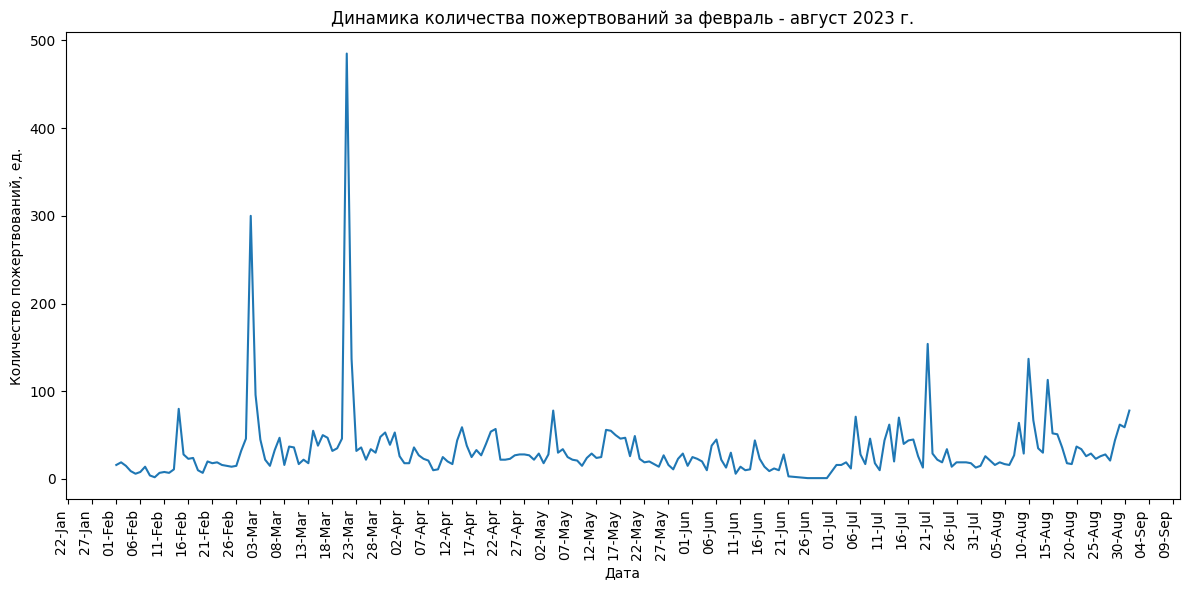

In [85]:
ax = (
    data_2022_2024_filtered[data_2022_2024_filtered['payment_date'].between('2023-02-01', '2023-08-31')]
    .query('received_sum < 200000')
    .groupby(data_2022_2024_filtered['payment_date'])['received_sum'].count()
    .plot(figsize=(12, 6), grid=False)
)
ax.xaxis.set_major_locator(DayLocator(interval=5))
ax.xaxis.set_major_formatter(DateFormatter('%d-%b'))
ax.tick_params(axis='x', labelrotation= 90)
plt.title('Динамика количества пожертвований за февраль - август 2023 г.')
plt.ylabel('Количество пожертвований, ед.')
plt.xlabel('Дата')
plt.tight_layout()
plt.show();

Сформированная линейная диаграмма говорит о том, что наибольшее количество пожертвований зафиксировано в период 28 февраля - 5 марта, 20 - 23 марта, 18 - 22 июля и 8 - 15 августа 2023 г. При помощи среза данных методом `query()` и группировки данных методом `pivot_table()` с применением агрегирующей функции `size` и сортировки значений методом `sort_values()` поочередно просмотрим данные за указанные периоды.

В первую очередь проверим, в какие даты пришло большинство пожертвований за 28 февраля - 5 марта 2023 г.

In [86]:
(
    data_2022_2024_filtered[data_2022_2024_filtered['payment_date'].between('2023-02-28', '2023-03-05')]
    .query('received_sum < 200000')
    ['payment_date'].value_counts()
)

payment_date
2023-03-01    300
2023-03-02     96
2023-02-28     46
2023-03-03     45
2023-03-04     22
2023-03-05     15
Name: count, dtype: int64

Согласно подсчитанным уникальным значениям, большинство пожертвований за рассматриваемый период было получено с 28 февраля по 3 марта 2023 г. Сделаем срез данных по указанным датам и проверим, какие мероприятия проводились в данные дни, с указанием кода мероприятия и типа пожертвования.

In [87]:
(
    data_2022_2024_filtered[data_2022_2024_filtered['payment_date'].between('2023-02-28', '2023-03-03')]
    .query('received_sum < 200000')
    .pivot_table(index=['event_name', 'event_code', 'transaction_type'], aggfunc='size')
    .sort_values(ascending=False)
)

event_name                event_code  transaction_type     
orange2023                f405        Пожертвование разовое    242
                          f215        Пожертвование разовое     69
Кучальская Анна           f207        Взнос                     27
action                    f517        Продажа                    8
Дудко Елена               f207        Взнос                      8
Cycling-марафон-2022-11-  f201        Взнос                      2
ДОРОГА ЖИЗНИ              f207        Взнос                      1
Дмитриев Павел            f207        Взнос                      1
Дудко Елена               f207        Пожертвование разовое      1
Севальнева Наталья        f207        Взнос                      1
Шахарова Ольга            f207        Взнос                      1
dtype: int64

Полученные данные говорят о том, что **за 28 февраля - 3 марта 2023 г. большое количество пожертвований было получено в рамках акций `orange2023` (коды мероприятия `f405 (Социальный маркетинг, пожертвования сотрудников (кроме АВБ))` и `f215 (Пожертвования через СМС и спец ссылки)`) и `Кучальская Анна` (код мероприятия `f207 (АВБ)`), которые относятся к корпоративным и онлайн-акциям, а также спортивным мероприятиям**. В данном случае пожертвования относятся как к разовым, так и к взносам.

Далее рассмотрим в какие даты пришло большинство пожертвований за  20 - 23 марта 2023 г.

In [88]:
(
    data_2022_2024_filtered[data_2022_2024_filtered['payment_date'].between('2023-03-20', '2023-03-23')]
    .query('received_sum < 200000')
    ['payment_date'].value_counts()
)

payment_date
2023-03-21    485
2023-03-22    137
2023-03-20     46
2023-03-23     32
Name: count, dtype: int64

Согласно подсчитанным уникальным значениям, большинство пожертвований за рассматриваемый период было получено с 21 по 22 марта 2023 г. Сделаем срез данных по указанным датам и проверим, какие мероприятия проводились в данные дни, с указанием кода мероприятия и типа пожертвования.

In [89]:
(
    data_2022_2024_filtered[data_2022_2024_filtered['payment_date'].between('2023-03-21', '2023-03-22')]
    .query('received_sum < 200000')
    .pivot_table(index=['event_name', 'event_code', 'transaction_type'], aggfunc='size')
    .sort_values(ascending=False)
)

event_name             event_code  transaction_type                
orange2023             f405        Пожертвование разовое               339
                       f215        Пожертвование разовое                77
th                     f215        Пожертвование разовое                17
5 вёрст во благо       f207        Взнос                                12
MA_topstretching_2023  f215        Пожертвование разовое                 8
MA_PRT                 f215        Пожертвование разовое                 8
                       f114        Пожертвование разовое                 6
EN_210323              f211        Пожертвование разовое                 5
MA_LVR                 f215        Пожертвование разовое                 2
MA_VSL                 f114        Пожертвование разовое                 2
Marsi Дарья            f207        Взнос                                 2
Ковалева Евгения       f207        Взнос                                 2
MA_LVR                 f114     

Полученные данные говорят о том, что **за 21 - 22 марта 2023 г. большое количество пожертвований было получено в рамках акции `orange2023` (коды мероприятия `f405 (Социальный маркетинг, пожертвования сотрудников (кроме АВБ))` и `f215 (Пожертвования через СМС и спец ссылки)`), которая относится к корпоративным и онлайн-акциям**. При этом почти все пожертвования разовые.

Теперь рассмотрим в какие даты пришло большинство пожертвований за 18 - 22 июля 2023 г.

In [90]:
(
    data_2022_2024_filtered[data_2022_2024_filtered['payment_date'].between('2023-07-18', '2023-07-22')]
    .query('received_sum < 200000')
    ['payment_date'].value_counts()
)

payment_date
2023-07-20    154
2023-07-21     29
2023-07-18     26
2023-07-22     22
2023-07-19     13
Name: count, dtype: int64

Согласно подсчитанным уникальным значениям, большинство пожертвований за рассматриваемый период было получено с 20 по 21 июля 2023 г. Сделаем срез данных по указанным датам и проверим, какие мероприятия проводились в данные дни, с указанием кода мероприятия и типа пожертвования.

In [91]:
(
    data_2022_2024_filtered[data_2022_2024_filtered['payment_date'].between('2023-07-20', '2023-07-21')]
    .query('received_sum < 200000')
    .pivot_table(index=['event_name', 'event_code', 'transaction_type'], aggfunc='size')
    .sort_values(ascending=False)
)

event_name                                                event_code  transaction_type                
EN_needs7.23                                              f211        Пожертвование разовое               116
                                                          f111        Пожертвование разовое                 4
                                                          f212        Пожертвование рекуррент (первое)      4
action                                                    f517        Продажа                               3
vesenni-blagotvoritelnyy-zabeg-sport-vo-blago-14-10-2023  f204        Взнос                                 2
th                                                        f215        Пожертвование разовое                 1
Соловьёва Екатерина                                       f207        Пожертвование разовое                 1
Ультра Mari                                               f207        Пожертвование разовое                 1
dtype: int64

Полученные данные говорят о том, что **за 20 - 21 июля 2023 г. большое количество пожертвований было получено в рамках акции `EN_needs7.23` (коды мероприятия `f211 (Частные доноры Рассылки)`, `f111 (ВИД Рассылки)` и `f212 (Частные доноры Регулярные пожертвования)`), которая относится к рассылкам, что подтверждает ранее высказанное предположение о том, что 21 числа каждого месяца происходит рассылка сообщений через сайт в адрес клиентов (жертвователей), в связи с чем число платежей в такие дни возрастает.**. При этом почти все пожертвования разовые.

Наконец рассмотрим в какие даты пришло большинство пожертвований за 8 - 15 августа 2023 г.

In [92]:
(
    data_2022_2024_filtered[data_2022_2024_filtered['payment_date'].between('2023-08-08', '2023-08-15')]
    .query('received_sum < 200000')
    ['payment_date'].value_counts()
)

payment_date
2023-08-10    137
2023-08-14    113
2023-08-11     67
2023-08-08     64
2023-08-15     52
2023-08-12     35
2023-08-13     30
2023-08-09     29
Name: count, dtype: int64

Согласно подсчитанным уникальным значениям, большое количество пожертвований получено за весь рассматриваемый период. Сделаем срез данных по указанным датам и проверим, какие мероприятия проводились в данные дни, с указанием кода мероприятия и типа пожертвования.

In [93]:
(
    data_2022_2024_filtered[data_2022_2024_filtered['payment_date'].between('2023-08-08', '2023-08-15')]
    .query('received_sum < 200000')
    .pivot_table(index=['event_name', 'event_code', 'transaction_type'], aggfunc='size')
    .sort_values(ascending=False)
)

event_name                                                event_code  transaction_type                
maple2023                                                 f405        Пожертвование разовое               208
                                                          f215        Пожертвование разовое                78
vesenni-blagotvoritelnyy-zabeg-sport-vo-blago-14-10-2023  f204        Взнос                                22
MAY Grit                                                  f207        Пожертвование разовое                17
EN_report0723                                             f211        Пожертвование разовое                 8
action                                                    f517        Продажа                               8
EN_needs7.23                                              f211        Пожертвование разовое                 6
maple2023                                                 f405        Пожертвование рекуррент (первое)      5
Галкин Илья      

Полученные данные говорят о том, что **за 8 - 15 августа 2023 г. большое количество пожертвований было получено в рамках акции `maple2023` (коды мероприятия `f405 (Социальный маркетинг, пожертвования сотрудников (кроме АВБ))` и `f215 (Пожертвования через СМС и спец ссылки)`), которая относится к корпоративным и онлайн-акциям**. При этом почти все пожертвования разовые.

##### Динамика количества пожертвований в 2024 г.

Рассмотрим данные за 2024 г., с марта по сентябрь.

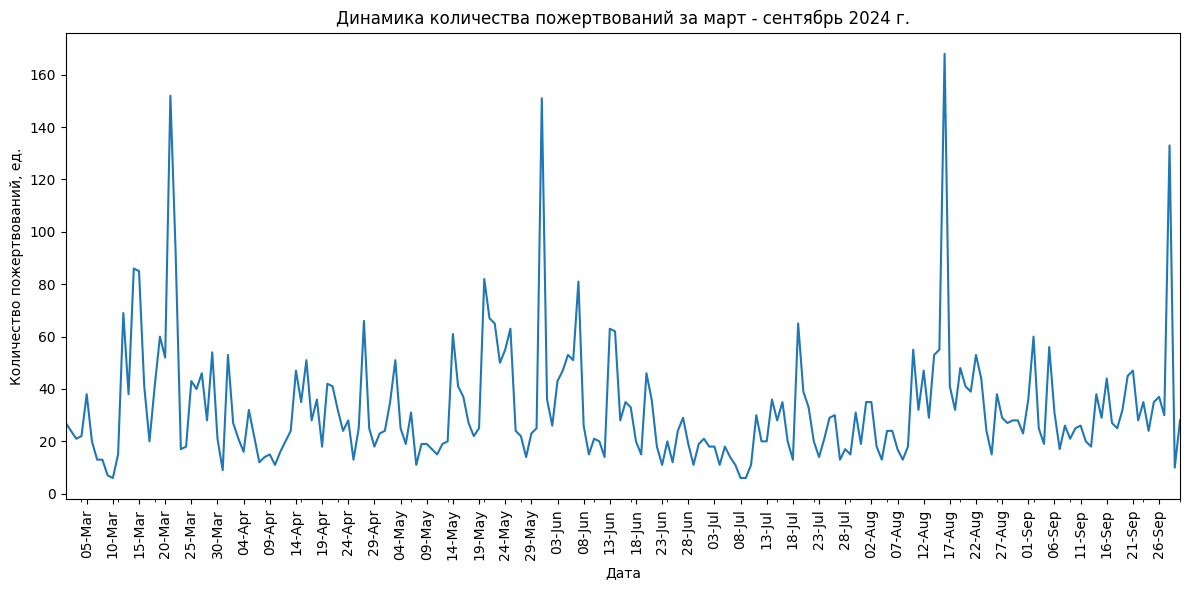

In [94]:
ax = (
    data_2022_2024_filtered[data_2022_2024_filtered['payment_date'].between('2024-03-01', '2024-09-30')]
    .query('received_sum < 200000')
    .groupby(data_2022_2024_filtered['payment_date'])['received_sum'].count()
    .plot(figsize=(12, 6), grid=False)
)
ax.xaxis.set_major_locator(DayLocator(interval=5))
ax.xaxis.set_major_formatter(DateFormatter('%d-%b'))
ax.tick_params(axis='x', labelrotation= 90)
plt.title('Динамика количества пожертвований за март - сентябрь 2024 г.')
plt.ylabel('Количество пожертвований, ед.')
plt.xlabel('Дата')
plt.tight_layout()
plt.show();

Сформированная линейная диаграмма говорит о том, что наибольшее количество пожертвований зафиксировано в период 16 - 24 марта, 28 мая - 3 июня, 13 - 19 августа и 26 - 30 сентября 2024 г. При помощи среза данных методом `query()` и группировки данных методом `pivot_table()` с применением агрегирующей функции `size` и сортировки значений методом `sort_values()` поочередно просмотрим данные за указанные периоды.

В первую очередь проверим, в какие даты пришло большинство пожертвований за 16 - 24 марта 2024 г.

In [95]:
(
    data_2022_2024_filtered[data_2022_2024_filtered['payment_date'].between('2024-03-16', '2024-03-24')]
    .query('received_sum < 200000')
    ['payment_date'].value_counts()
)

payment_date
2024-03-21    152
2024-03-22     92
2024-03-19     60
2024-03-20     52
2024-03-16     41
2024-03-18     41
2024-03-17     20
2024-03-24     18
2024-03-23     17
Name: count, dtype: int64

Согласно подсчитанным уникальным значениям, большинство пожертвований за рассматриваемый период было получено с 19 по 22 марта 2024 г. Сделаем срез данных по указанным датам и проверим, какие мероприятия проводились в данные дни, с указанием кода мероприятия и типа пожертвования.

In [96]:
(
    data_2022_2024_filtered[data_2022_2024_filtered['payment_date'].between('2024-03-19', '2024-03-22')]
    .query('received_sum < 200000')
    .pivot_table(index=['event_name', 'event_code', 'transaction_type'], aggfunc='size')
    .sort_values(ascending=False)
)

event_name                                         event_code  transaction_type                
jam2024                                            f405        Пожертвование разовое               135
                                                   f215        Пожертвование разовое                60
uzhin-2024                                         f208        Пожертвование разовое                14
MA_march                                           f114        Пожертвование разовое                13
EN_vychet                                          f211        Пожертвование разовое                 5
VID_Uzhin_Forum                                    f208        Пожертвование разовое                 3
action                                             f517        Продажа                               2
Эстафета добра                                     f207        Пожертвование разовое                 2
VID_Noodome_2103                                   f208        Пожертвование раз

Полученные данные говорят о том, что **за 19 - 22 марта 2024 г. большое количество пожертвований было получено в рамках акции `jam2024` (коды мероприятия `f405 (Социальный маркетинг, пожертвования сотрудников (кроме АВБ))` и `f215 (Пожертвования через СМС и спец ссылки)`), которая относится к корпоративным и онлайн-акциям**. При этом почти все пожертвования разовые.

Далее рассмотрим в какие даты пришло большинство пожертвований за  28 мая - 3 июня 2024 г.

In [97]:
(
    data_2022_2024_filtered[data_2022_2024_filtered['payment_date'].between('2024-05-28', '2024-06-03')]
    .query('received_sum < 200000')
    ['payment_date'].value_counts()
)

payment_date
2024-05-31    151
2024-06-03     43
2024-06-01     36
2024-06-02     26
2024-05-30     25
2024-05-29     23
2024-05-28     14
Name: count, dtype: int64

Согласно подсчитанным уникальным значениям, большинство пожертвований за рассматриваемый период было получено 31 мая 2024 г. Сделаем срез данных по указанной дате и проверим, какие мероприятия проводились в данный день, с указанием кода мероприятия и типа пожертвования.

In [98]:
(
    data_2022_2024_filtered[data_2022_2024_filtered['payment_date'] == '2024-05-31']
    .query('received_sum < 200000')
    .pivot_table(index=['event_name', 'event_code', 'transaction_type'], aggfunc='size')
    .sort_values(ascending=False)
)

event_name                    event_code  transaction_type     
MA_charityfair_gymnasium      f114        Пожертвование разовое    100
EN_den_zashitu_detey          f211        Пожертвование разовое     18
EN_den_zashitu_detei          f211        Пожертвование разовое      3
EN_davai_posle_maiskih_27.04  f111        Пожертвование разовое      1
                              f211        Пожертвование разовое      1
EN_itogi_aprel_22.05          f211        Пожертвование разовое      1
Эстафета добра                f207        Пожертвование разовое      1
dtype: int64

Полученные данные говорят о том, что **31 мая 2024 г. большое количество пожертвований было получено в рамках акции `MA_charityfair_gymnasium` (код мероприятия `f114 (ВИД массовые акции)`), которая относится к личным коммуникациям с ВИДами**. При этом все пожертвования разовые.

Теперь рассмотрим в какие даты пришло большинство пожертвований за 13 - 19 августа 2024 г.

In [99]:
(
    data_2022_2024_filtered[data_2022_2024_filtered['payment_date'].between('2024-08-13', '2024-08-19')]
    .query('received_sum < 200000')
    ['payment_date'].value_counts()
)

payment_date
2024-08-16    168
2024-08-15     55
2024-08-14     53
2024-08-19     48
2024-08-17     41
2024-08-18     32
2024-08-13     29
Name: count, dtype: int64

Согласно подсчитанным уникальным значениям, большинство пожертвований за рассматриваемый период было получено с 14 по 16 августа 2024 г. Сделаем срез данных по указанным датам и проверим, какие мероприятия проводились в данные дни, с указанием кода мероприятия и типа пожертвования.

In [100]:
(
    data_2022_2024_filtered[data_2022_2024_filtered['payment_date'].between('2024-08-14', '2024-08-16')]
    .query('received_sum < 200000')
    .pivot_table(index=['event_name', 'event_code', 'transaction_type'], aggfunc='size')
    .sort_values(ascending=False)
)

event_name                                                event_code  transaction_type                
school24                                                  f405        Пожертвование разовое               132
osennij-blagotvoritelnyy-zabeg-sport-vo-blago-28-09-2024  f204        Взнос                                22
school24                                                  f215        Пожертвование разовое                22
EN_15.08                                                  f211        Пожертвование разовое                 3
school24                                                  f405        Пожертвование рекуррент (первое)      3
Черненко Денис                                            f207        Пожертвование разовое                 3
EN_leto_01.08.24                                          f211        Пожертвование разовое                 1
action                                                    f517        Продажа                               1
dtype: int64

Полученные данные говорят о том, что **за 14 - 16 августа 2024 г. большое количество пожертвований было получено в рамках акции `school24` (коды мероприятия `f405 (Социальный маркетинг, пожертвования сотрудников (кроме АВБ))` и `f215 (Пожертвования через СМС и спец ссылки)`), которая относится к корпоративным и онлайн-акциям**. При этом почти все пожертвования разовые. Также часть пожертвований было получено в рамках акции `osennij-blagotvoritelnyy-zabeg-sport-vo-blago-28-09-2024` (код мероприятия `f204 (СВБ инд. учстники пробег и  рейл)`) в виде взносов, так как это спортивное мероприятие.

Наконец рассмотрим в какие даты пришло большинство пожертвований за 26 - 30 сентября 2024 г.

In [101]:
(
    data_2022_2024_filtered[data_2022_2024_filtered['payment_date'].between('2024-09-26', '2024-09-30')]
    .query('received_sum < 200000')
    ['payment_date'].value_counts()
)

payment_date
2024-09-28    133
2024-09-26     37
2024-09-27     30
2024-09-30     28
2024-09-29     10
Name: count, dtype: int64

Согласно подсчитанным уникальным значениям, большинство пожертвований за рассматриваемый период было получено с 26 по 28 сентября 2024 г. Сделаем срез данных по указанным датам и проверим, какие мероприятия проводились в данные дни, с указанием кода мероприятия и типа пожертвования.

In [102]:
(
    data_2022_2024_filtered[data_2022_2024_filtered['payment_date'].between('2024-09-26', '2024-09-28')]
    .query('received_sum < 200000')
    .pivot_table(index=['event_name', 'event_code', 'transaction_type'], aggfunc='size')
    .sort_values(ascending=False)
)

event_name                                                event_code  transaction_type                
TM_Zabeg_Dobrofon_0924                                    f216        Пожертвование разовое               69
TM_camera_obscura                                         f216        Пожертвование разовое               42
osennij-blagotvoritelnyy-zabeg-sport-vo-blago-28-09-2024  f204        Взнос                               26
Мартынова Дарья                                           f207        Пожертвование разовое                4
EN_26.09.24                                               f211        Пожертвование разовое                3
EN_glazami_raznuh_26.09.24                                f211        Пожертвование разовое                3
EN_needs7.23                                              f211        Пожертвование разовое                1
EN_rebills_08.07.24                                       f212        Пожертвование рекуррент (первое)     1
TM_camera_obscura        

Полученные данные говорят о том, что **за 26 - 28 сентября 2024 г. большое количество пожертвований было получено в рамках акций `TM_Zabeg_Dobrofon_0924` (код мероприятия `f216 (Телемаркетинг)`), `TM_camera_obscura` (коды мероприятия `f216 (Телемаркетинг)` и `f212 (Частные доноры Регулярные пожертвования)`) и `osennij-blagotvoritelnyy-zabeg-sport-vo-blago-28-09-2024` (код мероприятия `f204 (СВБ инд. учстники пробег и  рейл)`), которые относятся к массовому сбору людей на ярмарках и забегах, регулярным пожертвованиям а также спортивным мероприятиям**. При этом почти все пожертвования разовые.

##### Выводы по анализу динамики количества пожертвований за рассматриваемый период

На основании проанализированной динамики количества пожертвований за рассматриваемый период можно сделать следующие выводы:
- большинство пожертвований были получены в рамках корпоративных и онлайн-акций (`orange2022`, `maple2022`, `orange2023`, `maple2023`, `jam2024`, `school24`), спортивных мероприятий, в частности благотворительных забегов (`Гошля Анастасия`, `6-y-blagotvoritelnyy-zabeg-dobryy-gryaznyy-treyl`), а также рассылок (`EN_210322`, `EN_needs22`, `EN_needs7.23`), для большинства из которых применяются коды `f405 (Социальный маркетинг, пожертвования сотрудников (кроме АВБ))` и `f215 (Пожертвования через СМС и спец ссылки)`);
- 20-21 числа каждого месяца происходит рассылка сообщений через сайт в адрес клиентов (жертвователей), в связи с чем число платежей в такие дни возрастает.

#### Динамика притока новых клиентов (жертвователей) за рассматриваемый период

Для анализа динамики притока новых клиентов (жертвователей) за рассматриваемый период зададим новую переменную `new_donors_monthly` и сохраним в ней данные только об их первых платежах.

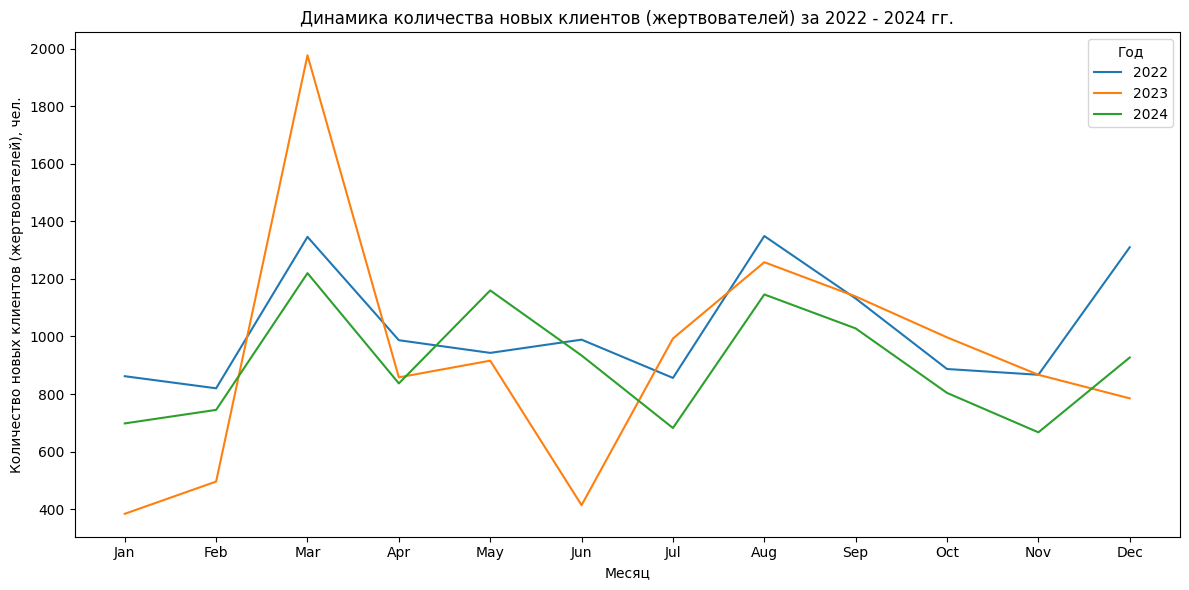

In [103]:
# Записываем в новую переменную информацию о клиентах (жертвователях), оставив первую дату платежа
new_donors_monthly = (
    data_2022_2024_filtered
    .query('received_sum < 200000')
    .sort_values(by=['user_id'])
    .drop_duplicates(subset='user_id', keep='first')
)

# Выводим на экран линейную диаграмму динамики притока новых клиентов (жертвователей)
ax = (
    data_2022_2024_filtered
    .pivot_table(index=data_2022_2024_filtered['payment_date'].dt.month,
                 columns=data_2022_2024_filtered['payment_date'].dt.year,
                 values='user_id',
                 aggfunc='count')
    .plot(figsize=(12, 6), grid=False)
)
plt.xticks(ticks=np.arange(1, 13, step=1), labels=['Jan', 'Feb', 'Mar', 'Apr', 'May', 'Jun', 'Jul', 'Aug', 'Sep', 'Oct', 'Nov', 'Dec'])
plt.title('Динамика количества новых клиентов (жертвователей) за 2022 - 2024 гг.')
plt.ylabel('Количество новых клиентов (жертвователей), чел.')
plt.xlabel('Месяц')
plt.legend(title='Год')
plt.tight_layout()
plt.show();

Представленная линейная диаграмма говорит о том, что рост количества новых клиентов (жертвователей) зафиксирован в:
- в марте, августе и декабре 2022 и 2024 гг.;
- в феврале - апреле и августе 2023 г.;
- в мае 2024 г.

Так как данные в данном случае представлены по месяцам, затруднительно точно определить периоды, в которых был зафиксирован рост количества новых клиентов (жертвователей). Повторно построим линейный график, но уже в разрезе дат, для уточнения указанных периодов.

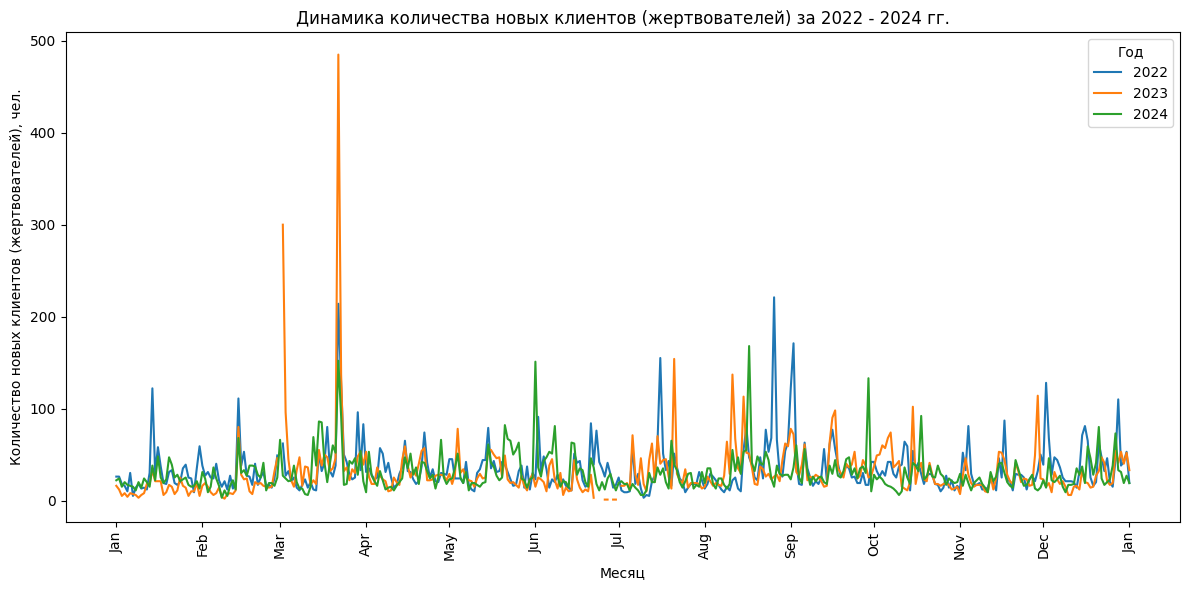

In [104]:
ax = (
    data_2022_2024_filtered
    .query('received_sum < 200000')
    .pivot_table(index=data_2022_2024_filtered['payment_date'].dt.strftime('%m-%d'),
                 columns=data_2022_2024_filtered['payment_date'].dt.year,
                 values='user_id',
                 aggfunc='count')
    .plot(figsize=(12, 6), grid=False)
)
ax.xaxis.set_major_locator(MonthLocator())
ax.xaxis.set_major_formatter(DateFormatter("%b"))
plt.xticks(rotation='vertical')
plt.title('Динамика количества новых клиентов (жертвователей) за 2022 - 2024 гг.')
plt.ylabel('Количество новых клиентов (жертвователей), чел.')
plt.xlabel('Месяц')
plt.legend(title='Год')
plt.tight_layout()
plt.show();

На представленной линейной диаграмме фиксируются всплески притока новых клиентов (жертвователей), аналогичные диаграмме динамики количества платежей за 2022 - 2024 гг. из предыдущего подраздела `4.2.2`, что говорит о том, что **большое количество новых клиентов (жертвователей) приходит в рамках корпоративных и онлайн-акций (`orange2022`, `maple2022`, `orange2023`, `maple2023`, `jam2024`, `school24`), а также спортивных мероприятий и рассылок (`Гошля Анастасия`, `6-y-blagotvoritelnyy-zabeg-dobryy-gryaznyy-treyl`, `EN_210322`, `EN_needs22`, `EN_needs7.23`)**.

Рассчитаем, сколько новых клиентов (жертвователей) приходит с кодом, а сколько без, при помощи методов `isna()`, `notna()` `sum()`.

In [105]:
print('Количество новых клиентов (жертвователей), пришедших без кода:', new_donors_monthly['event_name'].isna().sum(), 'чел.')
print('Количество новых клиентов (жертвователей), пришедших с кодом:', new_donors_monthly['event_name'].notna().sum(), 'чел.')
print('Соотношение количества новых клиентов (жертвователей), пришедших с и без кода:', new_donors_monthly['event_name'].notna().sum() / new_donors_monthly['event_name'].isna().sum())

Количество новых клиентов (жертвователей), пришедших без кода: 2849 чел.
Количество новых клиентов (жертвователей), пришедших с кодом: 9904 чел.
Соотношение количества новых клиентов (жертвователей), пришедших с и без кода: 3.4763074763074764


**Проведенный расчет говорит о том, что на одного нового клиента без кода приходится как минимум 3 человека с кодом.**

#### Социально-демографический и географический портрет клиентов (жертвователей)

Сформируем социально-демографический и географический портрет клиентов (жертвователей) на основании информации, представленной в датасете. Для этого подсчитаем меры центральной тенденции для столбцов, в зависимости от их типа, при помощи метода группировки `groupby()` и агрегирующих функций.

In [106]:
# Создадим новую таблицу с подсчетом мер центральной тенденции для ряда столбцов
central_trend = data_2022_2024_filtered.query('received_sum < 200000').groupby(data_2022_2024_filtered['payment_date'].dt.year).agg({
    'received_sum': ['mean', 'median'],
    'user_gender': pd.Series.mode,
    'country': pd.Series.mode,
    'region': pd.Series.mode,
    'city': pd.Series.mode,
    'transaction_type': pd.Series.mode,
    'event_code': pd.Series.mode,
    'event_name': pd.Series.mode
}).T

# Скорректируем названия столбцов
central_trend.reset_index(level=[0,1], inplace=True)
central_trend.columns = ['Столбец', 'Мера', '2022', '2023', '2024']

# Изменим названия признаков и мер на русскоязычные варианты
central_trend.replace(
    {'mean': 'Среднее',
     'median': 'Медиана',
     'mode': 'Мода'},
    inplace=True
)

# Выведем полученную таблицу на экран
central_trend

,Столбец,Мера,2022,2023,2024
0,received_sum,Среднее,1823.79,1659.08,1768.18
1,received_sum,Медиана,550.00,590.00,500.00
2,user_gender,Мода,Ж,Ж,Ж
3,country,Мода,Россия,Россия,Россия
4,region,Мода,Москва,Москва,Москва
5,city,Мода,Москва,Москва,Москва
6,transaction_type,Мода,Пожертвование разовое,Пожертвование разовое,Пожертвование разовое
7,event_code,Мода,f212,f212,f212
8,event_name,Мода,maple2022,orange2023,jam2024


Согласно данным, представленным в таблице, для основных клиентов (жертвователей) благотворительного фонда характерны следующие черты:
- среднее значение суммы пожертвования составляет:
   - в 2022 г. - 1823,79 руб.;
   - в 2023 г. - 1659,08 руб.;
   - в 2024 г. - 1768,18 руб.
- медианное значение суммы пожертвования составляет:
   - в 2022 г. - 550 руб.;
   - в 2023 г. - 590 руб.;
   - в 2024 г. - 500 руб.
- женского пола;
- из России;
- жители г. Москвы;
- осуществляющие разовые пожертвования (не по подписке);
- пожертвования проходят по коду `f212` - согласно информации, предоставленной заказчиком, он соответствует значению `Частные доноры Регулярные пожертвования`;
- каждый год наименование мероприятия / ссылка на мероприятие, в рамках которого направлено пожертвование, меняется:
    - в 2022 г. - `maple2022`;
    - в 2023 г. - `orange2023`;
    - в 2024 г. - `jam2024`.

Рассмотрим значения в каждом столбце в отдельности. Для удобства анализа требуемой нам информации зададим функцию, создающую таблицу с подсчетом клиентов (жертвователей) по необходимому нам столбцу.

In [107]:
# Задаем функцию для создания новой таблицы и подсчета количества клиентов (жертвователей) по выбранному столбцу
def profile_donor_groupby(data, column, identifier):

    # Создаем новую таблицу и подсчитываем количество клиентов (жертвователей) по выбранному столбцу
    df = (
        data
        .groupby(column)
        .agg({identifier: 'count'})
        .sort_values(by=identifier, ascending=False)
        .rename(columns={identifier: 'количество_клиентов_(жертвователей)'})
    )

    # Создаем столбец с расчетом долей клиентов (жертвователей) по выбранному столбцу
    df['доля_клиентов_(жертвователей)'] = (df['количество_клиентов_(жертвователей)'] / df['количество_клиентов_(жертвователей)'].sum() * 100)

    # Подсчитываем общую сумму по столбцам
    df.loc['Итого'] = df.sum()

    # Создаем столбец с расчетом среднего значения пожертвования по выбранному столбцу
    df['средняя_сумма_пожертвования, руб.'] = data.groupby(column)['received_sum'].mean()
    
    # Возвращаем столбцу количество_клиентов_(жертвователей) целочисленный вид
    df['количество_клиентов_(жертвователей)'] = df['количество_клиентов_(жертвователей)'].astype(int)

    # Выводим полученную таблицу на экран
    display(df)

В первую очередь рассмотрим столбец `user_gender`.

In [108]:
profile_donor_groupby(data_2022_2024_filtered.query('received_sum < 200000'), 'user_gender', 'user_id')

,количество_клиентов_(жертвователей),доля_клиентов_(жертвователей),"средняя_сумма_пожертвования, руб."
user_gender,,,
Ж,8075,68.13,1671.08
М,3777,31.87,2783.45
Итого,11852,100.00,NaN


**По полу - почти 68,1% клиентов (жертвователей) это женщины, при этом в среднем они жертвуют на 66,6% меньше, чем мужчины.**

Далее рассмотрим столбец `country`.

In [109]:
profile_donor_groupby(data_2022_2024_filtered.query('received_sum < 200000'), 'country', 'user_id')

,количество_клиентов_(жертвователей),доля_клиентов_(жертвователей),"средняя_сумма_пожертвования, руб."
country,,,
Россия,20602,99.29,1685.89
ОАЭ,69,0.33,398.55
Турция,45,0.22,300.00
Германия,9,0.04,2567.78
Великобритания,8,0.04,3427.90
Украина,4,0.02,3077.50
США,2,0.01,3375.00
Армения,1,0.00,500.00
Чехия,1,0.00,500.00


**По странам - 99,3% клиентов (жертвователей) находятся в России, которые в среднем жертвуют 1,7 тыс. руб.**

Далее рассмотрим столбец `region`.

In [110]:
profile_donor_groupby(data_2022_2024_filtered.query('received_sum < 200000'), 'region', 'user_id')

,количество_клиентов_(жертвователей),доля_клиентов_(жертвователей),"средняя_сумма_пожертвования, руб."
region,,,
Москва,6411,62.39,2291.86
Московская область,1100,10.71,1506.07
Санкт-Петербург,444,4.32,2146.59
Краснодарский край,145,1.41,869.86
Мурманская область,143,1.39,1146.57
...,...,...,...
Республика Адыгея,1,0.01,5000.00
Республика Ингушетия,1,0.01,498.00
Ямало-Ненецкий автономный округ,1,0.01,5000.00


**По регионам - 62,4% клиентов (жертвователей) живут в Москве, 10,7% в Московской области, а 4,3% в Санкт-Петербурге, которые в среднем жертвуют 2,3, 1,5 и 2,1 тыс. руб. соответственно.**

Далее рассмотрим столбец `city`.

In [111]:
profile_donor_groupby(data_2022_2024_filtered.query('received_sum < 200000'), 'city', 'user_id')

,количество_клиентов_(жертвователей),доля_клиентов_(жертвователей),"средняя_сумма_пожертвования, руб."
city,,,
Москва,14169,59.94,2190.19
Санкт-Петербург,1066,4.51,1788.69
Екатеринбург,498,2.11,1071.40
Краснодар,398,1.68,1147.39
Нижний Новгород,328,1.39,962.65
...,...,...,...
Мончегорск,1,0.00,710.00
Монмут Джанкшен,1,0.00,2000.00
Мозырь,1,0.00,500.00


**По городам - 59,9% клиентов (жертвователей) живут в Москве, 4,5% в Санкт-Петербурге и 2,1% в Екатеринбурге, которые в среднем жертвуют 2,2, 1,8 и 1,1 тыс. руб.**

Далее рассмотрим столбец `transaction_type`.

In [112]:
profile_donor_groupby(data_2022_2024_filtered.query('received_sum < 200000'), 'transaction_type', 'user_id')

,количество_клиентов_(жертвователей),доля_клиентов_(жертвователей),"средняя_сумма_пожертвования, руб."
transaction_type,,,
Пожертвование разовое,17457,50.97,2034.97
Пожертвование рекуррент,12932,37.76,1095.21
Взнос,2674,7.81,1977.87
Продажа,716,2.09,6093.67
Пожертвование рекуррент (первое),468,1.37,1487.68
Корпоративное пожертвование,3,0.01,236.67
Итого,34250,100.00,NaN


**По типам сделки - 51% клиентов (жертвователей) делают только разовые пожертвования, 37,7% вносят пожертвования регулярно (каждый месяц) и 7,8% делают это в рамках взносов на спортивных мероприятиях, при этом средняя сумма пожертвований составляет 2, 1,1 и 2 тыс. руб. соответственно.**

Далее рассмотрим столбец `event_code`.

In [113]:
profile_donor_groupby(data_2022_2024_filtered.query('received_sum < 200000'), 'event_code', 'user_id')

,количество_клиентов_(жертвователей),доля_клиентов_(жертвователей),"средняя_сумма_пожертвования, руб."
event_code,,,
f212,12381,36.27,710.29
f405,3593,10.53,1359.87
f207,3563,10.44,915.10
f214,3453,10.12,981.93
f215,3364,9.85,2103.76
f211,2552,7.48,1026.44
f204,2329,6.82,2027.01
f112,951,2.79,6190.31
f517,716,2.10,6093.67


**По кодам мероприятий - 36,2% клиентов (жертвователей) вносят пожертвования по коду `f212 (Частные доноры Регулярные пожертвования)`, 10,5% вносят пожертвования по коду `f405 (Социальный маркетинг, пожертвования сотрудников (кроме АВБ))`, 10,4% вносят пожертвования по коду `f207 (АВБ)` и 10,1% вносят пожертвования по коду `f214 (Разовые пожертвования картой через сайт, ящики в фонде)`, а средняя сумма пожертвования в данном случае составляет 0,7, 1,4 0,9 и 1 тыс. руб. соответственно.**

Далее рассмотрим столбец `event_name`.

In [114]:
profile_donor_groupby(data_2022_2024_filtered.query('received_sum < 200000'), 'event_name', 'user_id')

,количество_клиентов_(жертвователей),доля_клиентов_(жертвователей),"средняя_сумма_пожертвования, руб."
event_name,,,
th,1121,6.71,2911.35
orange2023,1081,6.47,930.00
maple2022,776,4.65,1296.63
elki2023,689,4.12,1727.23
vesenni-blagotvoritelnyy-zabeg-sport-vo-blago-14-10-2023,618,3.70,2031.44
...,...,...,...
Не упустить главное время!,1,0.01,500.00
MA_PVL*,1,0.01,15000.00
MA_SS,1,0.01,50.00


**По наименованию мероприятия / ссылки на мероприятие, - 6,7% клиентов (жертвователей) внесли пожертвования по ссылке `th`, 6,5% внесли пожертвования регулярно по ссылке `orange2023`, 4,7% внесли пожертвования по ссылке `maple2022` и 4,1% внесли пожертвования по коду `elki2023`, а средняя сумма пожертвования составила 2,9, 0,9, 1,3 и 1,7 тыс. руб. соответственно.**

Таким образом, полученное распределение значений по столбцам соответствует сводной таблица с подсчетами мер центральной тенденции.

### Выводы

Подведем итоги проведенной предобработки данных:
- **в подразделе 4.1** мы провели анализ выбросов и:
    - удалили из датасета строки со значениями меньше и равные 0, а также меньше 5 руб. в столбце `received_sum`;
    - перенесли информацию о пожертвованиях компаний в отдельный датасет `data_2022_2024_companies`;
    - определили, что после предобработки и изменения или удаления аномальных значений в отфильтрованном датасете осталось 58,94% строк исходных данных, что является не очень хорошим, но допустимым результатом при ограниченном наборе данных.
- **в подразделе 4.2** мы:
    - провели анализ динамики средней суммы пожертвования за рассматриваемый период и определили, что:
        - наибольшие суммы пожертвований благотворительный фонд получает в рамках благотворительных концертов и вечеров, предновогодних акций `Новогодний подарок!` (`elki`), а также личных контактов сотрудников фонда с ВИДами (код мероприятия `f114 (ВИД массовые акции)`);
        - большой объем пожертвований был получен в рамках акции `Юбилей Бориса Синегубко` - от 20 до 150 тыс. руб., а также `Устрицы 2023` и `Устрицы 2024` - наибольший платеж в данном случае составил более 100 тыс. руб.;
        - наибольшие суммы пожертвований, имеют коды `f208 (мероприятия ВИД, концерт)`, `f209 (ВИД пожертвования)` и `f215 (Пожертвования через СМС и спец ссылки)`, помимо кода `f114`, который был упомянут выше, что говорит о том, что организация концертов и иных массовых мероприятий позволяет привлечь как минимум крупные разовые пожертвования;
        - большинство крупных пожертвований являются разовыми, при этом их величина может в десятки раз превышать среднее значение - 100 тыс. руб. против 2-5 тыс., в связи с чем представленные диаграммы динамики средней суммы пожертвования имеют большое количество выделяющихся пиков.
    - провели анализ динамики количества пожертвования за рассматриваемый период и определили, что:
        - большинство пожертвований были получены в рамках корпоративных и онлайн-акций (`orange2022`, `maple2022`, `orange2023`, `maple2023`, `jam2024`, `school24`), спортивных мероприятий, в частности благотворительных забегов (`Гошля Анастасия`, `6-y-blagotvoritelnyy-zabeg-dobryy-gryaznyy-treyl`), а также рассылок (`EN_210322`, `EN_needs22`, `EN_needs7.23`), для большинства из которых применяются коды `f405 (Социальный маркетинг, пожертвования сотрудников (кроме АВБ))` и `f215 (Пожертвования через СМС и спец ссылки)`);
        - 20-21 числа каждого месяца происходит рассылка сообщений через сайт в адрес клиентов (жертвователей), в связи с чем число платежей в такие дни возрастает.
    - провели анализ динамики притока новых клиентов (жертвователей) за рассматриваемый период и определили, что:
        - аналогично росту количества платежей, большое количество новых клиентов (жертвователей) приходит в рамках корпоративных и онлайн-акций (`orange2022`, `maple2022`, `orange2023`, `maple2023`, `jam2024`, `school24`), а также спортивных мероприятий и рассылок (`Гошля Анастасия`, `6-y-blagotvoritelnyy-zabeg-dobryy-gryaznyy-treyl`, `EN_210322`, `EN_needs22`, `EN_needs7.23`);
        - на одного нового клиента без кода приходится как минимум 3 человека с кодом.
- **в подразделе 4.3** мы сформировали социально-демографический и географический портрет клиентов (жертвователей) и определили, что для основных клиентов (жертвователей) благотворительного фонда характерны следующие черты:
    - среднее значение суммы пожертвования составляет:
        - в 2022 г. - 1823,79 руб.;
        - в 2023 г. - 1659,08 руб.;
        - в 2024 г. - 1768,18 руб.
    - медианное значение суммы пожертвования составляет:
        - в 2022 г. - 550 руб.;
        - в 2023 г. - 590 руб.;
        - в 2024 г. - 500 руб.
    - женского пола;
    - из России;
    - жители г. Москвы;
    - осуществляющие разовые пожертвования (не по подписке);
    - пожертвования проходит по коду `f212` - согласно информации, предоставленной заказчиком, он соответствует значению "Частные доноры Регулярные пожертвования";
    - каждый год наименование мероприятия / ссылка на мероприятие, в рамках которого направлена значительная часть пожертвований, меняется:
        - в 2022 г. - `maple2022`;
        - в 2023 г. - `orange2023`;
        - в 2024 г. - `jam2024`.

Таким образом мы завершили исследовательский анализ данных.

## RFM-анализ

Проведем RFM-анализ датасета для сегментации клиентов (жертвователей) и определения наиболее перспективных из них, с точки зрения удержания и привлечения, по данным за 2024 г. Выделим по каждому клиенту (жертвователю) следующую информацию для анализа:
- как давно была последняя покупка (`recency`);
- сколько всего было покупок (`frequency`);
- сумма всех покупок (`monetary`).

Для этого зададим функцию `rfm_base` при помощи которой подсчитаем указанные метрики для каждого клиента (жертвователя). При этом, для снижения влияния выбросов на результаты, применим метод межквартильного размаха (`IQR`), где выбросы определяются как значения, находящиеся за пределами `1,5 IQR` от `Q1` и `Q3` и не включаются в расчет метрик.

In [115]:
def rfm_base(data, analyzed_date=None):
    '''
    Подготовка данных для RFM-анализа
    Рассчитываем метрики recency, frequency и monetary,
    сгруппировав данные по столбцу user_id.
    Переименовываем столбцы.
    Обрабатываем выбросы при помощи метода межквартильного размаха (IQR).
    Возвращаем полученный датасет.
    '''
    if analyzed_date is None:
        analyzed_date = data['payment_date'].max()

    # Группировка по клиентам и расчет RFM-метрик
    rfm = data.groupby('user_id').agg({
        'payment_date': lambda x: (analyzed_date - x.max()).days,  # Считаем метрику recency
        'received_sum': ['count', 'sum']  # Считаем метрику frequency и monetary
    }).reset_index()

    # Переименование колонок
    rfm.columns = ['user_id', 'recency', 'frequency', 'monetary']

    # Обработка выбросов при помощи метода межквартильного размаха (IQR)
    for column in ['recency', 'frequency', 'monetary']:
        q1 = rfm[column].quantile(0.25)
        q3 = rfm[column].quantile(0.75)
        iqr = q3 - q1
        upper_bound = q3 + 1.5 * iqr
        rfm[column] = np.where(rfm[column] > upper_bound, upper_bound, rfm[column])

    return rfm

Функция задана. Теперь применим ее и сформируем датасет `rfm_data` с метриками RFM по данным за 2024 г.

In [116]:
# Применяем заданную функцию для формирования датасета с метриками RFM по данным за 2024 г.
rfm_data = rfm_base(data_2022_2024_filtered[data_2022_2024_filtered['payment_date'].between('2024-01-01', '2024-12-31')])

# Выведем на экран полученный датасет
rfm_data

,user_id,recency,frequency,monetary
0,334737,6.00,3.50,4000.00
1,335175,292.00,1.00,1500.00
2,335311,281.00,1.00,300.00
3,335957,8.00,1.00,1350.00
4,339461,207.00,1.00,50.00
...,...,...,...,...
4391,494821,4.00,1.00,7.00
4392,494823,3.00,1.00,10.00
4393,494825,3.00,1.00,10.00
4394,494829,1.00,1.00,500.00


Датасет успешно сформирован, значения метрик получены.

Зададим функцию `rfm_distributions_plot` для анализа распределения метрик и определения количества сегментов.

In [117]:
def rfm_distributions_plot(rfm_data):
    '''
    Создаем визуализации распределения метрик RFM
    при помощи гистограмм
    '''
    fig, axes = plt.subplots(1, 3, figsize=(15, 6))
    fig.suptitle('Распределение RFM-метрик', fontsize=14)

    # Метрика recency
    sns.histplot(data=rfm_data, x='recency', bins=30, ax=axes[0])
    axes[0].set_title('Распределение метрики Recency')
    axes[0].set_xlabel('Дни с последнего пожертвования, дни')
    axes[0].set_ylabel('Количество вхождений, ед.')

    # Метрика frequency
    sns.histplot(data=rfm_data, x='frequency', bins=30, ax=axes[1])
    axes[1].set_title('Распределение метрики Frequency')
    axes[1].set_xlabel('Количество пожертвований, ед.')
    axes[1].set_ylabel('Количество вхождений, ед.')

    # Метрика monetary
    sns.histplot(data=rfm_data, x='monetary', bins=30, ax=axes[2])
    axes[2].set_title('Распределение метрики Monetary')
    axes[2].set_xlabel('Общая сумма пожертвований, руб.')
    axes[2].set_ylabel('Количество вхождений, ед.')

    plt.tight_layout()
    return fig

Функция задана. Применим ее и выведем на экран визуализации распределения метрик RFM.

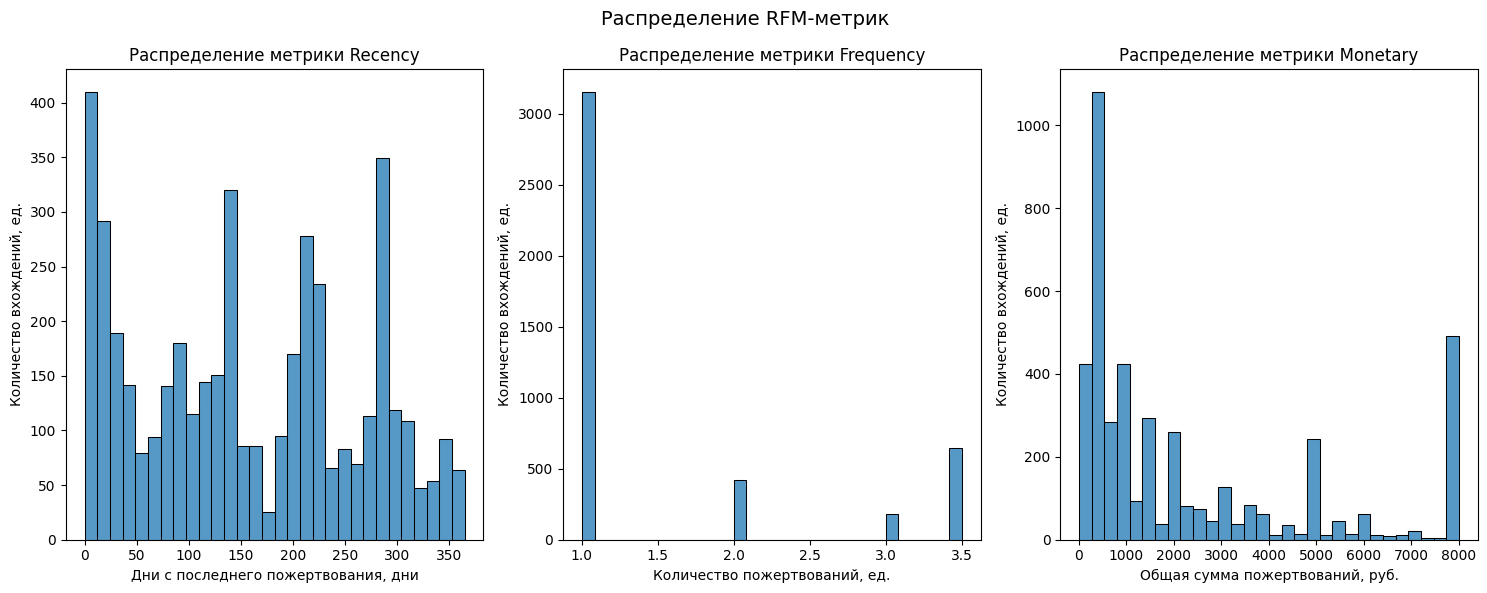

In [118]:
# Записываем в переменную результат работы функции
rfm_dist_plot = rfm_distributions_plot(rfm_data)

# Выводим на экран полученную визуализацию
rfm_dist_plot

Согласно построенным столбчатым диаграммам:
- у метрики `Recency` зафиксировано 4 выделяющихся значения - 0, 140, 220 и 280 дней с последнего пожертвования;
- у метрики `Frequency` зафиксировано только одно выделяющееся значение - одно (разовое) пожертвование, тогда как повторных пожертвований крайне мало;
- у метрики `Monetary` зафиксировано 3 выделяющихся значения - в районе 200-500 руб., 5 тыс. руб. и 8 тыс. руб.

На основании ранее проведенного исследовательского анализа метрик в разделе 4.2 можно сделать вывод о том, что клиентов (жертвователей) можно разделить на 3 группы по каждой из метрик:
- для метрики `Recency` клиенты (жертвователи) могли сделать пожертвование недавно, и очень давно;
- для метрики `Frequency` клиенты (жертвователи) могли сделать разовое пожертвование, два пожертвования или три и более;
- для метрики `Monetary` клиенты (жертвователи) могли сделать небольшое пожертвование, пожертвование среднего размера или крупное пожертвование.

Таким образом, для подсчета баллов `RFM` будем использовать 3 сегмента. Зададим функцию для сегментации данных и подсчета баллов, воспользовавшись методом `cut()`, предназначенным для разделения исходных данных на группы различного размера.

In [119]:
def interval_segmentation(rfm_data, segments=3):
    '''
    Интервальная сегментация клиентов.
    Создаем копию датасета.
    Создаем подписи для сегментов.
    Рассчитываем количество сегментов по каждой метрике (recency, frequency и monetary)
    при помощи метода cut по указанному количеству сегментов.
    Добавляем подписи столбцам R, F, M.
    Подсчитываем общую метрику RFM Score.
    Возвращаем полученный датасет.
    '''
    rfm = rfm_data.copy()

    # Создаем подписи для сегментов
    labels = range(1, segments + 1, 1)

    # Проводим сегментацию при помощи метода cut
    # Для метрики recency наивысший балл будет присвоен для недавноего платежа, в связи с чем необходимо использовать обратный порядок цифр
    r_labels = pd.cut(rfm['recency'], bins=segments, labels=list(reversed(labels)))
    f_labels = pd.cut(rfm['frequency'], bins=segments, labels=labels)
    m_labels = pd.cut(rfm['monetary'], bins=segments, labels=labels)

    # Добавляем сегменты в датасет
    rfm['R'] = r_labels
    rfm['F'] = f_labels
    rfm['M'] = m_labels

    # Создаем общую метрику RFM Score
    rfm['RFM_Score'] = rfm['R'].astype(str) + rfm['F'].astype(str) + rfm['M'].astype(str)

    return rfm

Функция задана. Применим ее для распределения клиентов по сегментам.

In [120]:
# Применяем функцию сегментации
rfm_segments = interval_segmentation(rfm_data)

# Выводим дополненный датасет на экран
rfm_segments

,user_id,recency,frequency,monetary,R,F,M,RFM_Score
0,334737,6.00,3.50,4000.00,3,3,2,332
1,335175,292.00,1.00,1500.00,1,1,1,111
2,335311,281.00,1.00,300.00,1,1,1,111
3,335957,8.00,1.00,1350.00,3,1,1,311
4,339461,207.00,1.00,50.00,2,1,1,211
...,...,...,...,...,...,...,...,...
4391,494821,4.00,1.00,7.00,3,1,1,311
4392,494823,3.00,1.00,10.00,3,1,1,311
4393,494825,3.00,1.00,10.00,3,1,1,311
4394,494829,1.00,1.00,500.00,3,1,1,311


Таким образом мы получили общую метрику `RFM_Score`.

Следует отметить, что порядок чисел в метриках `R`, `F` и `M` имеет следующие значения:
- наибольшее значение метрики `R (recency)`, равное 3, означает недавнюю активность клиентов (жертвователей);
- наибольшее значение метрики `F (frequency)`, равное 3, означает высокую частоту платежей;
- наибольшее значение метрики `M (monetary)`, равное 3, означает большой объем пожертвований.

На основании рассчитанных метрик можно выделить следующие основные сегменты клиентов (жертвователей):
- `333` - ценные клиенты (жертвователи) - клиенты (жертвователи) с недавней активностью, высокой частотой платежей и большими объемами пожертвований, которые требуют повышенного внимания со стороны сотрудников благотворительного фонда в целях дальнейшего получения постоянной поддержки с их стороны;
- `222` - "средние" клиенты (жертвователи) - клиенты (жертвователи) со средней активностью, частотой и размером платежей, которые в целом имеют определенный интерес в деятельности благотворительного фонда;
- `111` - ушедшие клиенты (жертвователи) - клиенты (жертвователи) с давней активностью, низкой частотой платежей и небольшими объемами пожертвований, которых можно попытаться вернуть путем проведения стандартных рассылок или иных маркетинговых кампаний;
- `313` / `3x3` - новые клиенты (жертвователи) с потенциалом - клиенты (жертвователи) с недавней активностью, низкой или различной частотой платежей, но большими объемами пожертвований, которые также требуют внимания в целях сохранения их активности с точки зрения новых пожертвований;
- `x11` - "разовые" небольшие клиенты (жертвователи) - клиенты (жертвователи) с различной активностью, которые сделали небольшое разовое пожертвование и больше не переводили денежных средств благотворительному фонду, которых можно попытаться вернуть путем проведения рассылок с интересными акциями фонда;
- `x13` - "разовые" крупные клиенты (жертвователи) - клиенты (жертвователи) с различной активностью, которые сделали крупное разовое пожертвование и больше не переводили денежных средств благотворительному фонду, которых можно попытаться вернуть путем предложения участия в крупных мероприятиях благотворительного фонда;

- `13x` - вернувшиеся клиенты (жертвователи) - клиенты (жертвователи) с давней активностью, которые недавно вернулись и осуществляют частые платежи или переводят большой объем пожертвований, которым можно присылать предложения по участию в специальных благотворительных акциях;
- `1x3` - "спящие" клиенты (жертвователи) - клиенты (жертвователи) с большими объемами пожертвований и высокой частотой платежей в прошлом, но давней активностью, которым можно направлять рассылки с напоминанием об их предыдущей активности и мероприятиях, в которых они участвовали;
- `x3x` - лояльные клиенты (жертвователи) - клиенты (жертвователи) с высокой частотой платежей, которая не зависит от периодов активности или объема пожертвований, которым можно предложить программы лояльности в виде специальной подписки или других форм регулярного вовлечения;
- `xx3` - крупные пожертвования - клиенты (жертвователи) направляющие большие объемы пожертвований, независимо от периодов активности и частоты платежей, которым можно предложить сделать пожертвования в обмен на дорогостоящие эксклюзивные товары или билеты на мероприятия в рамках благотворительных акций;
- `xx2` - средние пожертвования - клиенты (жертвователи) направляющие средние объемы пожертвований, независимо от периодов активности и частоты платежей, которым можно предложить сделать пожертвования в рамках корпоративных акций компаний или спортивных мероприятий;
- `xx1` - небольшие пожертвования - клиенты (жертвователи) направляющие небольшие объемы пожертвований, независимо от периодов активности и частоты платежей, которым можно предложить сделать пожертвования в рамках рассылок, СМС или сезонных акций.



Для распределения полученных значений показателя `RFM` на вышеописанные сегменты добавим в датасет `rfm_segments` новый столбец `segment` и присвоим каждой строке значение сегмента на основе соответствующих условий, описанных при помощи задаваемой функции `segment_assignment()`.

In [121]:
def assign_segment(row):
    '''
    Присвоение сегмента клиентам (жертвователям)
    в зависимости от значения метрик RFM.
    '''
    rfm = row['RFM_Score']
    if rfm == '333':
        return 'Ценные клиенты (жертвователи)'
    elif rfm == '222':
        return '"Средние" клиенты (жертвователи)'
    elif rfm == '111':
        return 'Ушедшие клиенты (жертвователи)'
    elif rfm[0] == '3' and rfm[2] == '3':
        return 'Новые клиенты (жертвователи) с потенциалом'
    elif rfm[1] == '1' and rfm[2] == '1':
        return '"Разовые" небольшие клиенты (жертвователи)'
    elif rfm[1] == '1' and rfm[2] == '3':
        return '"Разовые" крупные клиенты (жертвователи)'
    elif rfm[0] == '1' and rfm[1] == '3':
        return 'Вернувшиеся клиенты (жертвователи)'
    elif rfm[0] == '1' and rfm[2] == '3':
        return '"Спящие" клиенты (жертвователи)'
    elif rfm[1] == '3':
        return 'Лояльные клиенты (жертвователи)'
    elif rfm[2] == '3':
        return 'Крупные пожертвования'
    elif rfm[2] == '2':
        return 'Средние пожертвования'
    elif rfm[2] == '1':
        return 'Небольшие пожертвования'
    else:
        return 'Другие'

Функция задана. Применим ее на датасете `rfm_segments` для создания нового столбца с описанием сегментов.

In [122]:
# Создаем новый столбец в датасете и применяем в нем функцию для создания описания
rfm_segments['segment'] = rfm_segments.apply(assign_segment, axis=1)

# Выводим обновленный датасет на экран
rfm_segments

,user_id,recency,frequency,monetary,R,F,M,RFM_Score,segment
0,334737,6.00,3.50,4000.00,3,3,2,332,Лояльные клиенты (жертвователи)
1,335175,292.00,1.00,1500.00,1,1,1,111,Ушедшие клиенты (жертвователи)
2,335311,281.00,1.00,300.00,1,1,1,111,Ушедшие клиенты (жертвователи)
3,335957,8.00,1.00,1350.00,3,1,1,311,"""Разовые"" небольшие клиенты (жертвователи)"
4,339461,207.00,1.00,50.00,2,1,1,211,"""Разовые"" небольшие клиенты (жертвователи)"
...,...,...,...,...,...,...,...,...,...
4391,494821,4.00,1.00,7.00,3,1,1,311,"""Разовые"" небольшие клиенты (жертвователи)"
4392,494823,3.00,1.00,10.00,3,1,1,311,"""Разовые"" небольшие клиенты (жертвователи)"
4393,494825,3.00,1.00,10.00,3,1,1,311,"""Разовые"" небольшие клиенты (жертвователи)"
4394,494829,1.00,1.00,500.00,3,1,1,311,"""Разовые"" небольшие клиенты (жертвователи)"


В датасет успешно добавлена информация с описанием сегмента клиента. Подсчитаем, сколько клиентов из каждой группы присутствует в датасете при помощи метода `value_counts()`.

In [123]:
rfm_segments['segment'].value_counts(normalize=True)*100

segment
"Разовые" небольшие клиенты (жертвователи)   39.88
Ушедшие клиенты (жертвователи)               18.36
Средние пожертвования                        10.28
Лояльные клиенты (жертвователи)              10.24
Ценные клиенты (жертвователи)                 8.05
Небольшие пожертвования                       5.76
"Разовые" крупные клиенты (жертвователи)      3.05
Новые клиенты (жертвователи) с потенциалом    2.32
"Средние" клиенты (жертвователи)              0.86
Крупные пожертвования                         0.45
Вернувшиеся клиенты (жертвователи)            0.43
"Спящие" клиенты (жертвователи)               0.32
Name: proportion, dtype: float64

Полученная информация говорит о том, что из 4,4 тыс. уникальных клиентов (жертвователей):
- 39,88% являются "разовыми" небольшими клиентами (жертвователями), которые после перечисления небольшой суммы в адрес благотворительного фонда больше не проявляют активности. В связи с этим, в целях привлечения и хотя бы их кратковременного возвращения, можно проводить повторные рассылки на электронную почту и через СМС, а также рекламу в мессенджерах и на сайтах, на баннерах и стендах на улице, в рамках культурных мероприятий, на телевидении и в других местах ее размещения;
- 18,36% являются ушедшими клиентами (жертвователями), которых затруднительно вернуть вследствие низкого интереса и вовлеченности с их стороны, однако можно попытаться напомнить им о благотворительном фонде также через различные варианты рассылок с акцентом на массовые мероприятия;
- 10,28% являются клиентами (жертвователями) со средними размерами пожертвований, которых можно попытаться привлечь путем проведения корпоративных акций внутри компаний или спортивных мероприятий;
- 10,24% являются лояльными клиентами (жертвователями), которые делают частые пожертвования вне зависимости от даты и размера платежей, что говорит о наличии достаточно большого количества симпатизирующих и помогающих благотворительному фонду людей (около 450 человек);
- 8,05% являются ценными клиентами (жертвователями), которые регулярно вносят большие объемы пожертвований, что может говорить о наличии среди них "покровителей" благотворительного фонда, которым можно предложить поучаствовать в крупных мероприятиях, в том числе путем помощи с их организацией, например приобретение необходимых товаров и услуг и др., а также пригласить на специальные мероприятия, подарить эксклюзивные подарки от фонда и наградить благодарственными грамотами и т.д.;
- 5,76% являются клиентами (жертвователями) с небольшими размерами пожертвований, которых можно попытаться привлечь при помощи отправки рассылок с сообщениями о наличии потребности в достижении целей в рамках определенных акций - сбор детей в школу, продовольственная помощь и т.д.;
- 3,05% являются "разовыми" крупными клиентами (жертвователями), жертвующими большие суммы денежных средств, независимо от периодов активности, которым можно предложить сделать пожертвования в обмен на дорогостоящие эксклюзивные товары или билеты на мероприятия в рамках благотворительных акций;
- 2,32% являются новыми клиентами (жертвователями) с потенциалом, что может говорить о необходимости более активно проводить акции, привлекающие внимание к благотворительному фонду и рассказывать о них;
- 0,86% являются "средними" клиентами (жертвователями), которые сами по себе являются достаточно активными и которым можно присылать рассылку с новостями фонда и текущими акциями;
- 0,45% являются клиентами (жертвователями) с крупными размерами пожертвований, которым можно предложить участие в акциях, которые предполагают необходимость быстрого сбора крупного объема денежных средств на различные нужды, в том числе связанные со здоровьем подопечных фонда;

- 0,43% являются вернувшимися клиентами (жертвователями), которые недавно проявляли активность и которым можно предложить участие в специальных мероприятиях благотворительного фонда через информационные сообщения;
- 0,32% являются "спящими" клиентами (жертвователями), которые направляли крупные пожертвования, но давно проявляли активность, которым можно направлять рассылки с напоминанием об их предыдущей активности и мероприятиях, в которых они участвовали.

Таким образом, **наиболее приоритетными сегментами клиентов (жертвователей), на которые следует обратить внимание в целях их удержания или привлечения людей, являются:**
- "разовые" небольшие клиенты (жертвователи), которых можно попробовать повторно привлечь при помощи повторных рассылок на электронную почту и через СМС, а также рекламу в мессенджерах и на сайтах, на баннерах и стендах на улице, в рамках культурных мероприятий, на телевидении и в других местах ее размещения;
- клиенты (жертвователи) со средними размерами пожертвований, которых можно попытаться привлечь путем проведения корпоративных акций внутри компаний или спортивных мероприятий;
- лояльные клиенты (жертвователи), которым можно предложить программы лояльности в виде специальной подписки или других форм регулярного вовлечения;
- ценные клиенты (жертвователи), которым можно предложить поучаствовать в крупных мероприятиях, в том числе путем помощи с их организацией, например приобретение необходимых товаров и услуг и др., а также пригласить на специальные мероприятия, подарить эксклюзивные подарки от фонда и наградить благодарственными грамотами и т.д.;
- ушедшие клиенты (жертвователи), которых можно попытаться вернуть путем напоминания им о благотворительном фонде также через различные варианты рассылок с акцентом на массовые мероприятия.

Обобщим полученные выводы и сформируем рекомендации по улучшению маркетинговых стратегий благотворительного фонда.

## Выводы и рекомендации

### Выводы по проведенному исследованию

В рамках данного исследования был проведен анализ структуры и активности клиентов (жертвователей) благотворительного фонда, на основании предоставленных выгрузок данных.

**В 1 разделе** мы описали цель, задачи и план проводимого исследования, а также анализируемый набор данных.

**Во 2 разделе** мы осуществили следующий перечень действий:
- **в подразделе 2.1** мы осуществили импорт библиотек и методов и загрузили данные;
- **в подразделе 2.2** мы провели первоначальный анализ датасета на предмет адекватного отображения информации и определили, что:
    - в датасете `data_2022_2024` содержится более чем 58 тыс. записей о клиентах (жертвователях) и их платежах в адрес благотворительного фонда;
    - **в большинстве столбцов присутствуют пропущенные значения** (кроме столбцов `id`, `payment_date` и `received_sum`), что может быть обусловлено тем, что в некоторых случаях клиенты (жертвователи) не указывают какую-либо информацию о себе, а также тем, что при автоматическом внесении информации в базу данных некоторые столбцы не заполняются в случаях, если не было осуществлено какое-либо действие, в связи с чем необходимо провести проверку пропусков;
    - за исключением столбцов `id`, `user_id` и `company_id`, у которых тип данных указан как целочисленный (`int`) и вещественный (`float`) соответственно, **почти у всех столбцов типы данных указаны как строки (`object`), что в ряде случаев является ошибкой** и требует корректировки, так как во многих столбцах есть даты и числа;
    - **в датасете присутствует более 10 тыс. явных (полных) дубликатов строк**, которые необходимо убрать для получения объективной оценки ситуации и формирования адекватных выводов по проводимому исследованию;
    - столбцы `country_`, `region_` и `city_` имеют лишнее нижнее подчеркивание в конце названия, которое следует удалить.

**В 3 разделе** мы провели предобработку данных:
- **в подразделе 3.1** мы переименовали столбцы `country_`, `region_` и `city_`, убрав лишнее нижнее подчеркивание в конце названия;
- **в подразделе 3.2** мы осуществили поиск и проверку явных (полных) и неявных дубликатов:
    - удалили явные (полные) дубликаты строк в датасете;
    - заменили значения `0` на `Нет данных` в столбце `user_gender`;
    - заменили неправильные значения и удалили неявные дубликаты в столбцах `country`, `region` и `city`;
    - удалили строки со значением `1` в столбце `transaction_type`;
    - заменили в столбце `event_code` значения `f405 соцмаркетинг` на код `f405`, а также убрали у кодов `f104`, `f105` и `f101` лишние слова.
- **в подразделе 3.3** мы осуществили проверку пропущенных значений в столбце `user_id` и удалили строки с пропусками при условии, что в столбце `company_id` также находятся пропуски;
- **в подразделе 3.4** мы изменили типы данных в следующих столбцах:
    - `user_id` и `company_id` - со строки (`object`) на целочисленный (`int`);
    - `received_sum` - со строки (`object`) на вещественный (`float`);
    - `payment_date` - со строки (`object`) на дату (`datetime`).

**В 4 разделе** мы провели исследовательский анализ данных:
- **в подразделе 4.1** мы провели анализ выбросов и:
    - удалили из датасета строки со значениями меньше и равные 0, а также меньше 5 руб. в столбце `received_sum`;
    - перенесли информацию о пожертвованиях компаний в отдельный датасет `data_2022_2024_companies`;
    - определили, что после предобработки и изменения или удаления аномальных значений в отфильтрованном датасете осталось 58,94% строк исходных данных, что является не очень хорошим, но допустимым результатом при ограниченном наборе данных.
- **в подразделе 4.2** мы:
    - провели анализ динамики средней суммы пожертвования за рассматриваемый период и определили, что:
        - наибольшие суммы пожертвований благотворительный фонд получает в рамках благотворительных концертов и вечеров, предновогодних акций `Новогодний подарок!` (`elki`), а также личных контактов сотрудников фонда с ВИДами (код мероприятия `f114 (ВИД массовые акции)`);
        - большой объем пожертвований был получен в рамках акции `Юбилей Бориса Синегубко` - от 20 до 150 тыс. руб., а также `Устрицы 2023` и `Устрицы 2024` - наибольший платеж в данном случае составил более 100 тыс. руб.;
        - наибольшие суммы пожертвований, имеют коды `f208 (мероприятия ВИД, концерт)`, `f209 (ВИД пожертвования)` и `f215 (Пожертвования через СМС и спец ссылки)`, помимо кода `f114`, который был упомянут выше, что говорит о том, что организация концертов и иных массовых мероприятий позволяет привлечь как минимум крупные разовые пожертвования;
        - большинство крупных пожертвований являются разовыми, при этом их величина может в десятки раз превышать среднее значение - 100 тыс. руб. против 2-5 тыс., в связи с чем представленные диаграммы динамики средней суммы пожертвования имеют большое количество выделяющихся пиков.
    - провели анализ динамики количества пожертвования за рассматриваемый период и определили, что:
        - большинство пожертвований были получены в рамках корпоративных и онлайн-акций (`orange2022`, `maple2022`, `orange2023`, `maple2023`, `jam2024`, `school24`), спортивных мероприятий, в частности благотворительных забегов (`Гошля Анастасия`, `6-y-blagotvoritelnyy-zabeg-dobryy-gryaznyy-treyl`), а также рассылок (`EN_210322`, `EN_needs22`, `EN_needs7.23`), для большинства из которых применяются коды `f405 (Социальный маркетинг, пожертвования сотрудников (кроме АВБ))` и `f215 (Пожертвования через СМС и спец ссылки)`);
        - 20-21 числа каждого месяца происходит рассылка сообщений через сайт в адрес клиентов (жертвователей), в связи с чем число платежей в такие дни возрастает.
    - провели анализ динамики притока новых клиентов (жертвователей) за рассматриваемый период и определили, что:
        - аналогично росту количества платежей, большое количество новых клиентов (жертвователей) приходит в рамках корпоративных и онлайн-акций (`orange2022`, `maple2022`, `orange2023`, `maple2023`, `jam2024`, `school24`), а также спортивных мероприятий и рассылок (`Гошля Анастасия`, `6-y-blagotvoritelnyy-zabeg-dobryy-gryaznyy-treyl`, `EN_210322`, `EN_needs22`, `EN_needs7.23`);
        - на одного нового клиента без кода приходится как минимум 3 человека с кодом.
- **в подразделе 4.3** мы сформировали социально-демографический и географический портрет клиентов (жертвователей) и определили, что для основных клиентов (жертвователей) благотворительного фонда характерны следующие черты:
    - среднее значение суммы пожертвования составляет:
        - в 2022 г. - 1823,79 руб.;
        - в 2023 г. - 1659,08 руб.;
        - в 2024 г. - 1768,18 руб.
    - медианное значение суммы пожертвования составляет:
        - в 2022 г. - 550 руб.;
        - в 2023 г. - 590 руб.;
        - в 2024 г. - 500 руб.
    - женского пола;
    - из России;
    - жители г. Москвы;
    - осуществляющие разовые пожертвования (не по подписке);
    - пожертвования проходит по коду `f212` - согласно информации, предоставленной заказчиком, он соответствует значению "Частные доноры Регулярные пожертвования";
    - каждый год наименование мероприятия / ссылка на мероприятие, в рамках которого направлена значительная часть пожертвований, меняется:
        - в 2022 г. - `maple2022`;
        - в 2023 г. - `orange2023`;
        - в 2024 г. - `jam2024`.

**В 5 разделе** мы провели RFM-анализ и определили, что наиболее приоритетными сегментами клиентов (жертвователей), на которые следует обратить внимание в целях их удержания или привлечения людей, являются:
- "разовые" небольшие клиенты (жертвователи), которых можно попробовать повторно привлечь при помощи повторных рассылок на электронную почту и через СМС, а также рекламу в мессенджерах и на сайтах, на баннерах и стендах на улице, в рамках культурных мероприятий, на телевидении и в других местах ее размещения;
- клиенты (жертвователи) со средними размерами пожертвований, которых можно попытаться привлечь путем проведения корпоративных акций внутри компаний или спортивных мероприятий;
- лояльные клиенты (жертвователи), которым можно предложить программы лояльности в виде специальной подписки или других форм регулярного вовлечения;
- ценные клиенты (жертвователи), которым можно предложить поучаствовать в крупных мероприятиях, в том числе путем помощи с их организацией, например приобретение необходимых товаров и услуг и др., а также пригласить на специальные мероприятия, подарить эксклюзивные подарки от фонда и наградить благодарственными грамотами и т.д.;
- ушедшие клиенты (жертвователи), которых можно попытаться вернуть путем напоминания им о благотворительном фонде также через различные варианты рассылок с акцентом на массовые мероприятия.

### Рекомендации по улучшению маркетинговых стратегий фонда

Сформируем рекомендации по улучшению маркетинговых стратегий благотворительного фонда на основании результатов исследования.

В первую очередь следует указать на то, что большинство клиентов (жертвователей) женского пола, живут в России в городе Москва, в связи с чем основной упор в части маркетинговых кампаний должен быть ориентирован на них, так как люди из указанного региона в большинстве своем имеют достаточный уровень денежных средств, которые позволяют им делать разовые и регулярные пожертвования различного объема.

Для повышения активности и привлечения новых клиентов (жертвователей) можно попробовать увеличить количество мероприятий, проводимых с приглашением известных людей, например благотворительных концертов, театральных постановок и реприз, мастер-классов и других событий в сфере культуры, так как они позволяют привлечь большой объем пожертвований, в том числе за счет продажи лотов с эксклюзивными вещами от знаменитостей, которые интересны клиентам (жертвователям) с соответствующим уровнем дохода, а также за счет большого количества небольших пожертвований (от 100 руб. до 10 тыс. руб.).

Также большим успехом пользуются корпоративные и онлайн-акции (`orange2022`, `maple2022`, `orange2023`, `maple2023`, `jam2024`, `school24`), а также спортивные мероприятия (`Гошля Анастасия`, `6-y-blagotvoritelnyy-zabeg-dobryy-gryaznyy-treyl`), так как в ряде случаев они освещаются СМИ, а также привлекают спонсоров в виде крупных и "средних" жертвователей среди обычных людей и крупных компаний. Рассылки (`EN_210322`, `EN_needs22`, `EN_needs7.23`) тоже привлекают внимание потенциальных клиентов (жертвователей), особенно если в них содержится информация о конкретных целях проводимых благотворительных акций и если они идут на срочные нужды фонда и его подопечных. В связи с этим предлагается расширить количество каналов информирования, чтобы о подобных мероприятиях узнавало больше людей, например при помощи рекламы в `Telegram` (как в виде обычной рекламы между постами, так и посредством рекламы в крупных каналах) или выдачи в поисковых системах (`Яндекс` и др.), а также на сайтах, помогающих с организацией подобных мероприятий, телевидении, баннерах и стендах на улице.

В свою очередь для удержания лояльных клиентов (жертвователей) и конвертации новых людей в лояльную аудиторию, которая часто вносит пожертвования разной суммы вне зависимости от периода активности, предлагается создать программу лояльности, которая могла бы предоставить клиентам (жертвователям) доступ к небольшим эксклюзивным подаркам / сувенирам или же специальным мероприятиям, которые могут проводиться в будущем. Также можно внедрить специальную подписку, которая могла бы содержать какую-либо эксклюзивную (более подробную, чем в обычных информационных статьях) информацию о работе фонда и проводимых им мероприятий, как это реализовано в таких сервисах как `Boosty` или `Patreon`.

Важны и личные контакты сотрудников благотворительного фонда с ВИДами, так как личное взаимодействие позволяет с более высокой вероятностью привлечь клиентов (жертвователей) и сделать их лояльными к благотворительному фонду путем периодических звонков, сообщений в мессенджерах и встреч.

## Презентация

[Презентация](https://drive.google.com/file/d/1HEd-JknklzN7loJInHwF6lvJRBAcnkOd/view?usp=drive_link)